# Full Workup

This notebook will explore the essential pieces for the paper we are interested in publishing. The main focus in this notebook will be a proper application of the $\Delta N$ parameter and setting $\delta N_{piv}$ to be used in the generation of a liklihood for surving models. 

Before we continue with that, I will import necessary packages here and load up the transfer function to be used later in the notebook.



In [1]:

import sys
import os
import glob
import re
import random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numdifftools as nd
import pygsl.rng
from matplotlib import cm
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib import colors as mcolors
from matplotlib.ticker import ScalarFormatter
from scipy.integrate import (
    solve_ivp,
    odeint,
    cumulative_trapezoid,
)
from scipy.interpolate import (
    UnivariateSpline,
    splrep,
    splev,
    CubicSpline,
    interp1d,
    PchipInterpolator,
    InterpolatedUnivariateSpline,
)
from matplotlib.lines import Line2D
import corner
from matplotlib.ticker import ScalarFormatter



# --- Paths -----------------------------------------------------
# Where the InflationModels package lives, so we can import from it
INFLATION_MODELS_PATH = Path(
    "/Users/epmeador/Desktop/research/rwarthur/"
    "inflation_gravitywaves/inflation_code/InflationModels"
)
if str(INFLATION_MODELS_PATH) not in sys.path:
    sys.path.append(str(INFLATION_MODELS_PATH))

# Where the actual batch/model output directories live
BASE_PATH_ROOT = Path(
    "/Users/epmeador/Desktop/research/rwarthur/"
    "inflation_gravitywaves/inflation_code/"
    "Slow-Roll Parameters Tests/higgs_potential_tests"
)
base_path_root = BASE_PATH_ROOT


## The Chosen Transfer Function:

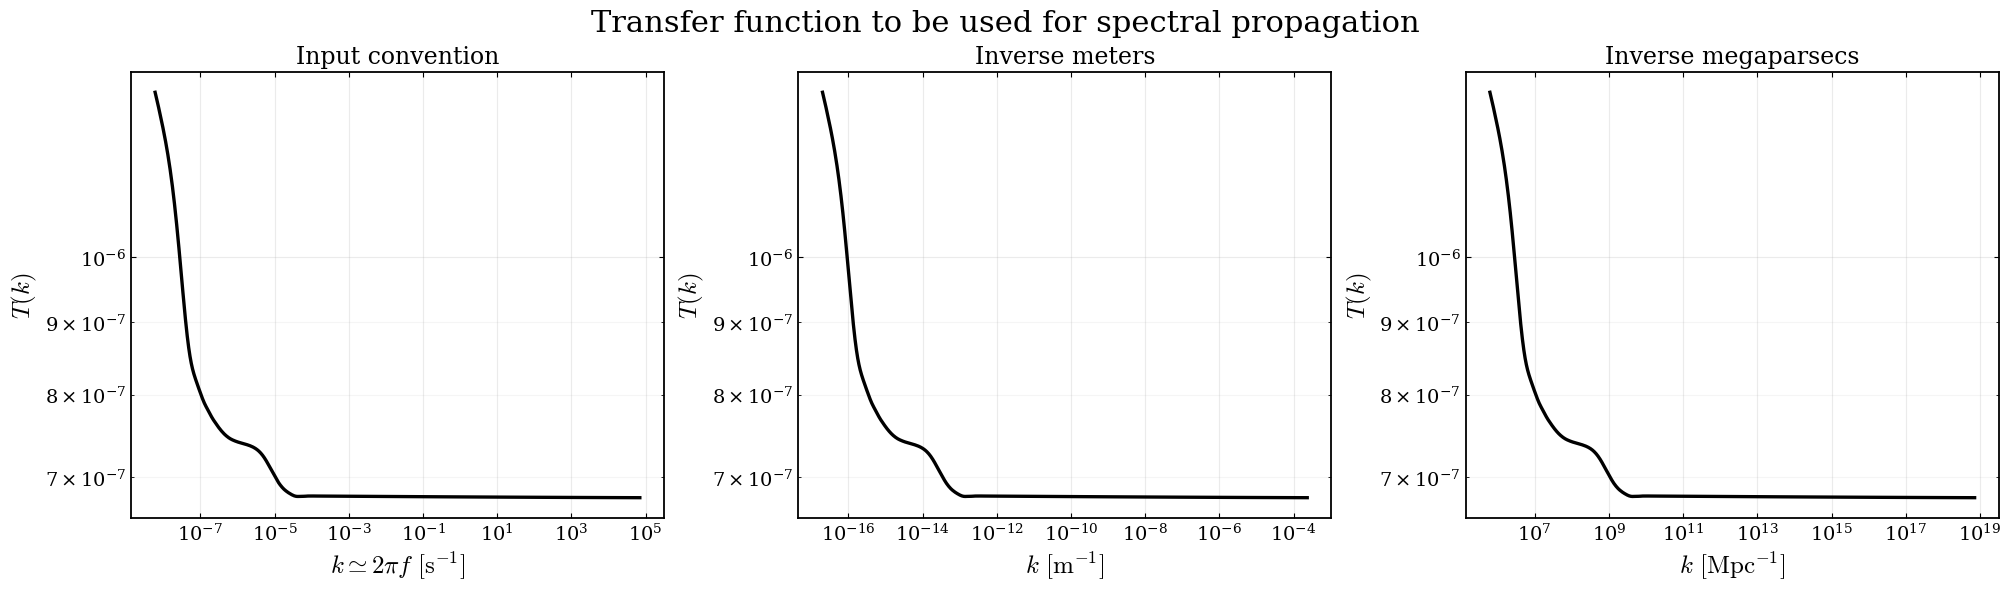

k from data for tf:
6e-09 69740.4

f from data for tf:
9.5493e-10 11099.5

TF median from data:
6.77425e-07 1.3063e-06

k after converting to inverse Mpc:
617562.9710460028 7.178159862110426e+18

ratio of k/(2*pi*f):
0.9999927220232102 1.0000068685629133


In [2]:
plt.rcParams.update({
    "text.usetex": False,
    "mathtext.fontset": "cm",
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "DejaVu Serif"],
    "axes.labelsize": 18,
    "axes.titlesize": 17,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "figure.titlesize": 22,
    "axes.linewidth": 1.3,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
})

base_path_tf = Path(
    "/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/"
    "inflation_code/Slow-Roll Parameters Tests"
)

tf_k = np.loadtxt(base_path_tf / "k_file_tf.dat")
tf_f = np.loadtxt(base_path_tf / "f_file_tf.dat")
tf_median = np.loadtxt(base_path_tf / "Tf_median.dat")

tf_k_invm = tf_f * 2.0 * np.pi / 299792458.0
tf_k_invMpc = tf_k_invm * 3.085677581e22

fig, axes = plt.subplots(
    1,
    3,
    figsize=(20, 5.8),
    constrained_layout=True,
)

plot_data = [
    (
        tf_k,
        tf_median,
        r"$k \simeq 2\pi f\ [{\rm s}^{-1}]$",
        r"$T(k)$",
        r"Input convention",
    ),
    (
        tf_k_invm,
        tf_median,
        r"$k\ [{\rm m}^{-1}]$",
        r"$T(k)$",
        r"Inverse meters",
    ),
    (
        tf_k_invMpc,
        tf_median,
        r"$k\ [{\rm Mpc}^{-1}]$",
        r"$T(k)$",
        r"Inverse megaparsecs",
    ),
]

for ax, (x, y, xlabel, ylabel, title) in zip(axes, plot_data):
    ax.loglog(
        x,
        y,
        color="black",
        lw=2.4,
    )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    ax.grid(True, which="major", alpha=0.25)
    ax.grid(True, which="minor", alpha=0.12)
    ax.minorticks_on()

fig.suptitle(r"Transfer function to be used for spectral propagation", fontsize=22)

plt.savefig(
    "transfer_function_conventions.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("k from data for tf:")
print(tf_k.min(), tf_k.max())

print("\nf from data for tf:")
print(tf_f.min(), tf_f.max())

print("\nTF median from data:")
print(tf_median.min(), tf_median.max())

print("\nk after converting to inverse Mpc:")
print(tf_k_invMpc.min(), tf_k_invMpc.max())

ratio = tf_k / (2.0 * np.pi * tf_f)

print("\nratio of k/(2*pi*f):")
print(np.nanmin(ratio), np.nanmax(ratio))




# Loading Generated Models

In [3]:
# ============================================================
# CELL 1: Load all helper functions that validate model by tag and batch directory
#
# This cell loads the helper functions:
#   validate_model_tag, batch_dirs_for, folder_for,
#   get_base_dir, get_param_values_from_dirs

# validate_model_tag — guards against typos in model_tag
# batch_dirs_for — finds all neqs{N}_{tag}_batch* folders
# folder_for — finds the specific model folder matching a (param_name, value) pair
# get_base_dir — thin wrapper around folder_for for your fiducial/base model
# get_param_values_from_dirs — scans folder names, parses out unique parameter values, returns them sorted with plot labels

# ============================================================



#Model membership test: If not there will raise value error
def validate_model_tag(model_tag):
    """Checks that the requested model tag is supported. This lives inside model tag dict"""
    if model_tag not in MODEL_TAGS:
        raise ValueError(
            f"Unknown model_tag={model_tag!r}. "
            f"Choose from {list(MODEL_TAGS)}."
        )

#Finds all batch directories given a NEQs, model_tag, and base_path_root
#Searches according to search pattern = base_path_root / f"neqs{NEQS}_{model_tag}_batch*"
def batch_dirs_for(
    NEQS,
    base_path_root=BASE_PATH_ROOT,
    model_tag="higgs",
):
    """Return all batch directories for a given model and NEQS"""
    validate_model_tag(model_tag)

    base_path_root = Path(base_path_root)

    pattern = (
        base_path_root
        / f"neqs{NEQS}_{model_tag}_batch*"
    )

    return sorted(Path(p) for p in glob.glob(str(pattern)))


def folder_for(
    NEQS,
    param_name,
    value,
    base_path_root=BASE_PATH_ROOT,
    model_tag="higgs",
):
    """
    Locate the saved model directory corresponding to a parameter value.
    """
    val_str = f"{value:.10e}"

    for batch_dir in batch_dirs_for(
        NEQS,
        base_path_root=base_path_root,
        model_tag=model_tag,
    ):
        pattern = batch_dir / (f"lam2_*_lam3_*_lam4_*_lam5_*")

        for folder in glob.glob(str(pattern)):
            folder = Path(folder)

            if not folder.is_dir():
                continue

            if f"{param_name}_{val_str}" in folder.name:
                return folder

        if folder.exists(): #technicall true for both files and directories
            return folder
        
#         if folder.is_dir(): #could be more specific here
#             return folder

    raise FileNotFoundError(
        f"Missing folder for {param_name}_{val_str} in "
        f"neqs{NEQS}_{model_tag}_batch*" #* means match any sequence of characters
    )

    

#Conveinence wrapper to use with folder_for 
def get_base_dir(
    NEQS,
    param_name,
    base_value,
    base_path_root=BASE_PATH_ROOT,
    model_tag="higgs",
):
    """Locate the directory containing a chosen base model."""
    return folder_for(
        NEQS,
        param_name,
        base_value,
        base_path_root=base_path_root,
        model_tag=model_tag,
    )

def get_param_values_from_dirs(
    NEQS,
    param_name,
    base_path_root=BASE_PATH_ROOT,
    model_tag="higgs",
    show_summary=True,
):
    """
    Extract parameter values from all saved model-directory names.

    Returns:
    list of tuple
        Each tuple contains (value, label).
    """
    values = [] #initialize first, to collect parsed (value, label) pairs

    #loop over batches. if no batches will not run and will return empty list
    for batch_dir in batch_dirs_for(
        NEQS,
        base_path_root=base_path_root,
        model_tag=model_tag,
    ):
        #constructs parameter folder pattern
#         pattern = batch_dir / f"{param_name}_*"
        pattern = batch_dir / "lam2_*_lam3_*_lam4_*_lam5_*"

        for folder in glob.glob(str(pattern)): #glob.glob will return a string and gets converted to a Path object
            folder = Path(folder)

            #rejects nondirectories, they have to be
            if not folder.is_dir():
                continue

            try:
                
                folder_name = folder.name

                parameter_order = ["lam2", "lam3", "lam4", "lam5"]
                parts = folder_name.split("_")

                param_index = parameter_order.index(param_name)
                value_index = 2 * param_index + 1

                value_string = parts[value_index]
                value = float(value_string)


                label = rf"${param_name} = {value:.1e}$" #constructs a plotting label 

                values.append((value, label)) #and it stories the result

            except ValueError as exc:
                print(f"Skipping {folder}: {exc}")

    # Remove duplicate parameter values
    unique_values = {}

    for value, label in values:
        unique_values[value] = label

    #sort output according to ascending numerical order
    values = sorted(
        unique_values.items(),
        key=lambda item: item[0],
    )

    if show_summary:
        print("\n" + "=" * 60)
        print(
            f"Summary for model={model_tag}, "
            f"NEQS={NEQS}, parameter={param_name}"
        )
        print("=" * 60)
        print(f"Unique parameter values (or number of viable models) found: {len(values)}") #print total number of models found

        if values:
            print(
                "Parameter range: "
                f"{values[0][0]:.3e} to {values[-1][0]:.3e}"
            )
        else:
            print("Parameter range: none found")

        print("=" * 60 + "\n")

    return values




Currently, I have run models assuming NEQs=6. This implies that $^3\lambda_H$ is the variable changing between models.

In [4]:
# ============================================================
# CELL 2: Load all generated models
#
# This cell assumes the helper functions below are ALREADY
# defined in an earlier cell (or imported from a module):
#   validate_model_tag, batch_dirs_for, folder_for,
#   get_base_dir, get_param_values_from_dirs
# ============================================================


# --- Model / scan configuration ---------------------------------
MODEL_TAGS = {
    "higgs": "higgs",
    "nonhiggs": "nonhiggs",
}

# Currently only scanning lam5 (NEQS=8)
SCAN_INFO = {
    6: ("lam3", r"\lambda_3"),
}

colors = {
    5: "pink",
    6: "turquoise",
    7: "plum",
    8: "mediumslateblue",
    9: "blue",
}

# The fiducial ("base") value for each model type, at each NEQS.
# folder_for() / get_base_dir() use this to find the base model's folder.
MODEL_CONFIG = {
    "higgs": {
        "label": "Higgs",
        "lam_base": {
            6: ("lam3", -4.60971e-6),
        },
    },
}

# --- Containers to be filled in the loop below -------------------
base_dirs_by_model = {}      # base/fiducial model folder, per model_tag & NEQS
param_values_by_model = {}   # every scanned lam5 value found, per model_tag & NEQS
batch_dirs_by_model = {}     # list of batch directories, per model_tag & NEQS
batch_counts_by_model = {}   # how many model folders live in each batch

# --- Main loading loop --------------------------------------------
for model_tag, config in MODEL_CONFIG.items():
    print("\n" + "=" * 70)
    print(f"Loading {config['label']} models")
    print("=" * 70)

    # 1) Find the fiducial/base-model directory for each NEQS
    base_dirs_by_model[model_tag] = {}
    for NEQS, (param_name, base_val) in config["lam_base"].items():
        folder = get_base_dir(
            NEQS=NEQS,
            param_name=param_name,
            base_value=base_val,
            base_path_root=base_path_root,
            model_tag=model_tag,
        )
        base_dirs_by_model[model_tag][NEQS] = {
            "param_name": param_name,
            "value": base_val,
            "folder": folder,
        }
        print(
            f"{config['label']} base model: "
            f"NEQS={NEQS}, {param_name}={base_val:.10e}"
        )
        print(f"  {folder}")

    # 2) Find every scanned parameter value across all batches
    param_values_by_model[model_tag] = {}
    for NEQS, (param_name, _) in config["lam_base"].items():
        values = get_param_values_from_dirs(
            NEQS=NEQS,
            param_name=param_name,
            base_path_root=base_path_root,
            model_tag=model_tag,
        )
        param_values_by_model[model_tag][NEQS] = values

    # 3) Find batch directories and count models per batch
    batch_dirs_by_model[model_tag] = {}
    batch_counts_by_model[model_tag] = {}
    for NEQS, (param_name, _) in config["lam_base"].items():
        batch_dirs = batch_dirs_for(
            NEQS=NEQS,
            base_path_root=base_path_root,
            model_tag=model_tag,
        )
        batch_dirs_by_model[model_tag][NEQS] = batch_dirs
        batch_counts_by_model[model_tag][NEQS] = {}

        print(f"\nBatch directories for {config['label']}, NEQS={NEQS}:")
        for batch_dir in batch_dirs:
            print(f"  {batch_dir}")

        print(f"\nModels per batch for {config['label']}, NEQS={NEQS}:")
        for batch_dir in batch_dirs:
            pattern = os.path.join(
                str(batch_dir),
                "lam2_*_lam3_*_lam4_*_lam5_*",
            )
            model_dirs = [
                folder
                for folder in glob.glob(pattern)
                if os.path.isdir(folder)
            ]
            count = len(model_dirs)
            batch_name = os.path.basename(str(batch_dir))
            batch_counts_by_model[model_tag][NEQS][batch_name] = count
            print(f"  {batch_name}: {count}")


Loading Higgs models
Higgs base model: NEQS=6, lam3=-4.6097100000e-06
  /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs6_higgs_batch001/lam2_2.7897200000e-04_lam3_-4.6097100000e-06_lam4_0.0000000000e+00_lam5_0.0000000000e+00

Summary for model=higgs, NEQS=6, parameter=lam3
Unique parameter values (or number of viable models) found: 560
Parameter range: -4.985e-03 to 1.685e-06


Batch directories for Higgs, NEQS=6:
  /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs6_higgs_batch001
  /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs6_higgs_batch002
  /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs6_higgs_batch003
  /Users/epmeador/Desktop/research/rwar

In [5]:
# ============================================================
# CELL 3: Reused loading / normalization / comparison helpers
#
# These build on the Cell 2 functions (folder_for, batch_dirs_for,
# etc.) and are used throughout the rest of the notebook:
# plotting raw spectra, normalizing at k_ref, comparing models
# to the base model, and pulling summary-table observables.

# load_specs — reads scalar/tensor power spectrum .dat files
# load_batch_summaries — concatenates all summary.csv files into one DataFrame
# prepare_increasing — sorts/validates monotonicity of a trajectory
# normalize_curve_at_Nref / normalize_at_ref / normalize_at_ref_local — normalize a curve to its value at a reference point (e.g. kref)
# fractional_difference_on_overlap / ..._on_reference_grid — compute y-yref/yref over the shared domain
# get_summary_row / load_observables / load_path — pull r, ns, alphas from the summary table and load raw trajectory paths (these depend on notebook globals like summary_all, scan_name — worth remembering when you reuse them elsewhere)

# ============================================================


# --- Raw spectra loader -----------------------------------------
def load_specs(
    NEQS,
    param_name,
    value,
    base_path_root=BASE_PATH_ROOT,
    model_tag="higgs",
):
    """Load scalar and tensor spectra for one saved model."""
    folder = folder_for(
        NEQS,
        param_name,
        value,
        base_path_root=base_path_root,
        model_tag=model_tag,
    )

    scalar_file = folder / f"spec_s_neqs{NEQS}.dat"
    tensor_file = folder / f"spec_t_neqs{NEQS}.dat"

    if not scalar_file.exists():
        raise FileNotFoundError(
            f"Scalar spectrum file does not exist: {scalar_file}"
        )

    if not tensor_file.exists():
        raise FileNotFoundError(
            f"Tensor spectrum file does not exist: {tensor_file}"
        )

    scalar_data = np.loadtxt(scalar_file)
    tensor_data = np.loadtxt(tensor_file)

    k_s = scalar_data[:, 0]
    Ps = scalar_data[:, 1]

    k_t = tensor_data[:, 0]
    Pt = tensor_data[:, 1]

    return k_s, Ps, k_t, Pt


# --- Summary CSV loader -------------------------------------------
def load_batch_summaries(
    NEQS,
    base_path_root,
    model_tag="higgs",
):
    """
    Load and combine all summary CSV files for one model family.
    """
    summary_files = []
    for batch_dir in batch_dirs_for(
        NEQS=NEQS,
        base_path_root=base_path_root,
        model_tag=model_tag,
    ):
        summary_file = os.path.join(
            str(batch_dir),
            f"neqs{NEQS}_summary.csv",
        )
        if os.path.exists(summary_file):
            summary_files.append(summary_file)

    if len(summary_files) == 0:
        raise FileNotFoundError(
            f"No summary files found for "
            f"NEQS={NEQS}, model_tag={model_tag}"
        )

    dfs = []
    for summary_file in summary_files:
        df = pd.read_csv(summary_file)
        df["summary_file"] = summary_file
        df["batch_dir"] = os.path.basename(
            os.path.dirname(summary_file)
        )
        dfs.append(df)

    return pd.concat(dfs, ignore_index=True)


# --- Array sorting / cleaning --------------------------------------
def prepare_increasing(x, y):
    """
    Return paired arrays with x increasing.

    The input must already be monotonic:
    increasing data are kept, decreasing data are reversed,
    and non-monotonic data raise an error.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if x.shape != y.shape:
        raise ValueError(
            f"x and y must have the same shape; "
            f"got {x.shape} and {y.shape}"
        )

    finite = np.isfinite(x) & np.isfinite(y)
    x = x[finite]
    y = y[finite]

    if len(x) == 0:
        raise ValueError("No finite data points remain.")

    if len(x) == 1:
        return x, y

    dx = np.diff(x)

    if np.all(dx >= 0):
        return x, y

    if np.all(dx <= 0):
        return x[::-1], y[::-1]

    raise ValueError(
        "x is non-monotonic; refusing to sort and reorder the trajectory."
    )


# --- Normalization at a reference point -----------------------------
def normalize_curve_at_Nref(
    N,
    Y,
    N_ref=60.0,
    ref_floor=1e-20,
):
    """Normalize a curve Y(N) by its value at N_ref."""
    N_use, Y_use = prepare_increasing(N, Y)

    if not (N_use.min() <= N_ref <= N_use.max()):
        raise ValueError(
            f"N_ref={N_ref} outside range "
            f"[{N_use.min():.6g}, {N_use.max():.6g}]"
        )

    Y_ref = np.interp(N_ref, N_use, Y_use)

    if not np.isfinite(Y_ref):
        raise ValueError(f"Non-finite reference value at N_ref={N_ref}")

    if np.abs(Y_ref) < ref_floor:
        raise ValueError(
            f"Reference value is too small at N_ref={N_ref}: {Y_ref:.3e}"
        )

    return N_use, Y_use / Y_ref, Y_ref


def normalize_at_ref(
    k,
    P,
    k_ref=0.05,
    ref_floor=1e-30,
):
    """Normalize a spectrum P(k) by its value at k_ref."""
    k_use, P_use = prepare_increasing(k, P)

    if not (k_use.min() <= k_ref <= k_use.max()):
        raise ValueError(
            f"k_ref={k_ref} outside range "
            f"[{k_use.min():.3e}, {k_use.max():.3e}]"
        )

    P_ref = np.interp(k_ref, k_use, P_use)

    if not np.isfinite(P_ref):
        raise ValueError(f"Non-finite spectrum value at k_ref={k_ref}")

    if np.abs(P_ref) < ref_floor:
        raise ValueError(
            f"Spectrum reference is too small at k_ref={k_ref}: {P_ref:.3e}"
        )

    if np.any(P_use < 0):
        raise ValueError("Spectrum contains negative values.")

    return k_use, P_use / P_ref, P_ref


def normalize_at_ref_local(x, y, x_ref):
    """
    Sort by increasing x, then divide y by its interpolated value at x_ref.
    Returns (x, y / y(x_ref)) — no ref_floor / negativity checks.
    """
    x, y = prepare_increasing(x, y)

    if not (np.min(x) <= x_ref <= np.max(x)):
        raise ValueError(
            f"k_ref={x_ref} outside range [{np.min(x):.4e}, {np.max(x):.4e}]"
        )

    y_ref = np.interp(x_ref, x, y)

    if np.abs(y_ref) < 1e-30:
        raise ValueError(f"Reference value too small at k_ref={x_ref}")

    return x, y / y_ref


# --- Comparing a model curve to a reference curve --------------------
def fractional_difference_on_overlap(
    x,
    y,
    x_ref,
    y_ref,
    frac_floor=1e-30,
):
    """
    Compute (y - y_ref) / y_ref over the shared x-domain.
    The reference curve is interpolated onto the model's x-grid.
    """
    x_use_all, y_use_all = prepare_increasing(x, y)
    x_ref_use, y_ref_use = prepare_increasing(x_ref, y_ref)

    xmin = max(x_use_all.min(), x_ref_use.min())
    xmax = min(x_use_all.max(), x_ref_use.max())

    if xmin >= xmax:
        return np.array([]), np.array([])

    mask = (x_use_all >= xmin) & (x_use_all <= xmax)

    x_use = x_use_all[mask]
    y_use = y_use_all[mask]

    if len(x_use) == 0:
        return np.array([]), np.array([])

    y_ref_interp = np.interp(x_use, x_ref_use, y_ref_use)

    valid_ref = np.abs(y_ref_interp) > frac_floor

    frac = np.full_like(y_use, np.nan, dtype=float)
    frac[valid_ref] = (
        y_use[valid_ref] - y_ref_interp[valid_ref]
    ) / y_ref_interp[valid_ref]

    return x_use, frac


def fractional_difference_on_reference_grid(
    x_ref,
    y_ref,
    x_cmp,
    y_cmp,
    xmin=None,
    xmax=None,
    frac_floor=1e-30,
):
    """
    Same idea as fractional_difference_on_overlap, but the output is
    reported on the REFERENCE curve's x-grid instead of the model's.
    """
    x_ref, y_ref = prepare_increasing(x_ref, y_ref)
    x_cmp, y_cmp = prepare_increasing(x_cmp, y_cmp)

    xlo = max(x_ref.min(), x_cmp.min())
    xhi = min(x_ref.max(), x_cmp.max())

    if xmin is not None:
        xlo = max(xlo, xmin)
    if xmax is not None:
        xhi = min(xhi, xmax)

    if xlo >= xhi:
        return np.array([]), np.array([])

    mask = (x_ref >= xlo) & (x_ref <= xhi)

    x_use = x_ref[mask]
    y_ref_use = y_ref[mask]

    if len(x_use) == 0:
        return np.array([]), np.array([])

    y_cmp_interp = np.interp(x_use, x_cmp, y_cmp)

    valid = np.abs(y_ref_use) > frac_floor

    frac = np.full_like(y_ref_use, np.nan, dtype=float)
    frac[valid] = (
        y_cmp_interp[valid] - y_ref_use[valid]
    ) / y_ref_use[valid]

    return x_use, frac


# --- Summary-table observable lookups -------------------------------
# NOTE: these three rely on notebook-level globals (summary_all, NEQS,
# scan_name, model_tag, base_path_root) rather than taking them as
# arguments. Make sure those variables are set before calling these.
def get_summary_row(value):
    matches = summary_all.loc[
        np.isclose(
            summary_all[scan_name].to_numpy(dtype=float),
            value,
            rtol=1e-8,
            atol=max(1e-15, abs(value) * 1e-8),
        )
    ]

    if matches.empty:
        raise FileNotFoundError(
            f"No summary row found for "
            f"{scan_name}={value:.10e}, "
            f"model={model_tag}"
        )

    return matches.iloc[0]


def load_observables(value):
    row = get_summary_row(value)

    return (
        float(row["r"]),
        float(row["n_s"]),
        float(row["alpha_s"]),
    )


def load_path(value):
    val_str = f"{value:.10e}"

    folder = folder_for(
        NEQS=NEQS,
        param_name=scan_name,
        value=value,
        base_path_root=base_path_root,
        model_tag=model_tag,
    )

    path_matches = list(
        folder.glob(
            f"path_neqs{NEQS}_lam2_*_lam3_*_lam4_*_lam5_*.dat"
        )
    )

    if not path_matches:
        raise FileNotFoundError(f"Missing path file inside: {folder}")

    file_path = path_matches[0]

    return pd.read_csv(
        file_path,
        sep=r"\s+",
        header=None,
    ).values


# --- Misc -------------------------------------------------------------
def sanitize_lam_values(vals):
    """Convert a list of (value, label) tuples or plain values to a float array."""
    return np.array(
        [x[0] if isinstance(x, tuple) else x for x in vals],
        dtype=float,
    )

# Setting Sampling Range

First, we will consider general constraints discussed at CMB scale.

From the DR6 constraints paper (link here:https://arxiv.org/pdf/2503.14454), they have set the running as:

At pivot scale of $k = 0.05 Mpc^{-1}$,

$\alpha_s = \frac{dn_s}{dlnk} = 0.006 \pm 0.0055$ (Planck + ACT)
    
$\alpha_s = \frac{dn_s}{dlnk} = 0.006 \pm 0.0052$ (Planck + ACT + Lensing)

The general expectation for the tensor-to-scalar ratio at this scale (Figure 10) is:

$r < 0.04$ or specifically the 95 percent claims $r < 0.038$.

Finally, the constraints on the spectral index, $n_s$ are:

$0.96 < n_s < 0.99$ loosely. 

If of interest, using these values, we can place constraints on the first two slow-roll parameters, but this is actually used in the initial observable priors in our code. Priors that are used are based on first-order estimates for $\epsilon_H$ and $\sigma_H$, where:

$r_{min}/16$ < $\epsilon_H$ < $r_{min}/16$

$n_{s, min} - 1$ < $\sigma_H$ < $n_{s, max} - 1$ 


For the **Higgs Inflationary Model** we need to consider a few pieces. For this model, we want to sample a region of space that is most beneficial to finding models physically motivated by this type of potential. To motivate the proper sampling we can compute expectations of $r$ and $n_s$ and $\alpha_s$ at the appropriate pivot scale.

*At N=60, corresponds to $k=3.2e-4 hMpc^{-1}$*

$n_{s,second-order} = 0.969485$

$r_{second-order} = 2.737e-03$

Computationally, we can set the following while assuming 0.001 gives $3\sigma$ measurement of the amplitude.

    NMAX = 0.97
    NMIN = 0.96

    R_TARGET = 2.737e-03 
    R_DELTA = 0.002

    RMIN = R_TARGET - R_DELTA
    RMAX = R_TARGET + R_DELTA

    ALPHA_MIN = -0.005
    ALPHA_MAX = 0.005
    
    
*At N=55,*

$r_{first-order} = 0.00365885$

$r_{second-order} = 0.0036694$

$n_{s,first-order} = 0.964163$

$n_{s,second-order} = 0.964613$

$\alpha_{s, first-order} = 0$

$\alpha_{s, second-order} = -0.000630587$

Computationally,

        NMAX = 0.97
        NMIN = 0.96

        R_TARGET = 0.003664125
        R_DELTA = 0.002

        RMIN = R_TARGET - R_DELTA
        RMAX = R_TARGET + R_DELTA

        ALPHA_TARGET = -0.000630587
        ALPHA_DELTA = 0.002

        ALPHA_MIN = ALPHA_TARGET - ALPHA_DELTA
        ALPHA_MAX = ALPHA_TARGET + ALPHA_DELTA

The above was initially run and generated a substantial set of models simply by inputting the expected observables for a given model at a pivot scale. Alternatively, we can adjust the initial values expected for the lowest slow-roll parameters ($\epsilon_H$ and $\sigma_H$) which can correspond to the general neighborhood of what we would expect them to be at CMB scales. This would effectively generate a set of models that are consistent with $A_s$ and $n_s$ at CMB scales and the method utilizes the expected fiducial range of $\epsilon_H$ and $\sigma_H$. The idea is based on the fact that we want our base values for these two parameters to cover a large enough range in N which covers the uncertainty in our duration of evolution. Our uncertainty in the duration of evolution is approximately in the range of *15 to 20 e-folds*. This number comes about from a series of tests that were conducted testing convergence and progressively higher order parameters.



We choose this number because generally speaking, $\Delta N = N_{end}- N_{end, fiducial}$ increases as one progressively increases in truncation order in the slow-roll hierarchy, this effect is seen as increasing $N_{end}$. 

The convergence test revealed that NEQs=6 had a base of $\Delta N = 0$, whereas NEQs=7 held $\Delta N ~ 3$ and NEQs=8 held $\Delta N ~ 7$. 
When a NEQs=8 was set and then progressive higher order parameters ($^X\lambda$) were held at 0 given observables set around the fiducial model, we found that typically the $\Delta N$ in this case did not exceed approximately 18 e-folds through NEQs=8. Taking approximately $|\Delta N| = 20$ to represent our uncertainty, we can explore how much variation occurs from $\epsilon(N_{piv} = 60) \rightarrow \epsilon(N_{piv} = 40)$ and similarly from $\sigma(N_{piv} = 60) \rightarrow \sigma(N_{piv} = 40)$. These values I will refer to as $\Delta \epsilon_{20} = \epsilon(N_{piv} = 60) - \epsilon(N_{piv} = 40)$ and $\Delta \sigma_{20} = \sigma(N_{piv} = 60) - \sigma(N_{piv} = 40)$. We can quickly go ahead and compare this range to our current ranges based on teh first-order expectations to see how they vary. 




In [6]:
# CELL 4: This is examining the expected values of eps and sig over our N uncertainty

def get_base_slow_roll_at_N(
    N_targets=(60.0, 40.0),
    NEQS=6,
    model_tag="higgs",
):
    """
    Load the fiducial/base model and interpolate epsilon_H and sigma_H
    at the requested e-fold values.
    """

    # Base-model information 
    base_info = base_dirs_by_model[model_tag][NEQS]
    folder = Path(base_info["folder"])

    # Find the saved trajectory
    path_matches = sorted(
        folder.glob(
            f"path_neqs{NEQS}_N0to70_paramsAtN60_lam2_*_lam3_*_lam4_*_lam5_*.dat"
        )
    )

    if not path_matches:
        raise FileNotFoundError(
            f"No path file found in base-model directory:\n{folder}"
        )

    path_file = path_matches[0]
    path = np.loadtxt(path_file)

    # save_path() column ordering:
    # 0 = phi, 1 = H, 2 = epsilon, 3 = sigma, ...
    # NEQS = N
    epsilon = path[:, 2]
    sigma = path[:, 3]
    N = path[:, NEQS]

    #To maintain monotinicity
    N_eps, epsilon = prepare_increasing(N, epsilon)
    N_sig, sigma = prepare_increasing(N, sigma)

    results = {}

    for N_target in N_targets:
        if not (N_eps.min() <= N_target <= N_eps.max()):
            raise ValueError(
                f"N={N_target} lies outside the saved path range "
                f"[{N_eps.min():.6f}, {N_eps.max():.6f}]"
            )

        results[N_target] = {
            "epsilon": np.interp(N_target, N_eps, epsilon),
            "sigma": np.interp(N_target, N_sig, sigma),
        }

    return results, path_file

In [7]:
base_sr, base_path_file = get_base_slow_roll_at_N(
    N_targets=(60.0, 40.0),
    NEQS=6,
    model_tag="higgs",
)

eps_60 = base_sr[60.0]["epsilon"]
eps_40 = base_sr[40.0]["epsilon"]

sig_60 = base_sr[60.0]["sigma"]
sig_40 = base_sr[40.0]["sigma"]

delta_eps_20 = eps_60 - eps_40
delta_sig_20 = sig_60 - sig_40

print(f"Base path: {base_path_file}")
print()
print(f"epsilon_H(N=60) = {eps_60:.10e}")
print(f"epsilon_H(N=40) = {eps_40:.10e}")
print(f"Delta epsilon_20 = epsilon(60) - epsilon(40)")
print(f"                 = {delta_eps_20:.10e}")
print()
print(f"sigma_H(N=60)   = {sig_60:.10e}")
print(f"sigma_H(N=40)   = {sig_40:.10e}")
print(f"Delta sigma_20  = sigma(60) - sigma(40)")
print(f"                 = {delta_sig_20:.10e}")

Base path: /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs6_higgs_batch001/lam2_2.7897200000e-04_lam3_-4.6097100000e-06_lam4_0.0000000000e+00_lam5_0.0000000000e+00/path_neqs6_N0to70_paramsAtN60_lam2_2.7897200000e-04_lam3_-4.6097100000e-06_lam4_0.0000000000e+00_lam5_0.0000000000e+00.dat

epsilon_H(N=60) = 2.1528510000e-04
epsilon_H(N=40) = 5.0008946771e-04
Delta epsilon_20 = epsilon(60) - epsilon(40)
                 = -2.8480436771e-04

sigma_H(N=60)   = -3.4745380000e-02
sigma_H(N=40)   = -5.3152182056e-02
Delta sigma_20  = sigma(60) - sigma(40)
                 = 1.8406802056e-02


So, given that our previous $r$ range was

    R_TARGET = 2.737e-03 
    R_DELTA = 0.002

    RMAX - RMIN = 0.004737 - 0.000737 = 0.004

In that case $\Delta r = 0.004$ such that $\Delta \epsilon = 0.004/16 = 2.5 \times 10^{-4}$ 

Similarly, our $\delta n_s = 0.01$.

These numbers compare to what was just computed for $\Delta \epsilon_{20}$ and $\Delta \sigma_{20}$, 

$\Delta \epsilon_{20} = \epsilon(N_{piv} = 60) - \epsilon(N_{piv} = 40) = -2.8480436771e-04$ 

$\Delta \sigma_{20} = \sigma(N_{piv} = 60) - \sigma(N_{piv} = 40) = 1.8406802056e-02$.

Effectively, with these numbers, I can see how the current priors span a very narrow range that many not encompass the full uncertainty. Moving forward the range to consider ought to be twice of the width of both $\Delta \epsilon_{20}$ and $\Delta \sigma_{20}$. This would mean, I can remove 

    EPSILON_MIN = RMIN/16
    EPSILON_MAX = RMAX/16

    SIGMA_MIN = NMIN - 1
    SIGMA_MAX = NMAX - 1

And instead, state if we are interested in $N_{piv}=60$, we can center on fiducial values at the pivot.

    EPSILON(60)= 2.1528510000e-04
    EPS WIDTH = 2 * 2.8480436771e-04 (CURRENT EPSILON WIDTH)
    DELTA EPS = 2.8480436771e-04
    EPSILON_MIN = EPSILON(60) - DELTA EPSILON
    EPSILON_MAX = EPSILON(60) + DELTA EPSILON

Note, $\epsilon$ should not be negative. It may be beneficial for us to use:

EPSILON_MIN = 0

EPSILON_MAX = 0.00050008946771
(or 5.1e-4)

Following the same logic with the second parameter $\sigma$, 

    SIGMA(60) = -3.4745380000e-02
    SIGMA WIDTH = 2 * 1.8406802056e-02 (CURRENT SIGMA WIDTH)
    DELTA SIGMA = 1.8406802056e-02 
    SIGMA_MIN = SIGMA(60) - DELTA SIGMA
    SIGMA_MAX = SIGMA(60) + DELTA SIGMA


SIGMA_MIN = -0.053152182056 
(or -5.3152182056e-2)

SIGMA_MAX = -0.016338577944
(or -1.6338577944e-2)

Great, now that we have expanded the range to now include a range of $N$ which covers our uncertainty in duration of evolution. The next step for us is to account for the fact that we truncate the equations at a given NEQs. 

# $\Delta N$ Model Selection Cut

I have already discussed that for the most part when you examine $\Delta N$ for a set near the fiducial model and examine a set NEQs (ex. NEQs=8) while setting higher order parameters progressively to zero you do not recover a $\Delta N$ greater than 20 e-folds, with no change to the spectral shape. The same is seen as you examine the base model as it truncated to higher order up to NEQs=9 (convergence test).

Given a set of models with an associated NEQs we can generate a large number of models that end up with a range of $\Delta N$ values (anywhere from -250 to 50,etc). This range of $\Delta N$ values typically has viable solutions that may live in a basin with a $\Delta N = -250$ from the base or $\Delta N = +50$ from the base. However, the models themselves sampled near the fiducial model correspond to similar nphysics of other models in the space. We make an explicit choice to discard models with a $|\Delta N| > 20$. 
The models in cases where it appears to be significantly past $|\Delta N| > 20$ are evolving for awhile but are effectively equivalent to a different model in our space of initial conditions. 
I will display a figure that emphasizes this point. By making this model-selection cut we are very likely not removing any models with unique physics applied to them. It would be useful to explicitly show that this is case. 


The general idea will discard $|\Delta N| > 20$, where $\Delta N = N_{end}- N_{end, fiducial}$. 

Below, is a figure that examine all of the models generated and their associated background trajectories with their original $N_{end}$ value and $\Delta N = N_{end}- N_{end, fiducial}$ identified.

Total accepted models found: 560
Base model path:
/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs6_higgs_batch001/lam2_2.7897200000e-04_lam3_-4.6097100000e-06_lam4_0.0000000000e+00_lam5_0.0000000000e+00/path_neqs6_N0to70_paramsAtN60_lam2_2.7897200000e-04_lam3_-4.6097100000e-06_lam4_0.0000000000e+00_lam5_0.0000000000e+00.dat
Successfully processed 560 / 560 accepted models


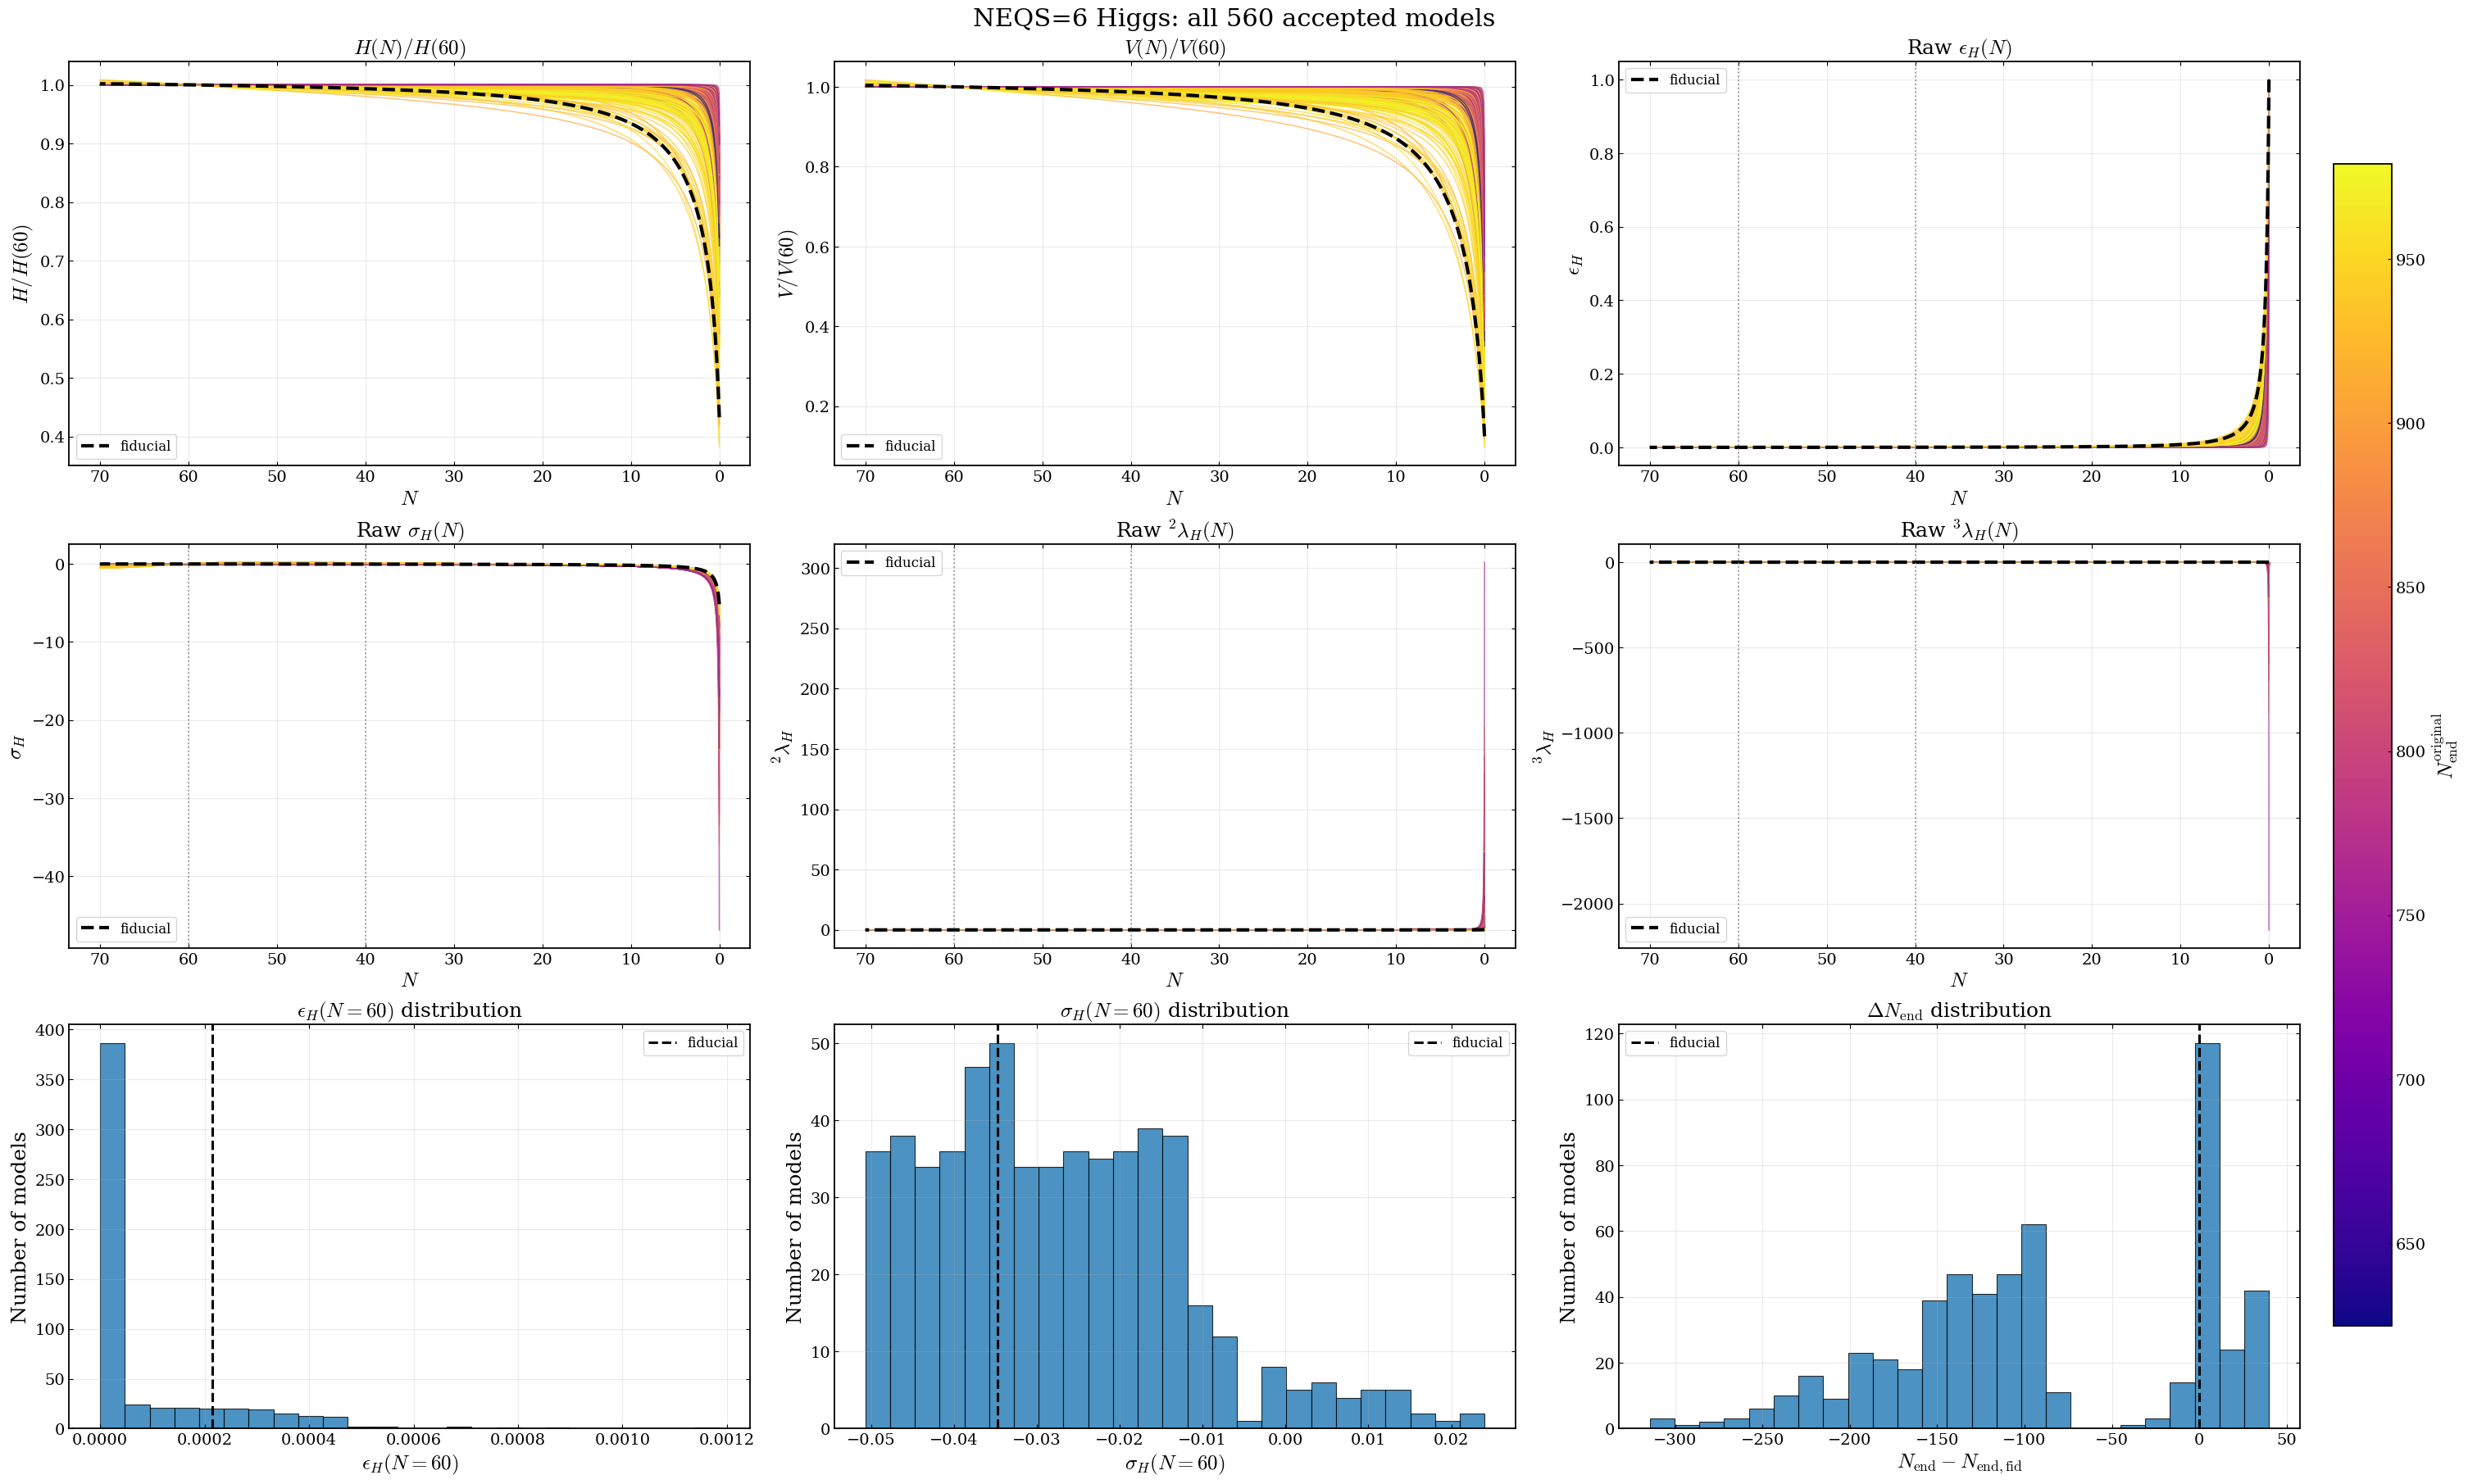

Figure saved to: paper_higgs_neqs6_all_models_background_and_flow_summary.pdf


In [8]:
# ============================================================
# CELL 5:

#All accepted models: background and slow-roll summary
#
# Shows EVERY model in summary_all, not only CMB-passing models.
#
# Panels:
#   H/H_60, V/V_60
#   epsilon_H(N), sigma_H(N)
#   lambda_2(N), lambda_3(N)
#   Delta N_end histogram
#
# Important:
# epsilon, sigma, lambda_2, and lambda_3 are NOT normalized.
# Their absolute spread at N=60 is the quantity of interest.
# ============================================================


plt.rcParams.update({
    "text.usetex": False,
    "mathtext.fontset": "cm",
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "DejaVu Serif"],
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 12,
    "figure.titlesize": 22,
    "axes.linewidth": 1.3,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
})


# Configuration
NEQS = 6
model_tag = "higgs"
N_ref = 60.0

# Restrict the visible N interval if desired.
# Set either value to None to use every available point.
N_plot_min = 0.0
N_plot_max = 70.0


# Load one saved trajectory
def load_path_from_outdir(outdir, NEQS=NEQS):
    folder = Path(outdir)

    matches = sorted(
        folder.glob(
            f"path_neqs{NEQS}_N0to70_paramsAtN60_lam2_*_lam3_*_lam4_*_lam5_*.dat"
        )
    )

    if not matches:
        raise FileNotFoundError(
            f"No path file found in:\n{folder}"
        )

    return np.loadtxt(matches[0]), matches[0]


# Prepare all quantities needed for plotting
def process_trajectory(
    data,
    N_ref=N_ref,
    NEQS=NEQS,
    N_min=N_plot_min,
    N_max=N_plot_max,
):
    """
    Extract and prepare the saved background trajectory.

    For NEQS=6, the saved columns are:

        0   phi
        1   H
        2   epsilon_H
        3   sigma_H
        4   lambda_2
        5   lambda_3
        6   N
        7   V
        8   kinetic-energy-like quantity
    """

    phi_raw = np.asarray(data[:, 0], dtype=float)
    H_raw = np.asarray(data[:, 1], dtype=float)
    eps_raw = np.asarray(data[:, 2], dtype=float)
    sigma_raw = np.asarray(data[:, 3], dtype=float)
    lam2_raw = np.asarray(data[:, 4], dtype=float)
    lam3_raw = np.asarray(data[:, 5], dtype=float)

    N_raw = np.asarray(data[:, NEQS], dtype=float)
    V_raw = np.asarray(data[:, NEQS + 1], dtype=float)

    finite = (
        np.isfinite(phi_raw)
        & np.isfinite(H_raw)
        & np.isfinite(eps_raw)
        & np.isfinite(sigma_raw)
        & np.isfinite(lam2_raw)
        & np.isfinite(lam3_raw)
        & np.isfinite(N_raw)
        & np.isfinite(V_raw)
    )

    phi_raw = phi_raw[finite]
    H_raw = H_raw[finite]
    eps_raw = eps_raw[finite]
    sigma_raw = sigma_raw[finite]
    lam2_raw = lam2_raw[finite]
    lam3_raw = lam3_raw[finite]
    N_raw = N_raw[finite]
    V_raw = V_raw[finite]

    if len(N_raw) < 2:
        raise ValueError("Not enough finite trajectory points.")

    # Ensure N is increasing for interpolation
    #Again this is checking monotonicity
    #Are consec terms going ++++ or ----
    dN = np.diff(N_raw)

    if np.all(dN >= 0):
        N = N_raw
        phi = phi_raw
        H = H_raw
        eps = eps_raw
        sigma = sigma_raw
        lam2 = lam2_raw
        lam3 = lam3_raw
        V = V_raw

    elif np.all(dN <= 0):
        N = N_raw[::-1]
        phi = phi_raw[::-1]
        H = H_raw[::-1]
        eps = eps_raw[::-1]
        sigma = sigma_raw[::-1]
        lam2 = lam2_raw[::-1]
        lam3 = lam3_raw[::-1]
        V = V_raw[::-1]

    else:
        raise ValueError(
            "N is non-monotonic; refusing to reorder trajectory."
        )

    # Require the normalization point
    if not (N.min() <= N_ref <= N.max()):
        raise ValueError(
            f"N_ref={N_ref} outside trajectory range "
            f"[{N.min():.6f}, {N.max():.6f}]"
        )

    H_ref = np.interp(N_ref, N, H)
    V_ref = np.interp(N_ref, N, V)

    if not np.isfinite(H_ref) or abs(H_ref) < 1e-30:
        raise ValueError(
            f"Invalid H_ref at N={N_ref}: {H_ref}"
        )

    if not np.isfinite(V_ref) or abs(V_ref) < 1e-30:
        raise ValueError(
            f"Invalid V_ref at N={N_ref}: {V_ref}"
        )

    # Optional plotting window, if I only wanna look at a certain range!
    plot_mask = np.ones_like(N, dtype=bool)

    if N_min is not None:
        plot_mask &= N >= N_min

    if N_max is not None:
        plot_mask &= N <= N_max

    if not np.any(plot_mask):
        raise ValueError(
            "No points remain inside the requested N plotting range."
        )

    return {
        "N": N[plot_mask],
        "phi": phi[plot_mask],

        # Only H and V are normalized by H for model at N=60 and same for V
        "H_norm": H[plot_mask] / H_ref,
        "V_norm": V[plot_mask] / V_ref,

        # Flow variables remain raw
        "epsilon": eps[plot_mask],
        "sigma": sigma[plot_mask],
        "lambda2": lam2[plot_mask],
        "lambda3": lam3[plot_mask],

        # Values exactly at N_ref, these interped
        #This using 1D linear interpolation
        #Such that line is drawn between two saved traj paths
        "epsilon_ref": np.interp(N_ref, N, eps),
        "sigma_ref": np.interp(N_ref, N, sigma),
        "lambda2_ref": np.interp(N_ref, N, lam2),
        "lambda3_ref": np.interp(N_ref, N, lam3),
    }


# Load every accepted model across every batch
summary_all = load_batch_summaries(
    NEQS=NEQS,
    base_path_root=base_path_root,
    model_tag=model_tag,
)

print(f"Total accepted models found: {len(summary_all)}")


# Identify the fiducial/base model
base_param_name, base_val = (
    MODEL_CONFIG[model_tag]["lam_base"][NEQS]
)

base_mask = np.isclose(
    summary_all[base_param_name].to_numpy(dtype=float),
    base_val,
    rtol=1e-8,
    atol=max(1e-15, abs(base_val) * 1e-8),
)

if not np.any(base_mask):
    raise FileNotFoundError(
        f"Could not find the base model with "
        f"{base_param_name}={base_val:.10e}"
    )

base_row = summary_all.loc[base_mask].iloc[0]

base_N_end = float(base_row["original_N_end"])

base_data, base_path_file = load_path_from_outdir(
    base_row["outdir"]
)

base_curves = process_trajectory(base_data)

print(f"Base model path:\n{base_path_file}")


# Process all accepted models
processed = []
failed = []

for row_index, row in summary_all.iterrows():
    try:
        data, path_file = load_path_from_outdir(
            row["outdir"]
        )

        curves = process_trajectory(data)

        N_end = float(row["original_N_end"])

        processed.append({
            **curves,
            "row_index": row_index,
            "path_file": path_file,
            "outdir": row["outdir"],
            "original_N_end": N_end,
            "deltaN_from_base": N_end - base_N_end,

            # Initial sampled values stored in the summary
            "eps_input": float(row["eps"]),
            "sig_input": float(row["sig"]),
            "lam2_input": float(row["lam2"]),
            "lam3_input": float(row["lam3"]),
        })

    except (FileNotFoundError, ValueError, KeyError) as exc:
        failed.append((row["outdir"], str(exc)))


print(
    f"Successfully processed {len(processed)} / "
    f"{len(summary_all)} accepted models"
)

if failed:
    print(f"Skipped models: {len(failed)}")
    for outdir, message in failed[:10]:
        print(f"  {outdir}: {message}")

    if len(failed) > 10:
        print(f"  ... and {len(failed) - 10} more")


if not processed:
    raise RuntimeError("No valid model trajectories were processed.")


# Color by original N_end
Nend_vals = np.asarray(
    [model["original_N_end"] for model in processed],
    dtype=float,
)

#it really should be already but
finite_Nend = np.isfinite(Nend_vals)

if not np.any(finite_Nend):
    raise ValueError("No finite original_N_end values found.")

Nend_min = np.nanmin(Nend_vals)
Nend_max = np.nanmax(Nend_vals)

# Avoid a zero-width color normalization
if np.isclose(Nend_min, Nend_max):
    Nend_min -= 0.5 #subtract this amount from existing value x = x - 0.5
    Nend_max += 0.5 #add this amount such that x = x + 0.5

cmap = plt.get_cmap("plasma")
norm = mcolors.Normalize(
    vmin=Nend_min,
    vmax=Nend_max,
)


# ------------------------------------------------------------
# Construct the figure
# ------------------------------------------------------------
fig, axes = plt.subplots(
    3,
    3,
    figsize=(30, 18),
    constrained_layout=True,
)

(
    ax_H,
    ax_V,
    ax_eps,
    ax_sigma,
    ax_lam2,
    ax_lam3,
    ax_eps60,
    ax_sig60,
    ax_deltaN,
) = axes.ravel()


# Every accepted model
for model in processed:
    color = cmap(norm(model["original_N_end"]))

    ax_H.plot(
        model["N"],
        model["H_norm"],
        color=color,
        lw=1.1,
        alpha=0.65,
    )

    ax_V.plot(
        model["N"],
        model["V_norm"],
        color=color,
        lw=1.1,
        alpha=0.65,
    )

    ax_eps.plot(
        model["N"],
        model["epsilon"],
        color=color,
        lw=1.1,
        alpha=0.65,
    )

    ax_sigma.plot(
        model["N"],
        model["sigma"],
        color=color,
        lw=1.1,
        alpha=0.65,
    )

    ax_lam2.plot(
        model["N"],
        model["lambda2"],
        color=color,
        lw=1.1,
        alpha=0.65,
    )

    ax_lam3.plot(
        model["N"],
        model["lambda3"],
        color=color,
        lw=1.1,
        alpha=0.65,
    )


# Fiducial model overlay
base_style = {
    "color": "black",
    "lw": 3.0,
    "ls": "--",
    "label": "fiducial",
}

ax_H.plot(
    base_curves["N"],
    base_curves["H_norm"],
    **base_style,
)

ax_V.plot(
    base_curves["N"],
    base_curves["V_norm"],
    **base_style,
)

ax_eps.plot(
    base_curves["N"],
    base_curves["epsilon"],
    **base_style,
)

ax_sigma.plot(
    base_curves["N"],
    base_curves["sigma"],
    **base_style,
)

ax_lam2.plot(
    base_curves["N"],
    base_curves["lambda2"],
    **base_style,
)

ax_lam3.plot(
    base_curves["N"],
    base_curves["lambda3"],
    **base_style,
)


# ------------------------------------------------------------
# N=60 distributions
# ------------------------------------------------------------
eps60_vals = np.asarray(
    [model["epsilon_ref"] for model in processed],
    dtype=float,
)

sig60_vals = np.asarray(
    [model["sigma_ref"] for model in processed],
    dtype=float,
)

deltaN_vals = np.asarray(
    [model["deltaN_from_base"] for model in processed],
    dtype=float,
)


ax_eps60.hist(
    eps60_vals,
    bins=25,
    alpha=0.8,
    edgecolor="black",
    linewidth=0.8,
)

ax_eps60.axvline(
    base_curves["epsilon_ref"],
    color="black",
    ls="--",
    lw=2.2,
    label="fiducial",
)


ax_sig60.hist(
    sig60_vals,
    bins=25,
    alpha=0.8,
    edgecolor="black",
    linewidth=0.8,
)

ax_sig60.axvline(
    base_curves["sigma_ref"],
    color="black",
    ls="--",
    lw=2.2,
    label="fiducial",
)


ax_deltaN.hist(
    deltaN_vals,
    bins=25,
    alpha=0.8,
    edgecolor="black",
    linewidth=0.8,
)

ax_deltaN.axvline(
    0.0,
    color="black",
    ls="--",
    lw=2.2,
    label="fiducial",
)


# Titles and labels
ax_H.set_title(
    rf"$H(N)/H({N_ref:g})$"
)

ax_V.set_title(
    rf"$V(N)/V({N_ref:g})$"
)

ax_eps.set_title(
    r"Raw $\epsilon_H(N)$"
)

ax_sigma.set_title(
    r"Raw $\sigma_H(N)$"
)

ax_lam2.set_title(
    r"Raw ${}^{2}\lambda_H(N)$"
)

ax_lam3.set_title(
    r"Raw ${}^{3}\lambda_H(N)$"
)

ax_eps60.set_title(
    rf"$\epsilon_H(N={N_ref:g})$ distribution"
)

ax_sig60.set_title(
    rf"$\sigma_H(N={N_ref:g})$ distribution"
)

ax_deltaN.set_title(
    r"$\Delta N_{\rm end}$ distribution"
)


for ax in [
    ax_H,
    ax_V,
    ax_eps,
    ax_sigma,
    ax_lam2,
    ax_lam3,
]:
    ax.set_xlabel(r"$N$")
    ax.invert_xaxis()


ax_H.set_ylabel(
    rf"$H/H({N_ref:g})$"
)

ax_V.set_ylabel(
    rf"$V/V({N_ref:g})$"
)

ax_eps.set_ylabel(
    r"$\epsilon_H$"
)

ax_sigma.set_ylabel(
    r"$\sigma_H$"
)

ax_lam2.set_ylabel(
    r"${}^{2}\lambda_H$"
)

ax_lam3.set_ylabel(
    r"${}^{3}\lambda_H$"
)

ax_eps60.set_xlabel(
    rf"$\epsilon_H(N={N_ref:g})$"
)

ax_eps60.set_ylabel(
    "Number of models"
)

ax_sig60.set_xlabel(
    rf"$\sigma_H(N={N_ref:g})$"
)

ax_sig60.set_ylabel(
    "Number of models"
)

ax_deltaN.set_xlabel(
    r"$N_{\rm end}-N_{\rm end,fid}$"
)

ax_deltaN.set_ylabel(
    "Number of models"
)


# ------------------------------------------------------------
# Styling
# ------------------------------------------------------------
for ax in axes.ravel():
    ax.grid(True, alpha=0.25)

    handles, labels = ax.get_legend_handles_labels()

    if handles:
        ax.legend()


# Mark N=60 and N=40 on the raw epsilon/sigma panels
for ax in [ax_eps, ax_sigma, ax_lam2, ax_lam3]:
    ax.axvline(
        60.0,
        color="gray",
        lw=1.3,
        ls=":",
        alpha=0.8,
    )

    ax.axvline(
        40.0,
        color="gray",
        lw=1.3,
        ls=":",
        alpha=0.8,
    )


# ------------------------------------------------------------
# Color bar
# ------------------------------------------------------------
sm = cm.ScalarMappable(
    cmap=cmap,
    norm=norm,
)

sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=axes[:, :].ravel().tolist(),
    pad=0.015,
    shrink=0.85,
)

cbar.set_label(
    r"$N_{\rm end}^{\rm original}$"
)

cbar.ax.tick_params(
    direction="in"
)

cbar_formatter = ScalarFormatter(
    useOffset=False
)

cbar_formatter.set_scientific(False)
cbar.formatter = cbar_formatter
cbar.update_ticks()


fig.suptitle(
    rf"NEQS={NEQS} {MODEL_CONFIG[model_tag]['label']}: "
    rf"all {len(processed)} accepted models"
)


output_name = (
    f"paper_{model_tag}_neqs{NEQS}_"
    "all_models_background_and_flow_summary.pdf"
)

fig.savefig(
    output_name,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Figure saved to: {output_name}")

Now, if I only want to consider models who have $|\Delta N| <= 20$:

In [9]:
def passes_deltaN_cut(
    N_end,
    base_N_end,
    deltaN_max=None,
    deltaN_min=None,
):
    """
    Decide whether a model passes a cut on its difference in N_end
    relative to the fiducial model.

    Parameters
    ----------
    N_end : float
        Original end-of-inflation value for the model.

    base_N_end : float
        Original end-of-inflation value for the fiducial model.

    deltaN_max : float or None
        Maximum allowed absolute value of Delta N_end.

        For example, deltaN_max=20 keeps:
            -20 <= Delta N_end <= 20

        If None, no symmetric maximum cut is applied.

    deltaN_min : float or None
        Optional minimum absolute displacement.

        For example, deltaN_min=5 and deltaN_max=20 keeps:
            5 <= |Delta N_end| <= 20

        Usually this should remain None.
    """

    N_end = float(N_end)
    base_N_end = float(base_N_end)

    if not np.isfinite(N_end):
        return False

    if not np.isfinite(base_N_end):
        raise ValueError("base_N_end must be finite.")

    deltaN = N_end - base_N_end
    abs_deltaN = abs(deltaN)

    if deltaN_max is not None:
        if deltaN_max < 0:
            raise ValueError("deltaN_max must be nonnegative.")

        if abs_deltaN > deltaN_max:
            return False

    if deltaN_min is not None:
        if deltaN_min < 0:
            raise ValueError("deltaN_min must be nonnegative.")

        if abs_deltaN < deltaN_min:
            return False

    return True


def process_models_with_deltaN_cut(
    summary_df,
    base_N_end,
    deltaN_max=None,
    deltaN_min=None,
    NEQS=NEQS,
    N_ref=N_ref,
):
    """
    Load and process model trajectories after applying a Delta N_end cut.

    The default cut is symmetric:

        |N_end - N_end_base| <= deltaN_max

    Returns
    -------
    processed : list of dict
        Successfully loaded models that passed the Delta N cut.

    rejected_deltaN : list of dict
        Models rejected specifically because of the Delta N cut.

    failed : list of tuple
        Models that passed the cut but could not be loaded or processed.
    """

    processed = []
    rejected_deltaN = []
    failed = []

    for row_index, row in summary_df.iterrows():

        try:
            N_end = float(row["original_N_end"])

        except (KeyError, TypeError, ValueError) as exc:
            failed.append(
                (
                    row.get("outdir", f"row {row_index}"),
                    f"Invalid original_N_end: {exc}",
                )
            )
            continue

        deltaN = N_end - base_N_end

        # Apply the Delta N selection before loading the path.
        # This avoids loading trajectory files that will not be plotted.
        if not passes_deltaN_cut(
            N_end=N_end,
            base_N_end=base_N_end,
            deltaN_max=deltaN_max,
            deltaN_min=deltaN_min,
        ):
            rejected_deltaN.append({
                "row_index": row_index,
                "outdir": row.get("outdir", None),
                "original_N_end": N_end,
                "deltaN_from_base": deltaN,
            })
            continue

        try:
            data, path_file = load_path_from_outdir(
                row["outdir"],
                NEQS=NEQS,
            )

            curves = process_trajectory(
                data,
                N_ref=N_ref,
                NEQS=NEQS,
            )

            processed.append({
                **curves,

                "row_index": row_index,
                "path_file": path_file,
                "outdir": row["outdir"],

                "original_N_end": N_end,
                "deltaN_from_base": deltaN,

                # Initial sampled slow-roll values
                "eps_input": float(row["eps"]),
                "sig_input": float(row["sig"]),
                "lam2_input": float(row["lam2"]),
                "lam3_input": float(row["lam3"]),
            })

        except (
            FileNotFoundError,
            ValueError,
            KeyError,
            TypeError,
        ) as exc:
            failed.append(
                (
                    row.get("outdir", f"row {row_index}"),
                    str(exc),
                )
            )

    return processed, rejected_deltaN, failed


In [10]:
DELTA_N_MAX = 20.0

processed, rejected_deltaN, failed = (
    process_models_with_deltaN_cut(
        summary_df=summary_all,
        base_N_end=base_N_end,
        deltaN_max=DELTA_N_MAX,
        deltaN_min=None,
        NEQS=NEQS,
        N_ref=N_ref,
    )
)

Total accepted models found: 560
Base model path:
/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs6_higgs_batch001/lam2_2.7897200000e-04_lam3_-4.6097100000e-06_lam4_0.0000000000e+00_lam5_0.0000000000e+00/path_neqs6_N0to70_paramsAtN60_lam2_2.7897200000e-04_lam3_-4.6097100000e-06_lam4_0.0000000000e+00_lam5_0.0000000000e+00.dat
Successfully processed 148 / 560 accepted models with |deltaN| <= 20
Rejected by deltaN cut: 412


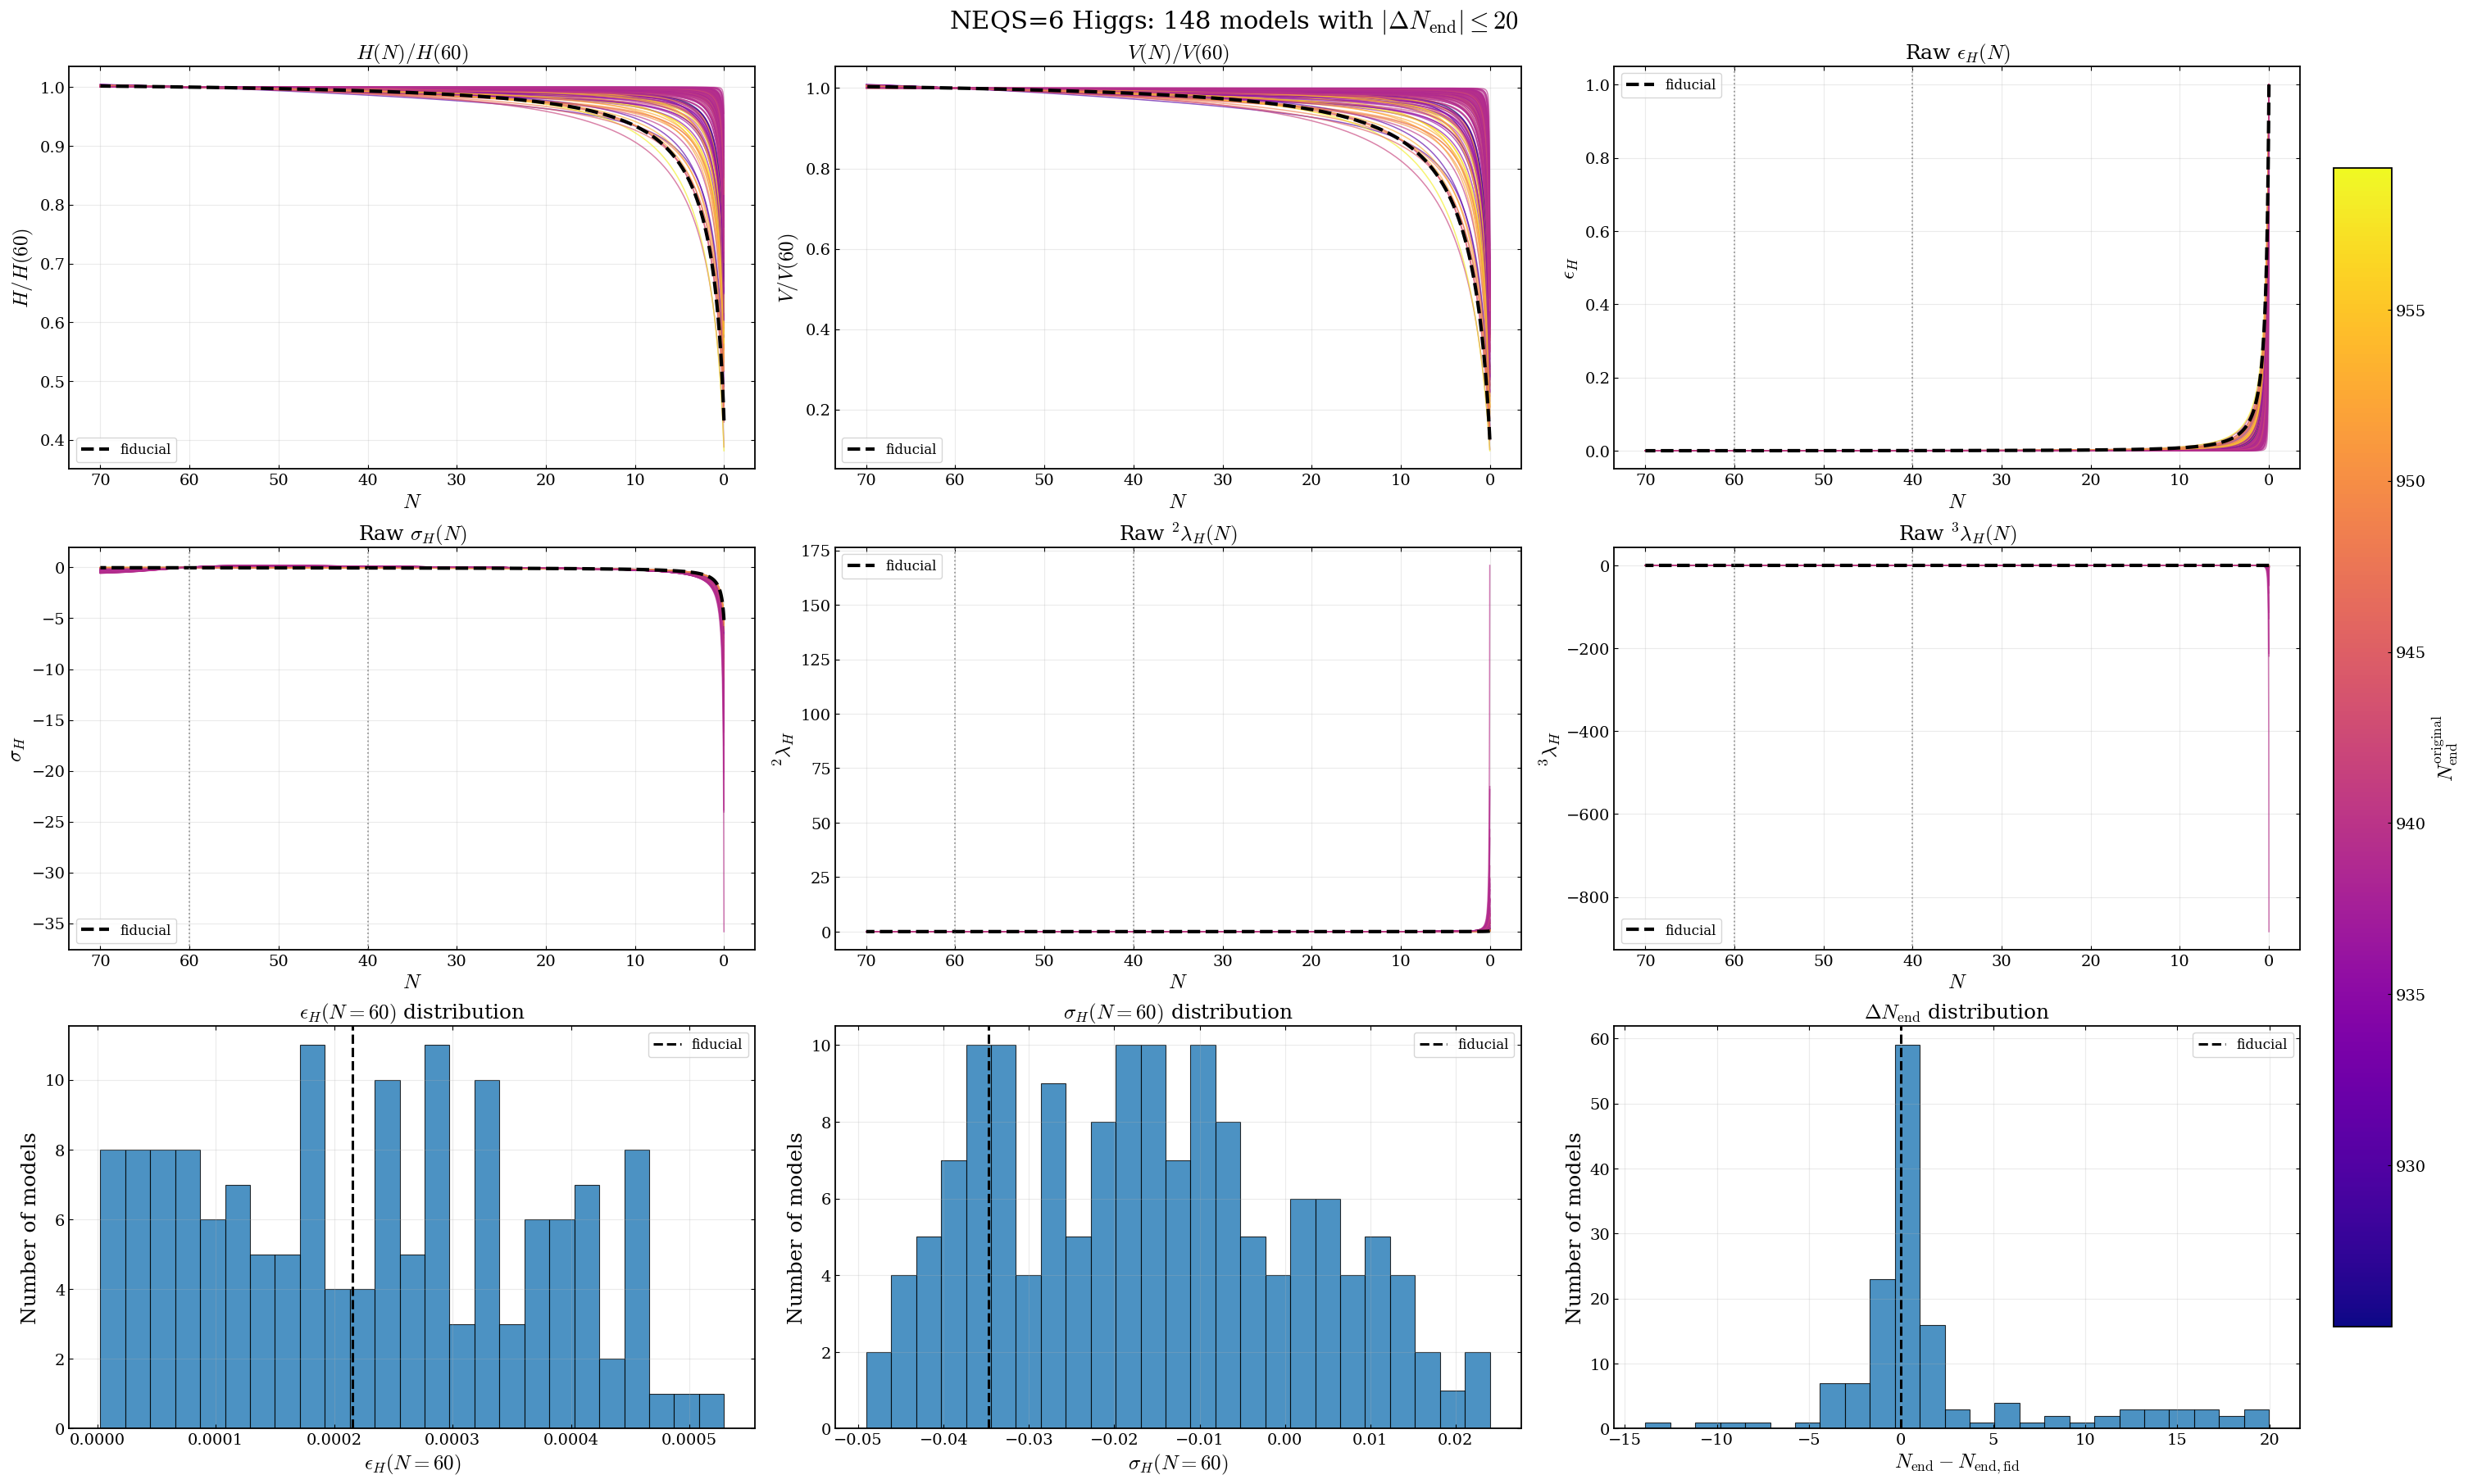

Figure saved to: paper_higgs_neqs6_deltaNmax_20_background_summary.pdf


In [11]:
# ============================================================
# CELL X:

#All accepted models: background and slow-roll summary
#
# Shows EVERY model in summary_all, not only CMB-passing models.
#
# Panels:
#   H/H_60, V/V_60
#   epsilon_H(N), sigma_H(N)
#   lambda_2(N), lambda_3(N)
#   Delta N_end histogram
#
# Important:
# epsilon, sigma, lambda_2, and lambda_3 are NOT normalized.
# Their absolute spread at N=60 is the quantity of interest.
# ============================================================


plt.rcParams.update({
    "text.usetex": False,
    "mathtext.fontset": "cm",
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "DejaVu Serif"],
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 12,
    "figure.titlesize": 22,
    "axes.linewidth": 1.3,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
})


# Configuration
NEQS = 6
model_tag = "higgs"
N_ref = 60.0

# Restrict the visible N interval if desired.
# Set either value to None to use every available point.
N_plot_min = 0.0
N_plot_max = 70.0
DELTA_N_MAX = 20.0

# Load one saved trajectory
def load_path_from_outdir(outdir, NEQS=NEQS):
    folder = Path(outdir)

    matches = sorted(
        folder.glob(
            f"path_neqs{NEQS}_N0to70_paramsAtN60_lam2_*_lam3_*_lam4_*_lam5_*.dat"
        )
    )

    if not matches:
        raise FileNotFoundError(
            f"No path file found in:\n{folder}"
        )

    return np.loadtxt(matches[0]), matches[0]


# Prepare all quantities needed for plotting
def process_trajectory_maxN(
    data,
    N_ref=N_ref,
    NEQS=NEQS,
    N_min=N_plot_min,
    N_max=N_plot_max,
):
    """
    Extract and prepare the saved background trajectory.

    For NEQS=6, the saved columns are:

        0   phi
        1   H
        2   epsilon_H
        3   sigma_H
        4   lambda_2
        5   lambda_3
        6   N
        7   V
        8   kinetic-energy-like quantity
    """

    phi_raw = np.asarray(data[:, 0], dtype=float)
    H_raw = np.asarray(data[:, 1], dtype=float)
    eps_raw = np.asarray(data[:, 2], dtype=float)
    sigma_raw = np.asarray(data[:, 3], dtype=float)
    lam2_raw = np.asarray(data[:, 4], dtype=float)
    lam3_raw = np.asarray(data[:, 5], dtype=float)

    N_raw = np.asarray(data[:, NEQS], dtype=float)
    V_raw = np.asarray(data[:, NEQS + 1], dtype=float)

    finite = (
        np.isfinite(phi_raw)
        & np.isfinite(H_raw)
        & np.isfinite(eps_raw)
        & np.isfinite(sigma_raw)
        & np.isfinite(lam2_raw)
        & np.isfinite(lam3_raw)
        & np.isfinite(N_raw)
        & np.isfinite(V_raw)
    )

    phi_raw = phi_raw[finite]
    H_raw = H_raw[finite]
    eps_raw = eps_raw[finite]
    sigma_raw = sigma_raw[finite]
    lam2_raw = lam2_raw[finite]
    lam3_raw = lam3_raw[finite]
    N_raw = N_raw[finite]
    V_raw = V_raw[finite]

    if len(N_raw) < 2:
        raise ValueError("Not enough finite trajectory points.")

    # Ensure N is increasing for interpolation
    #Again this is checking monotonicity
    #Are consec terms going ++++ or ----
    dN = np.diff(N_raw)

    if np.all(dN >= 0):
        N = N_raw
        phi = phi_raw
        H = H_raw
        eps = eps_raw
        sigma = sigma_raw
        lam2 = lam2_raw
        lam3 = lam3_raw
        V = V_raw

    elif np.all(dN <= 0):
        N = N_raw[::-1]
        phi = phi_raw[::-1]
        H = H_raw[::-1]
        eps = eps_raw[::-1]
        sigma = sigma_raw[::-1]
        lam2 = lam2_raw[::-1]
        lam3 = lam3_raw[::-1]
        V = V_raw[::-1]

    else:
        raise ValueError(
            "N is non-monotonic; refusing to reorder trajectory."
        )

    # Require the normalization point
    if not (N.min() <= N_ref <= N.max()):
        raise ValueError(
            f"N_ref={N_ref} outside trajectory range "
            f"[{N.min():.6f}, {N.max():.6f}]"
        )

    H_ref = np.interp(N_ref, N, H)
    V_ref = np.interp(N_ref, N, V)

    if not np.isfinite(H_ref) or abs(H_ref) < 1e-30:
        raise ValueError(
            f"Invalid H_ref at N={N_ref}: {H_ref}"
        )

    if not np.isfinite(V_ref) or abs(V_ref) < 1e-30:
        raise ValueError(
            f"Invalid V_ref at N={N_ref}: {V_ref}"
        )

    # Optional plotting window, if I only wanna look at a certain range!
    plot_mask = np.ones_like(N, dtype=bool)

    if N_min is not None:
        plot_mask &= N >= N_min

    if N_max is not None:
        plot_mask &= N <= N_max

    if not np.any(plot_mask):
        raise ValueError(
            "No points remain inside the requested N plotting range."
        )

    return {
        "N": N[plot_mask],
        "phi": phi[plot_mask],

        # Only H and V are normalized by H for model at N=60 and same for V
        "H_norm": H[plot_mask] / H_ref,
        "V_norm": V[plot_mask] / V_ref,

        # Flow variables remain raw
        "epsilon": eps[plot_mask],
        "sigma": sigma[plot_mask],
        "lambda2": lam2[plot_mask],
        "lambda3": lam3[plot_mask],

        # Values exactly at N_ref, these interped
        #This using 1D linear interpolation
        #Such that line is drawn between two saved traj paths
        "epsilon_ref": np.interp(N_ref, N, eps),
        "sigma_ref": np.interp(N_ref, N, sigma),
        "lambda2_ref": np.interp(N_ref, N, lam2),
        "lambda3_ref": np.interp(N_ref, N, lam3),
    }


# Load every accepted model across every batch
summary_all = load_batch_summaries(
    NEQS=NEQS,
    base_path_root=base_path_root,
    model_tag=model_tag,
)

print(f"Total accepted models found: {len(summary_all)}")


# Identify the fiducial/base model
base_param_name, base_val = (
    MODEL_CONFIG[model_tag]["lam_base"][NEQS]
)

base_mask = np.isclose(
    summary_all[base_param_name].to_numpy(dtype=float),
    base_val,
    rtol=1e-8,
    atol=max(1e-15, abs(base_val) * 1e-8),
)

if not np.any(base_mask):
    raise FileNotFoundError(
        f"Could not find the base model with "
        f"{base_param_name}={base_val:.10e}"
    )

base_row = summary_all.loc[base_mask].iloc[0]

base_N_end = float(base_row["original_N_end"])

base_data, base_path_file = load_path_from_outdir(
    base_row["outdir"]
)

base_curves = process_trajectory_maxN(base_data)

print(f"Base model path:\n{base_path_file}")

# Process models satisfying the Delta N cut
processed = []
failed = []
rejected_deltaN = []

for row_index, row in summary_all.iterrows():
    try:
        N_end = float(row["original_N_end"])
        deltaN_from_base = N_end - base_N_end

        # Keep only models within the chosen symmetric Delta N range
        if abs(deltaN_from_base) > DELTA_N_MAX:
            rejected_deltaN.append({
                "row_index": row_index,
                "outdir": row["outdir"],
                "original_N_end": N_end,
                "deltaN_from_base": deltaN_from_base,
            })
            continue

        data, path_file = load_path_from_outdir(
            row["outdir"]
        )

        curves = process_trajectory_maxN(data)

        processed.append({
            **curves,
            "row_index": row_index,
            "path_file": path_file,
            "outdir": row["outdir"],
            "original_N_end": N_end,
            "deltaN_from_base": deltaN_from_base,

            # Initial sampled values stored in the summary
            "eps_input": float(row["eps"]),
            "sig_input": float(row["sig"]),
            "lam2_input": float(row["lam2"]),
            "lam3_input": float(row["lam3"]),
        })

    except (FileNotFoundError, ValueError, KeyError) as exc:
        failed.append((row["outdir"], str(exc)))
        

print(
    f"Successfully processed {len(processed)} / "
    f"{len(summary_all)} accepted models "
    f"with |deltaN| <= {DELTA_N_MAX:g}"
)

print(
    f"Rejected by deltaN cut: {len(rejected_deltaN)}"
)

if failed:
    print(f"Skipped models: {len(failed)}")
    for outdir, message in failed[:10]:
        print(f"  {outdir}: {message}")

    if len(failed) > 10:
        print(f"  ... and {len(failed) - 10} more")


if not processed:
    raise RuntimeError("No valid model trajectories were processed.")


# Color by original N_end
Nend_vals = np.asarray(
    [model["original_N_end"] for model in processed],
    dtype=float,
)

#it really should be already but
finite_Nend = np.isfinite(Nend_vals)

if not np.any(finite_Nend):
    raise ValueError("No finite original_N_end values found.")

Nend_min = np.nanmin(Nend_vals)
Nend_max = np.nanmax(Nend_vals)

# Avoid a zero-width color normalization
if np.isclose(Nend_min, Nend_max):
    Nend_min -= 0.5 #subtract this amount from existing value x = x - 0.5
    Nend_max += 0.5 #add this amount such that x = x + 0.5

cmap = plt.get_cmap("plasma")
norm = mcolors.Normalize(
    vmin=Nend_min,
    vmax=Nend_max,
)


# ------------------------------------------------------------
# Construct the figure
# ------------------------------------------------------------
fig, axes = plt.subplots(
    3,
    3,
    figsize=(30, 18),
    constrained_layout=True,
)

(
    ax_H,
    ax_V,
    ax_eps,
    ax_sigma,
    ax_lam2,
    ax_lam3,
    ax_eps60,
    ax_sig60,
    ax_deltaN,
) = axes.ravel()


# Every accepted model
for model in processed:
    color = cmap(norm(model["original_N_end"]))

    ax_H.plot(
        model["N"],
        model["H_norm"],
        color=color,
        lw=1.1,
        alpha=0.65,
    )

    ax_V.plot(
        model["N"],
        model["V_norm"],
        color=color,
        lw=1.1,
        alpha=0.65,
    )

    ax_eps.plot(
        model["N"],
        model["epsilon"],
        color=color,
        lw=1.1,
        alpha=0.65,
    )

    ax_sigma.plot(
        model["N"],
        model["sigma"],
        color=color,
        lw=1.1,
        alpha=0.65,
    )

    ax_lam2.plot(
        model["N"],
        model["lambda2"],
        color=color,
        lw=1.1,
        alpha=0.65,
    )

    ax_lam3.plot(
        model["N"],
        model["lambda3"],
        color=color,
        lw=1.1,
        alpha=0.65,
    )


# Fiducial model overlay
base_style = {
    "color": "black",
    "lw": 3.0,
    "ls": "--",
    "label": "fiducial",
}

ax_H.plot(
    base_curves["N"],
    base_curves["H_norm"],
    **base_style,
)

ax_V.plot(
    base_curves["N"],
    base_curves["V_norm"],
    **base_style,
)

ax_eps.plot(
    base_curves["N"],
    base_curves["epsilon"],
    **base_style,
)

ax_sigma.plot(
    base_curves["N"],
    base_curves["sigma"],
    **base_style,
)

ax_lam2.plot(
    base_curves["N"],
    base_curves["lambda2"],
    **base_style,
)

ax_lam3.plot(
    base_curves["N"],
    base_curves["lambda3"],
    **base_style,
)


# ------------------------------------------------------------
# N=60 distributions
# ------------------------------------------------------------
eps60_vals = np.asarray(
    [model["epsilon_ref"] for model in processed],
    dtype=float,
)

sig60_vals = np.asarray(
    [model["sigma_ref"] for model in processed],
    dtype=float,
)

deltaN_vals = np.asarray(
    [model["deltaN_from_base"] for model in processed],
    dtype=float,
)


ax_eps60.hist(
    eps60_vals,
    bins=25,
    alpha=0.8,
    edgecolor="black",
    linewidth=0.8,
)

ax_eps60.axvline(
    base_curves["epsilon_ref"],
    color="black",
    ls="--",
    lw=2.2,
    label="fiducial",
)


ax_sig60.hist(
    sig60_vals,
    bins=25,
    alpha=0.8,
    edgecolor="black",
    linewidth=0.8,
)

ax_sig60.axvline(
    base_curves["sigma_ref"],
    color="black",
    ls="--",
    lw=2.2,
    label="fiducial",
)


ax_deltaN.hist(
    deltaN_vals,
    bins=25,
    alpha=0.8,
    edgecolor="black",
    linewidth=0.8,
)

ax_deltaN.axvline(
    0.0,
    color="black",
    ls="--",
    lw=2.2,
    label="fiducial",
)


# Titles and labels
ax_H.set_title(
    rf"$H(N)/H({N_ref:g})$"
)

ax_V.set_title(
    rf"$V(N)/V({N_ref:g})$"
)

ax_eps.set_title(
    r"Raw $\epsilon_H(N)$"
)

ax_sigma.set_title(
    r"Raw $\sigma_H(N)$"
)

ax_lam2.set_title(
    r"Raw ${}^{2}\lambda_H(N)$"
)

ax_lam3.set_title(
    r"Raw ${}^{3}\lambda_H(N)$"
)

ax_eps60.set_title(
    rf"$\epsilon_H(N={N_ref:g})$ distribution"
)

ax_sig60.set_title(
    rf"$\sigma_H(N={N_ref:g})$ distribution"
)

ax_deltaN.set_title(
    r"$\Delta N_{\rm end}$ distribution"
)


for ax in [
    ax_H,
    ax_V,
    ax_eps,
    ax_sigma,
    ax_lam2,
    ax_lam3,
]:
    ax.set_xlabel(r"$N$")
    ax.invert_xaxis()


ax_H.set_ylabel(
    rf"$H/H({N_ref:g})$"
)

ax_V.set_ylabel(
    rf"$V/V({N_ref:g})$"
)

ax_eps.set_ylabel(
    r"$\epsilon_H$"
)

ax_sigma.set_ylabel(
    r"$\sigma_H$"
)

ax_lam2.set_ylabel(
    r"${}^{2}\lambda_H$"
)

ax_lam3.set_ylabel(
    r"${}^{3}\lambda_H$"
)

ax_eps60.set_xlabel(
    rf"$\epsilon_H(N={N_ref:g})$"
)

ax_eps60.set_ylabel(
    "Number of models"
)

ax_sig60.set_xlabel(
    rf"$\sigma_H(N={N_ref:g})$"
)

ax_sig60.set_ylabel(
    "Number of models"
)

ax_deltaN.set_xlabel(
    r"$N_{\rm end}-N_{\rm end,fid}$"
)

ax_deltaN.set_ylabel(
    "Number of models"
)


# ------------------------------------------------------------
# Styling
# ------------------------------------------------------------
for ax in axes.ravel():
    ax.grid(True, alpha=0.25)

    handles, labels = ax.get_legend_handles_labels()

    if handles:
        ax.legend()


# Mark N=60 and N=40 on the raw epsilon/sigma panels
for ax in [ax_eps, ax_sigma, ax_lam2, ax_lam3]:
    ax.axvline(
        60.0,
        color="gray",
        lw=1.3,
        ls=":",
        alpha=0.8,
    )

    ax.axvline(
        40.0,
        color="gray",
        lw=1.3,
        ls=":",
        alpha=0.8,
    )


# ------------------------------------------------------------
# Color bar
# ------------------------------------------------------------
sm = cm.ScalarMappable(
    cmap=cmap,
    norm=norm,
)

sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=axes[:, :].ravel().tolist(),
    pad=0.015,
    shrink=0.85,
)

cbar.set_label(
    r"$N_{\rm end}^{\rm original}$"
)

cbar.ax.tick_params(
    direction="in"
)

cbar_formatter = ScalarFormatter(
    useOffset=False
)

cbar_formatter.set_scientific(False)
cbar.formatter = cbar_formatter
cbar.update_ticks()


fig.suptitle(
    rf"NEQS={NEQS} {MODEL_CONFIG[model_tag]['label']}: "
    rf"{len(processed)} models with "
    rf"$|\Delta N_{{\rm end}}| \leq {DELTA_N_MAX:g}$"
)

output_name = (
    f"paper_{model_tag}_neqs{NEQS}_"
    f"deltaNmax_{DELTA_N_MAX:g}_background_summary.pdf"
)

fig.savefig(
    output_name,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Figure saved to: {output_name}")

If I want to compare them on the same plot:

Total accepted models found: 560
Base model path:
/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs6_higgs_batch001/lam2_2.7897200000e-04_lam3_-4.6097100000e-06_lam4_0.0000000000e+00_lam5_0.0000000000e+00/path_neqs6_N0to70_paramsAtN60_lam2_2.7897200000e-04_lam3_-4.6097100000e-06_lam4_0.0000000000e+00_lam5_0.0000000000e+00.dat

DELTA N CLASSIFICATION
Total accepted models found : 560
Delta N maximum             : 20
Models passing cut          : 148
Models failing cut          : 412
Models failing to load      : 0


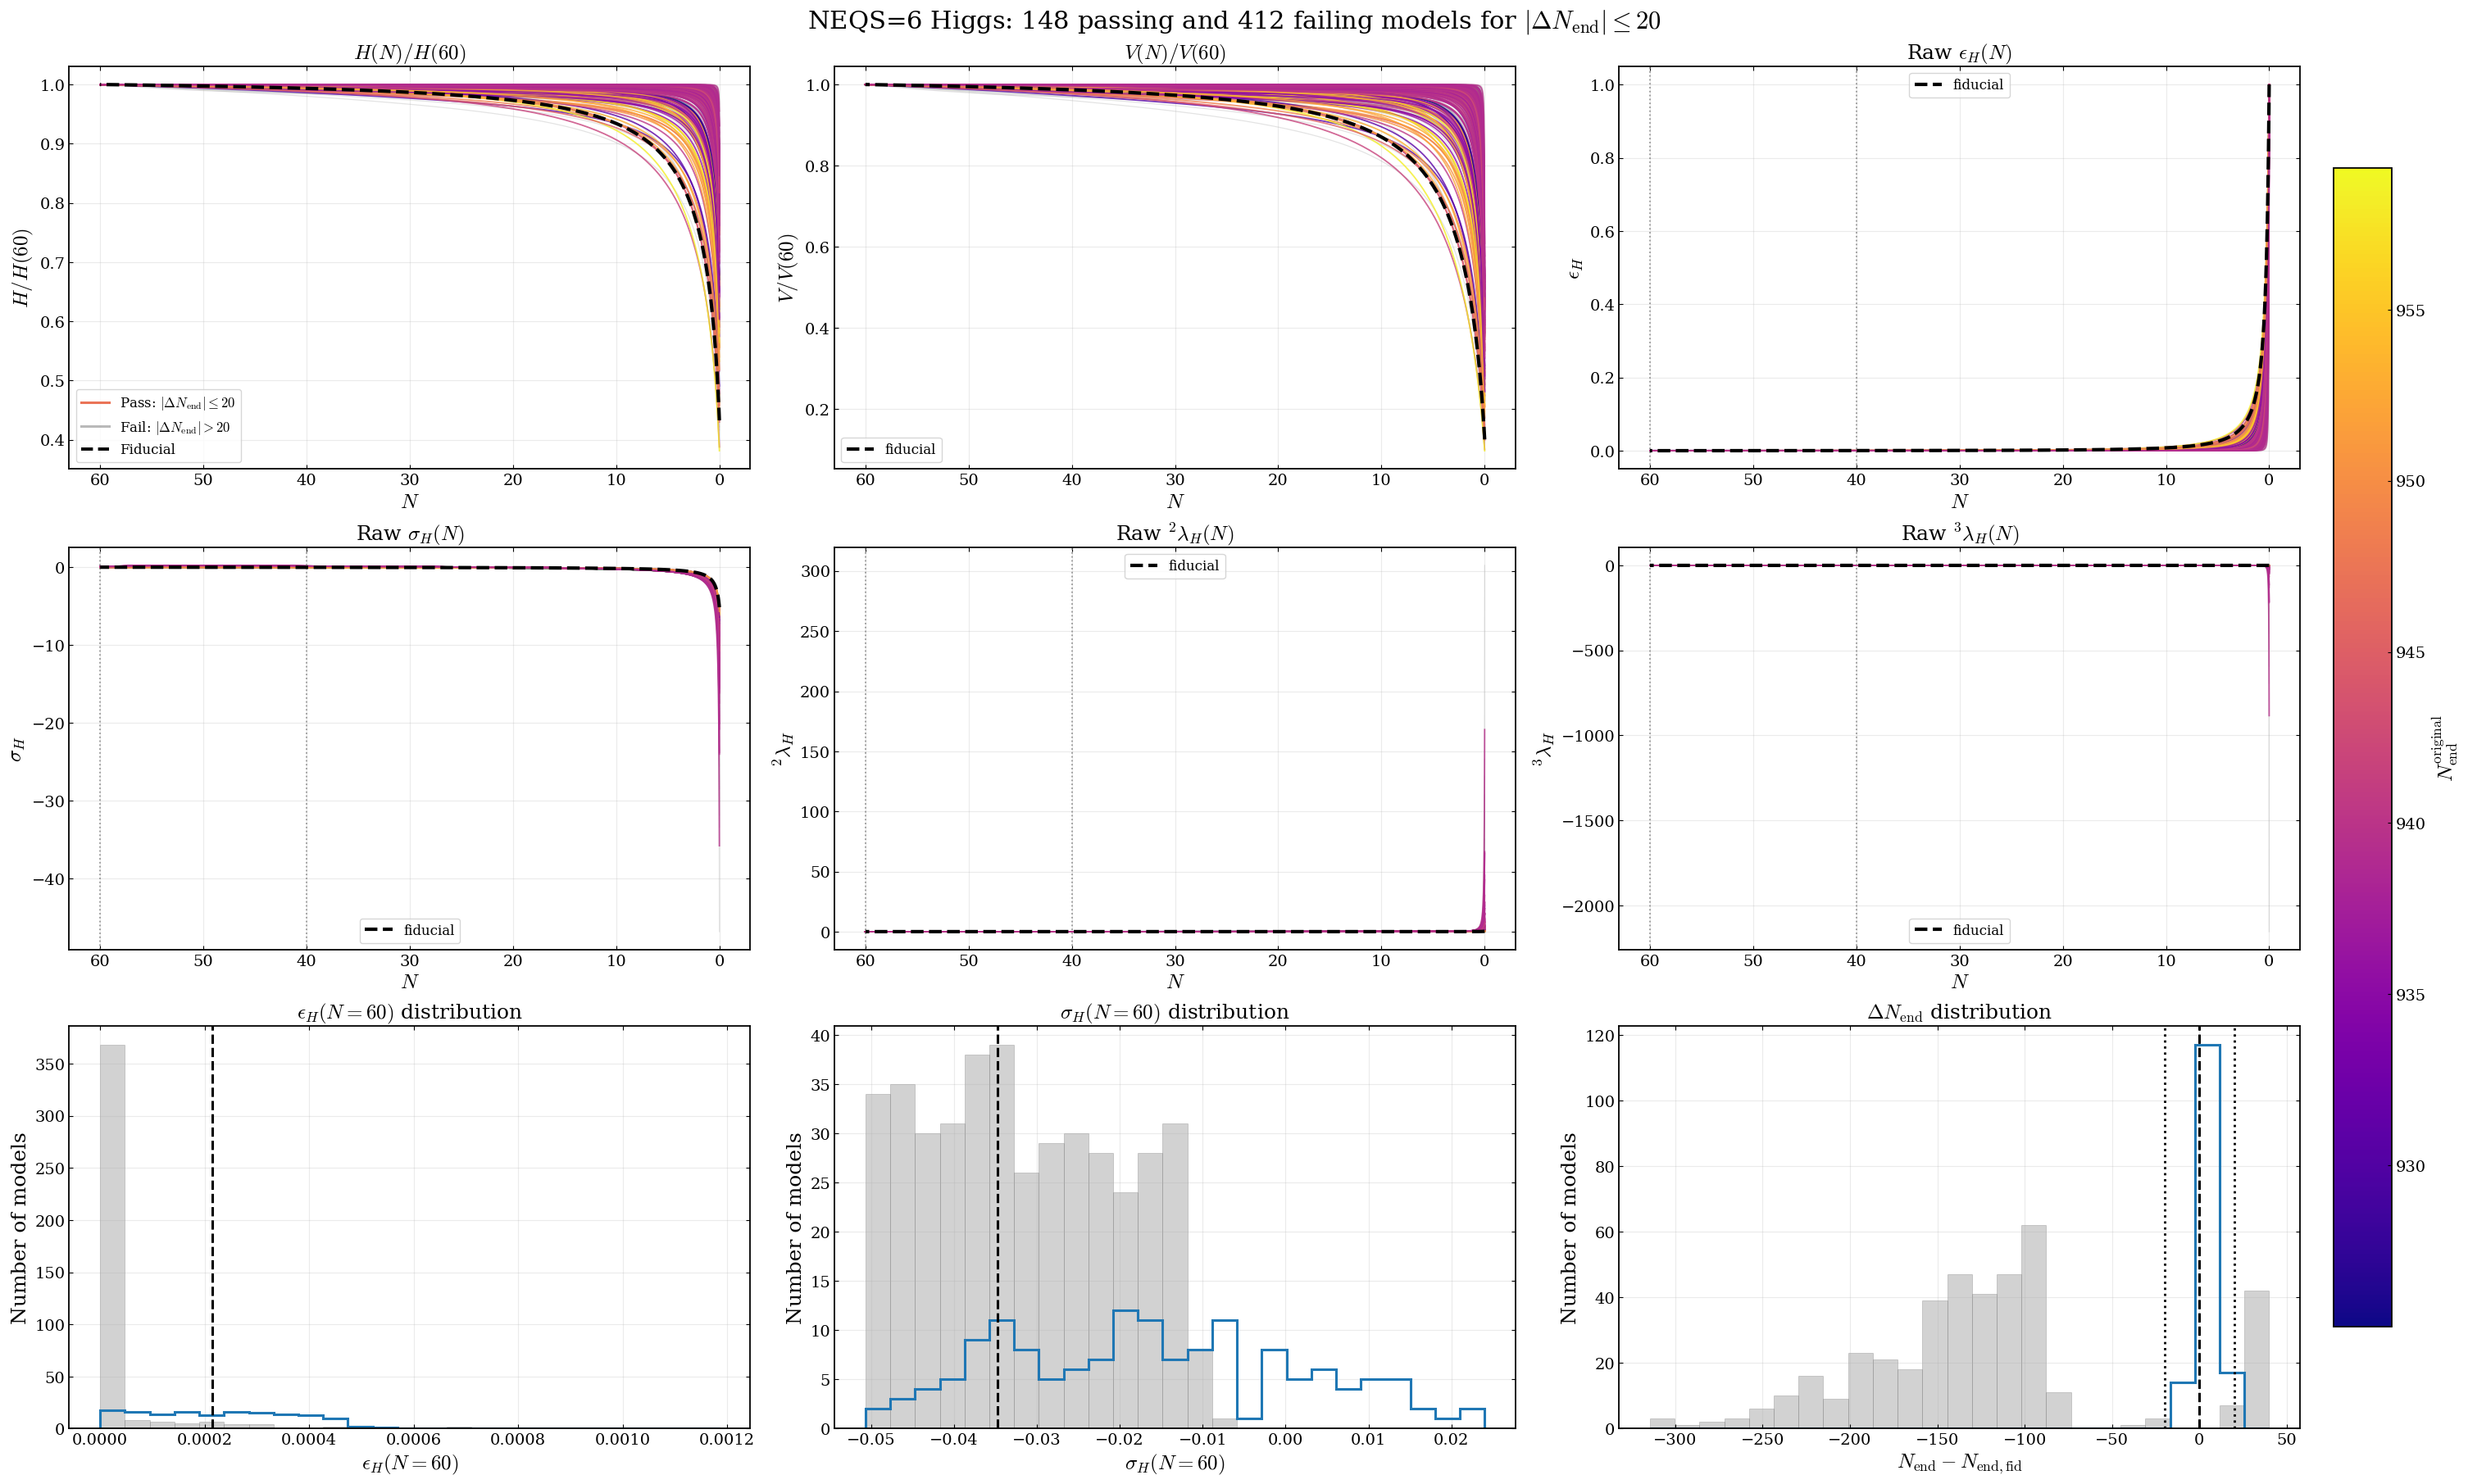

Figure saved to: paper_higgs_neqs6_deltaNmax_20_background_summary.pdf


In [12]:
# ============================================================
# CELL X:

#This will show all models and all the ones that got cut!

# ============================================================


plt.rcParams.update({
    "text.usetex": False,
    "mathtext.fontset": "cm",
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "DejaVu Serif"],
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 12,
    "figure.titlesize": 22,
    "axes.linewidth": 1.3,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
})


# Configuration
NEQS = 6
model_tag = "higgs"
N_ref = 60.0

# Restrict the visible N interval if desired.
# Set either value to None to use every available point.
N_plot_min = 0.0
N_plot_max = 60.0
DELTA_N_MAX = 20.0

# Load one saved trajectory
def load_path_from_outdir(outdir, NEQS=NEQS):
    folder = Path(outdir)

    matches = sorted(
        folder.glob(
            f"path_neqs{NEQS}_N0to70_paramsAtN60_lam2_*_lam3_*_lam4_*_lam5_*.dat"
        )
    )

    if not matches:
        raise FileNotFoundError(
            f"No path file found in:\n{folder}"
        )

    return np.loadtxt(matches[0]), matches[0]


# Prepare all quantities needed for plotting
def process_trajectory_maxN_both(
    data,
    N_ref=N_ref,
    NEQS=NEQS,
    N_min=N_plot_min,
    N_max=N_plot_max,
):
    """
    Extract and prepare the saved background trajectory.

    For NEQS=6, the saved columns are:

        0   phi
        1   H
        2   epsilon_H
        3   sigma_H
        4   lambda_2
        5   lambda_3
        6   N
        7   V
        8   kinetic-energy-like quantity
    """

    phi_raw = np.asarray(data[:, 0], dtype=float)
    H_raw = np.asarray(data[:, 1], dtype=float)
    eps_raw = np.asarray(data[:, 2], dtype=float)
    sigma_raw = np.asarray(data[:, 3], dtype=float)
    lam2_raw = np.asarray(data[:, 4], dtype=float)
    lam3_raw = np.asarray(data[:, 5], dtype=float)

    N_raw = np.asarray(data[:, NEQS], dtype=float)
    V_raw = np.asarray(data[:, NEQS + 1], dtype=float)

    finite = (
        np.isfinite(phi_raw)
        & np.isfinite(H_raw)
        & np.isfinite(eps_raw)
        & np.isfinite(sigma_raw)
        & np.isfinite(lam2_raw)
        & np.isfinite(lam3_raw)
        & np.isfinite(N_raw)
        & np.isfinite(V_raw)
    )

    phi_raw = phi_raw[finite]
    H_raw = H_raw[finite]
    eps_raw = eps_raw[finite]
    sigma_raw = sigma_raw[finite]
    lam2_raw = lam2_raw[finite]
    lam3_raw = lam3_raw[finite]
    N_raw = N_raw[finite]
    V_raw = V_raw[finite]

    if len(N_raw) < 2:
        raise ValueError("Not enough finite trajectory points.")

    # Ensure N is increasing for interpolation
    #Again this is checking monotonicity
    #Are consec terms going ++++ or ----
    dN = np.diff(N_raw)

    if np.all(dN >= 0):
        N = N_raw
        phi = phi_raw
        H = H_raw
        eps = eps_raw
        sigma = sigma_raw
        lam2 = lam2_raw
        lam3 = lam3_raw
        V = V_raw

    elif np.all(dN <= 0):
        N = N_raw[::-1]
        phi = phi_raw[::-1]
        H = H_raw[::-1]
        eps = eps_raw[::-1]
        sigma = sigma_raw[::-1]
        lam2 = lam2_raw[::-1]
        lam3 = lam3_raw[::-1]
        V = V_raw[::-1]

    else:
        raise ValueError(
            "N is non-monotonic; refusing to reorder trajectory."
        )

    # Require the normalization point
    #Guard before interpolation
    if not (N.min() <= N_ref <= N.max()):
        raise ValueError(
            f"N_ref={N_ref} outside trajectory range "
            f"[{N.min():.6f}, {N.max():.6f}]"
        )

    H_ref = np.interp(N_ref, N, H)
    V_ref = np.interp(N_ref, N, V)

    if not np.isfinite(H_ref) or abs(H_ref) < 1e-30:
        raise ValueError(
            f"Invalid H_ref at N={N_ref}: {H_ref}"
        )

    if not np.isfinite(V_ref) or abs(V_ref) < 1e-30:
        raise ValueError(
            f"Invalid V_ref at N={N_ref}: {V_ref}"
        )

    # Optional plotting window, if I only wanna look at a certain range!
    plot_mask = np.ones_like(N, dtype=bool)

    if N_min is not None:
        plot_mask &= N >= N_min

    if N_max is not None:
        plot_mask &= N <= N_max

    if not np.any(plot_mask):
        raise ValueError(
            "No points remain inside the requested N plotting range."
        )

    return {
        "N": N[plot_mask],
        "phi": phi[plot_mask],

        # Only H and V are normalized by H for model at N=60 and same for V
        "H_norm": H[plot_mask] / H_ref,
        "V_norm": V[plot_mask] / V_ref,

        # Flow variables remain raw
        "epsilon": eps[plot_mask],
        "sigma": sigma[plot_mask],
        "lambda2": lam2[plot_mask],
        "lambda3": lam3[plot_mask],

        # Values exactly at N_ref, these interped
        #This using 1D linear interpolation
        #Such that line is drawn between two saved traj paths
        "epsilon_ref": np.interp(N_ref, N, eps),
        "sigma_ref": np.interp(N_ref, N, sigma),
        "lambda2_ref": np.interp(N_ref, N, lam2),
        "lambda3_ref": np.interp(N_ref, N, lam3),
    }


# Load every accepted model across every batch
summary_all = load_batch_summaries(
    NEQS=NEQS,
    base_path_root=base_path_root,
    model_tag=model_tag,
)

print(f"Total accepted models found: {len(summary_all)}")


# Identify the fiducial/base model
base_param_name, base_val = (
    MODEL_CONFIG[model_tag]["lam_base"][NEQS]
)

base_mask = np.isclose(
    summary_all[base_param_name].to_numpy(dtype=float),
    base_val,
    rtol=1e-8,
    atol=max(1e-15, abs(base_val) * 1e-8),
)

if not np.any(base_mask):
    raise FileNotFoundError(
        f"Could not find the base model with "
        f"{base_param_name}={base_val:.10e}"
    )

base_row = summary_all.loc[base_mask].iloc[0]

base_N_end = float(base_row["original_N_end"])

base_data, base_path_file = load_path_from_outdir(
    base_row["outdir"]
)

base_curves = process_trajectory_maxN_both(base_data)

print(f"Base model path:\n{base_path_file}")

# Process models satisfying the Delta N cut
processed = []
failed = []
rejected_deltaN = []

# ============================================================
# Process all models and classify them by the Delta N cut
# ============================================================

passed_models = []
rejected_models = []
failed = []

for row_index, row in summary_all.iterrows():
    try:
        N_end = float(row["original_N_end"])
        deltaN_from_base = N_end - base_N_end

        # Load every trajectory, whether it passes or fails the cut
        data, path_file = load_path_from_outdir(
            row["outdir"]
        )

        curves = process_trajectory_maxN_both(data)

        model_data = {
            **curves,
            "row_index": row_index,
            "path_file": path_file,
            "outdir": row["outdir"],
            "original_N_end": N_end,
            "deltaN_from_base": deltaN_from_base,

            # Initial sampled values stored in the summary
            "eps_input": float(row["eps"]),
            "sig_input": float(row["sig"]),
            "lam2_input": float(row["lam2"]),
            "lam3_input": float(row["lam3"]),
        }

        # Classify the model after loading its trajectory
        if abs(deltaN_from_base) <= DELTA_N_MAX:
            passed_models.append(model_data)
        else:
            rejected_models.append(model_data)

    except (
        FileNotFoundError,
        ValueError,
        KeyError,
        TypeError,
    ) as exc:
        failed.append(
            (
                row.get("outdir", f"row {row_index}"),
                str(exc),
            )
        )

# Keep this alias so less of the remaining plotting code must change
processed = passed_models

print("\n" + "=" * 70)
print("DELTA N CLASSIFICATION")
print("=" * 70)

print(f"Total accepted models found : {len(summary_all)}")
print(f"Delta N maximum             : {DELTA_N_MAX:g}")
print(f"Models passing cut          : {len(passed_models)}")
print(f"Models failing cut          : {len(rejected_models)}")
print(f"Models failing to load      : {len(failed)}")

print("=" * 70)


if failed:
    print(f"Skipped models: {len(failed)}")
    for outdir, message in failed[:10]:
        print(f"  {outdir}: {message}")

    if len(failed) > 10:
        print(f"  ... and {len(failed) - 10} more")


if not processed:
    raise RuntimeError("No valid model trajectories were processed.")


# Color passing models by their original N_end
#So color goes to passing models
Nend_vals = np.asarray(
    [model["original_N_end"] for model in processed],
    dtype=float,
)

#it really should be already but
finite_Nend = np.isfinite(Nend_vals)

if not np.any(finite_Nend):
    raise ValueError("No finite original_N_end values found.")

    #ignoring any nans
Nend_min = np.nanmin(Nend_vals)
Nend_max = np.nanmax(Nend_vals)

# Avoid a zero-width color normalization
if np.isclose(Nend_min, Nend_max):
    Nend_min -= 0.5 #subtract this amount from existing value x = x - 0.5
    Nend_max += 0.5 #add this amount such that x = x + 0.5

cmap = plt.get_cmap("plasma")
norm = mcolors.Normalize(
    vmin=Nend_min,
    vmax=Nend_max,
)


# ------------------------------------------------------------
# Construct the figure
# ------------------------------------------------------------
fig, axes = plt.subplots(
    3,
    3,
    figsize=(30, 18),
    constrained_layout=True,
)

(
    ax_H,
    ax_V,
    ax_eps,
    ax_sigma,
    ax_lam2,
    ax_lam3,
    ax_eps60,
    ax_sig60,
    ax_deltaN,
) = axes.ravel()


# Now I can plot both rejected AND processed ones 

# ============================================================
# Rejected models: gray background trajectories
# ============================================================

#zorder will control which lines are places visually on top

# zorder=1   # rejected models behind
# zorder=2   # passing models above them
# zorder=3   # fiducial should be highest


for model in rejected_models:

    ax_H.plot(
        model["N"],
        model["H_norm"],
        color="gray",
        lw=0.9,
        alpha=0.22,
        zorder=1,
    )

    ax_V.plot(
        model["N"],
        model["V_norm"],
        color="gray",
        lw=0.9,
        alpha=0.22,
        zorder=1,
    )

    ax_eps.plot(
        model["N"],
        model["epsilon"],
        color="gray",
        lw=0.9,
        alpha=0.22,
        zorder=1,
    )

    ax_sigma.plot(
        model["N"],
        model["sigma"],
        color="gray",
        lw=0.9,
        alpha=0.22,
        zorder=1,
    )

    ax_lam2.plot(
        model["N"],
        model["lambda2"],
        color="gray",
        lw=0.9,
        alpha=0.22,
        zorder=1,
    )

    ax_lam3.plot(
        model["N"],
        model["lambda3"],
        color="gray",
        lw=0.9,
        alpha=0.22,
        zorder=1,
    )
    
# ============================================================
# Passing models: colored by original N_end
# ============================================================

for model in passed_models:
    color = cmap(norm(model["original_N_end"]))

    ax_H.plot(
        model["N"],
        model["H_norm"],
        color=color,
        lw=1.3,
        alpha=0.80,
        zorder=2,
    )

    ax_V.plot(
        model["N"],
        model["V_norm"],
        color=color,
        lw=1.3,
        alpha=0.80,
        zorder=2,
    )

    ax_eps.plot(
        model["N"],
        model["epsilon"],
        color=color,
        lw=1.3,
        alpha=0.80,
        zorder=2,
    )

    ax_sigma.plot(
        model["N"],
        model["sigma"],
        color=color,
        lw=1.3,
        alpha=0.80,
        zorder=2,
    )

    ax_lam2.plot(
        model["N"],
        model["lambda2"],
        color=color,
        lw=1.3,
        alpha=0.80,
        zorder=2,
    )

    ax_lam3.plot(
        model["N"],
        model["lambda3"],
        color=color,
        lw=1.3,
        alpha=0.80,
        zorder=2,
    )
    
    

# Fiducial model overlay
base_style = {
    "color": "black",
    "lw": 3.0,
    "ls": "--",
    "label": "fiducial",
    "zorder": 3,
}

ax_H.plot(
    base_curves["N"],
    base_curves["H_norm"],
    **base_style,
)

ax_V.plot(
    base_curves["N"],
    base_curves["V_norm"],
    **base_style,
)

ax_eps.plot(
    base_curves["N"],
    base_curves["epsilon"],
    **base_style,
)

ax_sigma.plot(
    base_curves["N"],
    base_curves["sigma"],
    **base_style,
)

ax_lam2.plot(
    base_curves["N"],
    base_curves["lambda2"],
    **base_style,
)

ax_lam3.plot(
    base_curves["N"],
    base_curves["lambda3"],
    **base_style,
)

classification_handles = [
    Line2D(
        [0],
        [0],
        color=cmap(0.65),
        lw=2.2,
        label=rf"Pass: $|\Delta N_{{\rm end}}| \leq {DELTA_N_MAX:g}$",
    ),
    Line2D(
        [0],
        [0],
        color="gray",
        lw=2.2,
        alpha=0.55,
        label=rf"Fail: $|\Delta N_{{\rm end}}| > {DELTA_N_MAX:g}$",
    ),
    Line2D(
        [0],
        [0],
        color="black",
        lw=2.8,
        ls="--",
        label="Fiducial",
    ),
]

ax_H.legend(
    handles=classification_handles,
    loc="best",
)


# ------------------------------------------------------------
# N=60 distributions
# ------------------------------------------------------------

    
eps60_passed = np.asarray(
    [model["epsilon_ref"] for model in passed_models],
    dtype=float,
)

eps60_rejected = np.asarray(
    [model["epsilon_ref"] for model in rejected_models],
    dtype=float,
)

sig60_passed = np.asarray(
    [model["sigma_ref"] for model in passed_models],
    dtype=float,
)

sig60_rejected = np.asarray(
    [model["sigma_ref"] for model in rejected_models],
    dtype=float,
)

deltaN_passed = np.asarray(
    [model["deltaN_from_base"] for model in passed_models],
    dtype=float,
)

deltaN_rejected = np.asarray(
    [model["deltaN_from_base"] for model in rejected_models],
    dtype=float,
)



all_eps60 = np.concatenate(
    [eps60_passed, eps60_rejected]
)

eps_bins = np.histogram_bin_edges(
    all_eps60,
    bins=25,
)

ax_eps60.hist(
    eps60_rejected,
    bins=eps_bins,
    color="gray",
    alpha=0.35,
    edgecolor="gray",
    linewidth=0.7,
    label="Fail",
)

ax_eps60.hist(
    eps60_passed,
    bins=eps_bins,
    histtype="step",
    linewidth=2.2,
    label="Pass",
)

ax_eps60.axvline(
    base_curves["epsilon_ref"],
    color="black",
    ls="--",
    lw=2.2,
    label="fiducial",
)



#sigma hist
all_sig60 = np.concatenate(
    [sig60_passed, sig60_rejected]
)

sig_bins = np.histogram_bin_edges(
    all_sig60,
    bins=25,
)

ax_sig60.hist(
    sig60_rejected,
    bins=sig_bins,
    color="gray",
    alpha=0.35,
    edgecolor="gray",
    linewidth=0.7,
    label="Fail",
)

ax_sig60.hist(
    sig60_passed,
    bins=sig_bins,
    histtype="step",
    linewidth=2.2,
    label="Pass",
)

ax_sig60.axvline(
    base_curves["sigma_ref"],
    color="black",
    ls="--",
    lw=2.2,
    label="fiducial",
)


#deltaN hist
all_deltaN = np.concatenate(
    [deltaN_passed, deltaN_rejected]
)

deltaN_bins = np.histogram_bin_edges(
    all_deltaN,
    bins=25,
)

ax_deltaN.hist(
    deltaN_rejected,
    bins=deltaN_bins,
    color="gray",
    alpha=0.35,
    edgecolor="gray",
    linewidth=0.7,
    label="Fail",
)

ax_deltaN.hist(
    deltaN_passed,
    bins=deltaN_bins,
    histtype="step",
    linewidth=2.2,
    label="Pass",
)


ax_deltaN.axvline(
    0.0,
    color="black",
    ls="--",
    lw=2.2,
    label="fiducial",
)

ax_deltaN.axvline(
    -DELTA_N_MAX,
    color="black",
    ls=":",
    lw=2.0,
    label=rf"$\pm {DELTA_N_MAX:g}$ cut",
)

ax_deltaN.axvline(
    DELTA_N_MAX,
    color="black",
    ls=":",
    lw=2.0,
)


# Titles and labels
ax_H.set_title(
    rf"$H(N)/H({N_ref:g})$"
)

ax_V.set_title(
    rf"$V(N)/V({N_ref:g})$"
)

ax_eps.set_title(
    r"Raw $\epsilon_H(N)$"
)

ax_sigma.set_title(
    r"Raw $\sigma_H(N)$"
)

ax_lam2.set_title(
    r"Raw ${}^{2}\lambda_H(N)$"
)

ax_lam3.set_title(
    r"Raw ${}^{3}\lambda_H(N)$"
)

ax_eps60.set_title(
    rf"$\epsilon_H(N={N_ref:g})$ distribution"
)

ax_sig60.set_title(
    rf"$\sigma_H(N={N_ref:g})$ distribution"
)

ax_deltaN.set_title(
    r"$\Delta N_{\rm end}$ distribution"
)


for ax in [
    ax_H,
    ax_V,
    ax_eps,
    ax_sigma,
    ax_lam2,
    ax_lam3,
]:
    ax.set_xlabel(r"$N$")
    ax.invert_xaxis()


ax_H.set_ylabel(
    rf"$H/H({N_ref:g})$"
)

ax_V.set_ylabel(
    rf"$V/V({N_ref:g})$"
)

ax_eps.set_ylabel(
    r"$\epsilon_H$"
)

ax_sigma.set_ylabel(
    r"$\sigma_H$"
)

ax_lam2.set_ylabel(
    r"${}^{2}\lambda_H$"
)

ax_lam3.set_ylabel(
    r"${}^{3}\lambda_H$"
)

ax_eps60.set_xlabel(
    rf"$\epsilon_H(N={N_ref:g})$"
)

ax_eps60.set_ylabel(
    "Number of models"
)

ax_sig60.set_xlabel(
    rf"$\sigma_H(N={N_ref:g})$"
)

ax_sig60.set_ylabel(
    "Number of models"
)

ax_deltaN.set_xlabel(
    r"$N_{\rm end}-N_{\rm end,fid}$"
)

ax_deltaN.set_ylabel(
    "Number of models"
)


# ------------------------------------------------------------
# Styling
# ------------------------------------------------------------
for ax in axes.ravel():
    ax.grid(True, alpha=0.25)

# Explicit classification legend on the first panel
ax_H.legend(
    handles=classification_handles,
    loc="best",
)

# Fiducial legends on remaining trajectory panels
for ax in [
    ax_V,
    ax_eps,
    ax_sigma,
    ax_lam2,
    ax_lam3,
]:
    handles, labels = ax.get_legend_handles_labels()

    if handles:
        ax.legend()
        



# Mark N=60 and N=40 on the raw epsilon/sigma panels
for ax in [ax_eps, ax_sigma, ax_lam2, ax_lam3]:
    ax.axvline(
        60.0,
        color="gray",
        lw=1.3,
        ls=":",
        alpha=0.8,
    )

    ax.axvline(
        40.0,
        color="gray",
        lw=1.3,
        ls=":",
        alpha=0.8,
    )


# ------------------------------------------------------------
# Color bar
# ------------------------------------------------------------
sm = cm.ScalarMappable(
    cmap=cmap,
    norm=norm,
)

sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=axes[:, :].ravel().tolist(),
    pad=0.015,
    shrink=0.85,
)

cbar.set_label(
    r"$N_{\rm end}^{\rm original}$"
)

cbar.ax.tick_params(
    direction="in"
)

cbar_formatter = ScalarFormatter(
    useOffset=False
)

cbar_formatter.set_scientific(False)
cbar.formatter = cbar_formatter
cbar.update_ticks()


fig.suptitle(
    rf"NEQS={NEQS} {MODEL_CONFIG[model_tag]['label']}: "
    rf"{len(passed_models)} passing and "
    rf"{len(rejected_models)} failing models for "
    rf"$|\Delta N_{{\rm end}}| \leq {DELTA_N_MAX:g}$"
)

output_name = (
    f"paper_{model_tag}_neqs{NEQS}_"
    f"deltaNmax_{DELTA_N_MAX:g}_background_summary.pdf"
)

fig.savefig(
    output_name,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Figure saved to: {output_name}")



We have seen how generally the field changes ever so slightly, now let's examine what is happening with the observables themselves.

Saved figure to:
paper_higgs_neqs6_observables_vs_deltaN_abs_le_20.pdf


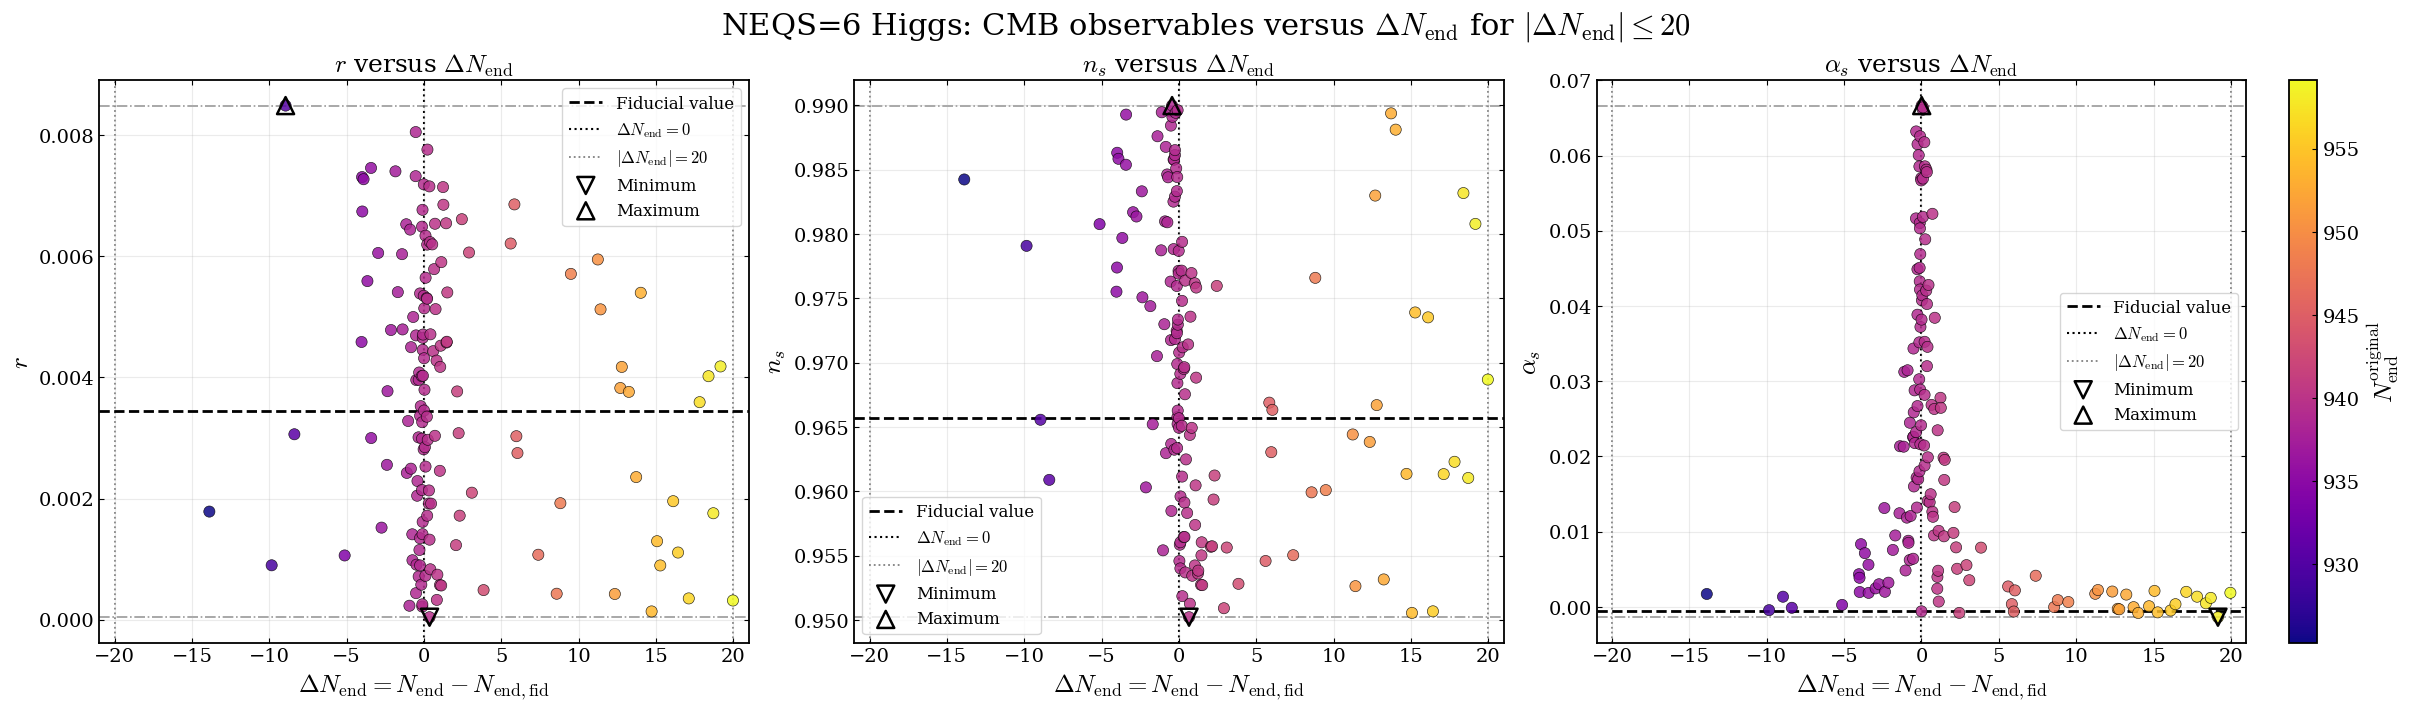


Higgs (NEQS=6): observable ranges for |Delta N| <= 20
Total models in summary     : 560
Finite models               : 560
Models passing Delta N cut  : 148
Models failing Delta N cut  : 412
Models with invalid values  : 0
Fiducial original N_end     : 939.1635722724
Selected Delta N range      : [-13.877807, 19.968086]

------------------------------------------------------------------------------------
Observable: r
Fiducial value : 3.4541891486e-03
Range          : [4.1676252012e-05, 8.4896500978e-03]
Width          : 8.4479738458e-03
Mean           : 3.6499268559e-03
Median         : 3.7661461351e-03
Std. dev.      : 2.2270259535e-03
Minimum at     : Delta N=0.355197
Maximum at     : Delta N=-8.951035
Minimum model  : /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs6_higgs_batch001/lam2_-1.9570650256e-02_lam3_-2.1693655266e-03_lam4_0.0000000000e+00_lam5_0.0000000000e+00
Maximum model  : /Users/epme

In [13]:
# ============================================================
# Observables versus Delta N
#
# Panels:
#   r versus Delta N_end
#   n_s versus Delta N_end
#   alpha_s versus Delta N_end
#
# Uses all accepted models in summary_all, then applies:
#
#       |Delta N_end| <= DELTA_N_MAX
#
# where:
#
#       Delta N_end = N_end - N_end,fiducial
# ============================================================

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
NEQS = 6
model_tag = "higgs"

DELTA_N_MAX = 20.0


# ============================================================
# Main plotting function
# ============================================================
def plot_observables_vs_deltaN(
    summary_all,
    model_tag,
    NEQS,
    max_deltaN=20.0,
    save=True,
    filename=None,
):
    """
    Plot r, n_s, and alpha_s versus Delta N_end for all accepted
    models satisfying:

        |Delta N_end| <= max_deltaN

    where:

        Delta N_end = N_end - N_end,fiducial

    Parameters
    ----------
    summary_all : pandas.DataFrame
        Full summary DataFrame containing all accepted models.

        Required columns:
            original_N_end
            r
            n_s
            alpha_s

        It must also contain the base-parameter column specified
        by MODEL_CONFIG.

    model_tag : str
        Model family key, such as "higgs".

    NEQS : int
        Number of slow-roll flow equations.

    max_deltaN : float, default=20
        Maximum allowed absolute difference in N_end:

            |Delta N_end| <= max_deltaN

    save : bool, default=True
        If True, save the figure as a PDF.

    filename : str or None
        Optional output filename.

    Returns
    -------
    fig : matplotlib.figure.Figure
        Generated figure.

    axes : numpy.ndarray
        Array containing the three plotting axes.

    observable_stats : pandas.DataFrame
        Summary statistics for r, n_s, and alpha_s.

    models_used : pandas.DataFrame
        Cleaned DataFrame containing models that passed the
        Delta N cut.

    rejected_models : pandas.DataFrame
        Cleaned DataFrame containing models that failed the
        Delta N cut.
    """

    # --------------------------------------------------------
    # Basic input checks
    # --------------------------------------------------------
    if max_deltaN < 0:
        raise ValueError(
            "max_deltaN must be nonnegative."
        )

    required_columns = {
        "original_N_end",
        "r",
        "n_s",
        "alpha_s",
    }

    missing_columns = required_columns.difference(
        summary_all.columns
    )

    if missing_columns:
        raise ValueError(
            "summary_all is missing the following columns: "
            f"{sorted(missing_columns)}"
        )

    if model_tag not in MODEL_CONFIG:
        raise ValueError(
            f"Unknown model_tag={model_tag!r}. "
            f"Choose from {list(MODEL_CONFIG)}."
        )

    if NEQS not in MODEL_CONFIG[model_tag]["lam_base"]:
        raise ValueError(
            f"No base-model configuration exists for "
            f"model_tag={model_tag!r}, NEQS={NEQS}."
        )

    # --------------------------------------------------------
    # Find the fiducial/base model
    # --------------------------------------------------------
    base_param_name, base_param_value = (
        MODEL_CONFIG[model_tag]["lam_base"][NEQS]
    )

    if base_param_name not in summary_all.columns:
        raise ValueError(
            f"The base-parameter column {base_param_name!r} "
            "is missing from summary_all."
        )

    base_parameter_values = pd.to_numeric(
        summary_all[base_param_name],
        errors="coerce",
    ).to_numpy(dtype=float)

    base_mask = np.isclose(
        base_parameter_values,
        base_param_value,
        rtol=1e-8,
        atol=max(
            1e-15,
            abs(base_param_value) * 1e-8,
        ),
    )

    if not np.any(base_mask):
        raise ValueError(
            f"Could not locate the fiducial model with "
            f"{base_param_name}={base_param_value:.10e}."
        )

    base_row = summary_all.loc[
        base_mask
    ].iloc[0]

    base_N_end = float(
        base_row["original_N_end"]
    )

    if not np.isfinite(base_N_end):
        raise ValueError(
            f"Fiducial original_N_end is not finite: "
            f"{base_N_end}"
        )

    base_values = {
        "r": float(base_row["r"]),
        "n_s": float(base_row["n_s"]),
        "alpha_s": float(base_row["alpha_s"]),
    }

    for observable_name, value in base_values.items():
        if not np.isfinite(value):
            raise ValueError(
                f"Fiducial {observable_name} is not finite: "
                f"{value}"
            )

    # --------------------------------------------------------
    # Build a working DataFrame
    # --------------------------------------------------------
    models_all = summary_all.copy()

    numeric_columns = [
        "original_N_end",
        "r",
        "n_s",
        "alpha_s",
    ]

    for column in numeric_columns:
        models_all[column] = pd.to_numeric(
            models_all[column],
            errors="coerce",
        )

    # Compute Delta N relative to the fiducial model
    models_all["deltaN_from_base"] = (
        models_all["original_N_end"]
        - base_N_end
    )

    # --------------------------------------------------------
    # Remove rows with nonfinite values
    # --------------------------------------------------------
    finite_columns = [
        "original_N_end",
        "deltaN_from_base",
        "r",
        "n_s",
        "alpha_s",
    ]

    finite_mask = np.ones(
        len(models_all),
        dtype=bool,
    )

    for column in finite_columns:
        finite_mask &= np.isfinite(
            models_all[column].to_numpy(
                dtype=float
            )
        )

    invalid_models = models_all.loc[
        ~finite_mask
    ].copy()

    models_all = models_all.loc[
        finite_mask
    ].copy()

    # --------------------------------------------------------
    # Apply the Delta N classification
    # --------------------------------------------------------
    pass_mask = (
        models_all["deltaN_from_base"].abs()
        <= max_deltaN
    )

    models_used = models_all.loc[
        pass_mask
    ].copy()

    rejected_models = models_all.loc[
        ~pass_mask
    ].copy()

    if models_used.empty:
        raise ValueError(
            f"No finite models satisfy "
            f"|Delta N_end| <= {max_deltaN:g}."
        )

    # Sort from negative to positive Delta N
    models_used = models_used.sort_values(
        "deltaN_from_base"
    ).reset_index(drop=True)

    rejected_models = rejected_models.sort_values(
        "deltaN_from_base"
    ).reset_index(drop=True)

    # --------------------------------------------------------
    # Observable plotting settings
    # --------------------------------------------------------
    observables = [
        {
            "column": "r",
            "label": r"$r$",
            "title": r"$r$ versus $\Delta N_{\rm end}$",
        },
        {
            "column": "n_s",
            "label": r"$n_s$",
            "title": r"$n_s$ versus $\Delta N_{\rm end}$",
        },
        {
            "column": "alpha_s",
            "label": r"$\alpha_s$",
            "title": r"$\alpha_s$ versus $\Delta N_{\rm end}$",
        },
    ]

    # --------------------------------------------------------
    # Compute observable statistics
    # --------------------------------------------------------
    statistics_records = []

    for observable in observables:
        column = observable["column"]

        values = models_used[
            column
        ].to_numpy(dtype=float)

        minimum_position = int(
            np.argmin(values)
        )

        maximum_position = int(
            np.argmax(values)
        )

        minimum_row = models_used.iloc[
            minimum_position
        ]

        maximum_row = models_used.iloc[
            maximum_position
        ]

        record = {
            "observable": column,

            "base_value": base_values[column],

            "minimum": float(
                np.min(values)
            ),

            "maximum": float(
                np.max(values)
            ),

            "range_width": float(
                np.max(values)
                - np.min(values)
            ),

            "mean": float(
                np.mean(values)
            ),

            "median": float(
                np.median(values)
            ),

            "standard_deviation": float(
                np.std(values, ddof=1)
                if len(values) > 1
                else 0.0
            ),

            "deltaN_at_minimum": float(
                minimum_row[
                    "deltaN_from_base"
                ]
            ),

            "deltaN_at_maximum": float(
                maximum_row[
                    "deltaN_from_base"
                ]
            ),

            "N_end_at_minimum": float(
                minimum_row[
                    "original_N_end"
                ]
            ),

            "N_end_at_maximum": float(
                maximum_row[
                    "original_N_end"
                ]
            ),
        }

        if "outdir" in models_used.columns:
            record["outdir_at_minimum"] = (
                minimum_row["outdir"]
            )

            record["outdir_at_maximum"] = (
                maximum_row["outdir"]
            )

        statistics_records.append(
            record
        )

    observable_stats = pd.DataFrame(
        statistics_records
    )

    # --------------------------------------------------------
    # Set up the figure
    # --------------------------------------------------------
    fig, axes = plt.subplots(
        1,
        3,
        figsize=(24, 7),
        constrained_layout=True,
    )

    deltaN_values = models_used[
        "deltaN_from_base"
    ].to_numpy(dtype=float)

    # Color passing models by original N_end
    Nend_values = models_used[
        "original_N_end"
    ].to_numpy(dtype=float)

    Nend_min = np.min(Nend_values)
    Nend_max = np.max(Nend_values)

    if np.isclose(Nend_min, Nend_max):
        Nend_min -= 0.5
        Nend_max += 0.5

    norm = mcolors.Normalize(
        vmin=Nend_min,
        vmax=Nend_max,
    )

    cmap = plt.get_cmap(
        "plasma"
    )

    # --------------------------------------------------------
    # Plot each observable
    # --------------------------------------------------------
    for axis, observable in zip(
        axes,
        observables,
    ):
        column = observable["column"]

        observable_values = models_used[
            column
        ].to_numpy(dtype=float)

        axis.scatter(
            deltaN_values,
            observable_values,
            c=Nend_values,
            cmap=cmap,
            norm=norm,
            s=65,
            alpha=0.85,
            edgecolors="black",
            linewidths=0.45,
            zorder=3,
        )

        # Fiducial observable value
        axis.axhline(
            base_values[column],
            color="black",
            linestyle="--",
            linewidth=2.0,
            label="Fiducial value",
            zorder=2,
        )

        # Fiducial Delta N position
        axis.axvline(
            0.0,
            color="black",
            linestyle=":",
            linewidth=1.5,
            label=r"$\Delta N_{\rm end}=0$",
            zorder=1,
        )

        # Delta N cut boundaries
        axis.axvline(
            -max_deltaN,
            color="gray",
            linestyle=":",
            linewidth=1.3,
            label=rf"$|\Delta N_{{\rm end}}|={max_deltaN:g}$",
            zorder=1,
        )

        axis.axvline(
            max_deltaN,
            color="gray",
            linestyle=":",
            linewidth=1.3,
            zorder=1,
        )

        observable_minimum = np.min(
            observable_values
        )

        observable_maximum = np.max(
            observable_values
        )

        # Horizontal range boundaries
        axis.axhline(
            observable_minimum,
            color="gray",
            linestyle="-.",
            linewidth=1.2,
            alpha=0.8,
            zorder=1,
        )

        axis.axhline(
            observable_maximum,
            color="gray",
            linestyle="-.",
            linewidth=1.2,
            alpha=0.8,
            zorder=1,
        )

        # Locations of extrema
        minimum_index = int(
            np.argmin(observable_values)
        )

        maximum_index = int(
            np.argmax(observable_values)
        )

        axis.scatter(
            deltaN_values[minimum_index],
            observable_values[minimum_index],
            marker="v",
            s=150,
            facecolors="none",
            edgecolors="black",
            linewidths=1.8,
            label="Minimum",
            zorder=5,
        )

        axis.scatter(
            deltaN_values[maximum_index],
            observable_values[maximum_index],
            marker="^",
            s=150,
            facecolors="none",
            edgecolors="black",
            linewidths=1.8,
            label="Maximum",
            zorder=5,
        )

        axis.set_title(
            observable["title"]
        )

        axis.set_xlabel(
            r"$\Delta N_{\rm end}"
            r"=N_{\rm end}-N_{\rm end,fid}$"
        )

        axis.set_ylabel(
            observable["label"]
        )

        axis.set_xlim(
            -1.05 * max_deltaN,
            1.05 * max_deltaN,
        )

        axis.grid(
            True,
            alpha=0.25,
        )

        axis.legend()

    # --------------------------------------------------------
    # Shared color bar
    # --------------------------------------------------------
    scalar_mappable = cm.ScalarMappable(
        cmap=cmap,
        norm=norm,
    )

    scalar_mappable.set_array([])

    colorbar = fig.colorbar(
        scalar_mappable,
        ax=axes.ravel().tolist(),
        pad=0.02,
    )

    colorbar.set_label(
        r"$N_{\rm end}^{\rm original}$"
    )

    colorbar_formatter = ScalarFormatter(
        useOffset=False
    )

    colorbar_formatter.set_scientific(
        False
    )

    colorbar.formatter = (
        colorbar_formatter
    )

    colorbar.update_ticks()

    # --------------------------------------------------------
    # Overall title
    # --------------------------------------------------------
    model_label = MODEL_CONFIG[
        model_tag
    ]["label"]

    fig.suptitle(
        rf"NEQS={NEQS} {model_label}: "
        rf"CMB observables versus $\Delta N_{{\rm end}}$ "
        rf"for $|\Delta N_{{\rm end}}|\leq {max_deltaN:g}$"
    )

    # --------------------------------------------------------
    # Save the figure
    # --------------------------------------------------------
    if filename is None:
        filename = (
            f"paper_{model_tag}_neqs{NEQS}_"
            f"observables_vs_deltaN_abs_le_"
            f"{max_deltaN:g}.pdf"
        )

    if save:
        fig.savefig(
            filename,
            dpi=300,
            bbox_inches="tight",
        )

        print(
            f"Saved figure to:\n{filename}"
        )

    plt.show()

    # --------------------------------------------------------
    # Print classification summary
    # --------------------------------------------------------
    print("\n" + "=" * 84)

    print(
        f"{model_label} (NEQS={NEQS}): "
        f"observable ranges for "
        f"|Delta N| <= {max_deltaN:g}"
    )

    print("=" * 84)

    print(
        f"Total models in summary     : "
        f"{len(summary_all)}"
    )

    print(
        f"Finite models               : "
        f"{len(models_all)}"
    )

    print(
        f"Models passing Delta N cut  : "
        f"{len(models_used)}"
    )

    print(
        f"Models failing Delta N cut  : "
        f"{len(rejected_models)}"
    )

    print(
        f"Models with invalid values  : "
        f"{len(invalid_models)}"
    )

    print(
        f"Fiducial original N_end     : "
        f"{base_N_end:.10f}"
    )

    print(
        f"Selected Delta N range      : "
        f"[{models_used['deltaN_from_base'].min():.6f}, "
        f"{models_used['deltaN_from_base'].max():.6f}]"
    )

    # --------------------------------------------------------
    # Print observable statistics
    # --------------------------------------------------------
    for _, row in observable_stats.iterrows():

        print("\n" + "-" * 84)

        print(
            f"Observable: "
            f"{row['observable']}"
        )

        print(
            f"Fiducial value : "
            f"{row['base_value']:.10e}"
        )

        print(
            f"Range          : "
            f"[{row['minimum']:.10e}, "
            f"{row['maximum']:.10e}]"
        )

        print(
            f"Width          : "
            f"{row['range_width']:.10e}"
        )

        print(
            f"Mean           : "
            f"{row['mean']:.10e}"
        )

        print(
            f"Median         : "
            f"{row['median']:.10e}"
        )

        print(
            f"Std. dev.      : "
            f"{row['standard_deviation']:.10e}"
        )

        print(
            f"Minimum at     : "
            f"Delta N="
            f"{row['deltaN_at_minimum']:.6f}"
        )

        print(
            f"Maximum at     : "
            f"Delta N="
            f"{row['deltaN_at_maximum']:.6f}"
        )

        if "outdir_at_minimum" in row.index:
            print(
                "Minimum model  : "
                f"{row['outdir_at_minimum']}"
            )

            print(
                "Maximum model  : "
                f"{row['outdir_at_maximum']}"
            )

    return (
        fig,
        axes,
        observable_stats,
        models_used,
        rejected_models,
    )


# ============================================================
# Run the function
# ============================================================

(
    fig_obs,
    axes_obs,
    observable_stats,
    observable_models,
    observable_rejected_models,
) = plot_observables_vs_deltaN(
    summary_all=summary_all,
    model_tag=model_tag,
    NEQS=NEQS,
    max_deltaN=DELTA_N_MAX,
    save=True,
)

Above is basically considering the entire range of slow-roll parameters given the models associated difference in $N_{end}$ from the base model. From here I need to think more about properly constraining the expected values. In order to do this properly I will define a parameter in $N$ that should allow me to explore the space for slow-roll parameters that could correspond to valid CMB observables. 


# Accounting for Nuisance Parameter, $\delta N_{piv}$


In addition to applying a general cut for models whose $|\Delta N = N_{end}- N_{end, fiducial}|>20$, we also want to properly account for the effect of higher order parameters. Typically, when we evolve a model we check to determine when $\epsilon = 1$, that is our condition for the end of inflation. Successful models, labeled as nontrivial, will find a place at which the trial of slow-roll parameters end inflation. From that point, our model will trace back  (integrate) $N_init$ e-folds, that is the path trajectory that gets saved. We are going to consider an extra $\Delta N$ when mapping back from the moment inflation end, such that:

$N_{i,model} = N_{end,i} + \delta N$
(Yes, this is plus because it is number of e-folds remaining before the end of inflation)

That $\delta N$ can be chosen to lie within a specific interval that I believe should span a total of approximately 20 e-folds in our case, because remember that is what we are calling to be our range in $N$ that covers the uncertainty in the duration of the evolution. Inclusing this $\delta N$ should account for the uncertainty from truncating the equations. We saw before that, when we accounted for the spread away from $N_{end,base}$ the spread in our power spectra (tensor and scalar on appropriate scales) decreased significantly to below 5 percent when sampled near the fiducial model. We expect that differences in the power spectrum should be neglibible over the range from CMB scales down to interferometer scales, which will be the smallest scales we consider. For this case, we could consider $\delta N$ randomly between $[-10,10]$.

I need to identify a way to allow each model to randomly vary between that particular uncertainty range, $\delta N$. This $\delta N$ is changing specifically where along an accepted model's trajectory we are going to evaluate the CMB observables (shifts the observable evaluation point).

Assuming I have a pivot at say, $N_{piv} = 55$, then for each accepted model I would draw $\delta N \in [-10,10]$. For that pivot, this corresponds to drawing observables between $45 < N_{piv} < 65$. This is good in practice, however, currently the code I have begins at $N_{piv} = 60$, so I could not evaluate the upper part of that interval. I can either:

*a) Extend initial trajectories to at least N=65
b) Use a smaller nuisance interval compatible with saved domain
c) Chose a pivot and interval that has a full range in the trajectories I currently have.*

If I change

    init_Nefolds = 70
    
instead of 

    init_Nefolds = 60
    
That is moving the scale that my code identifies with the largest CMB scale from N=60 to N=70. The code anchors $k_{largest} = 3.2e-4 hMpc^-1$ to the largest $N_{init}$ scale I specify. 

    pick_init_vals() 

assigns sampled values directly at the initial point and these are interpreted as the values (currently) at N=60. If I redefine to N=70, I would be redefining where the supplied initial conditions live.I believe that would generate a genuinely different trajectory. What COULD work, is still sampling the initial state at N=60, but integrating backward to N=70 to keep the full trajectory up to that point given the sampled values at N=60.
    
**This is a very important question to review with Arthur**

For now, I will keep $N=60$ as the nominal physics CMB evaluation point and I can treat $\delta N$ as the uncertainty in where that same observed CMB scale maps onto the inflationary trajectory. I will keep the observed scale fixed at $N=60$ and I can define the N range at which I will evaluate CMB observables as:

$N_{eval} = 60 + \delta N$

Because I want to clarify that point with Arthur, for now it will be just a one-sided test but the infrastructure will be able to hand both. So, below, my goal is to define 

$\delta N \in [-10,0]$ such that $N_{eval} \in [50,60]$.


So, for one model/realization the corresponding $k_{pivot} \rightarrow N=58$ and maybe for another $k_{pivot} \rightarrow N=52$ . The uncertainty lives in the $N_{piv}$.

Now, that I have an idea of my initial one-sided test I want to do for now, I can move on to first just defining $r(N_{eval})$, $n_s(N_{eval})$, $\alpha_s(N_{eval})$. I will do that first and then apply CMB constraints after I am satisfied that for every model I am examining the observables for a wide range of $N$.

Below, for my first test I will examine a pivot of $N=55$ which roughly corresponds to $k_{piv} = 0.05 hMpc^{-1}$.

$\delta N_{piv} \in [-10,5]$ such that $N_{eval} \in [45,60]$


**Summary of what we accounting for:
Why this matters practically: it lets you separate two different sources of uncertainty —
truncation-driven spread in the trajectory itself (the ΔN end cut), and truncation-driven ambiguity in where the CMB scale actually sits on that trajectory (this 𝛿𝑁 piv nuisance parameter).
The second one instead perturbs where along a kept trajectory you read off the observables.**



OBSERVABLE CURVES
Models passing Delta N_end cut : 148
Observable curves produced     : 148
Failed observable calculations : 0
N interval                    : [50, 70]
delta N_piv interval           : [-10, 10]


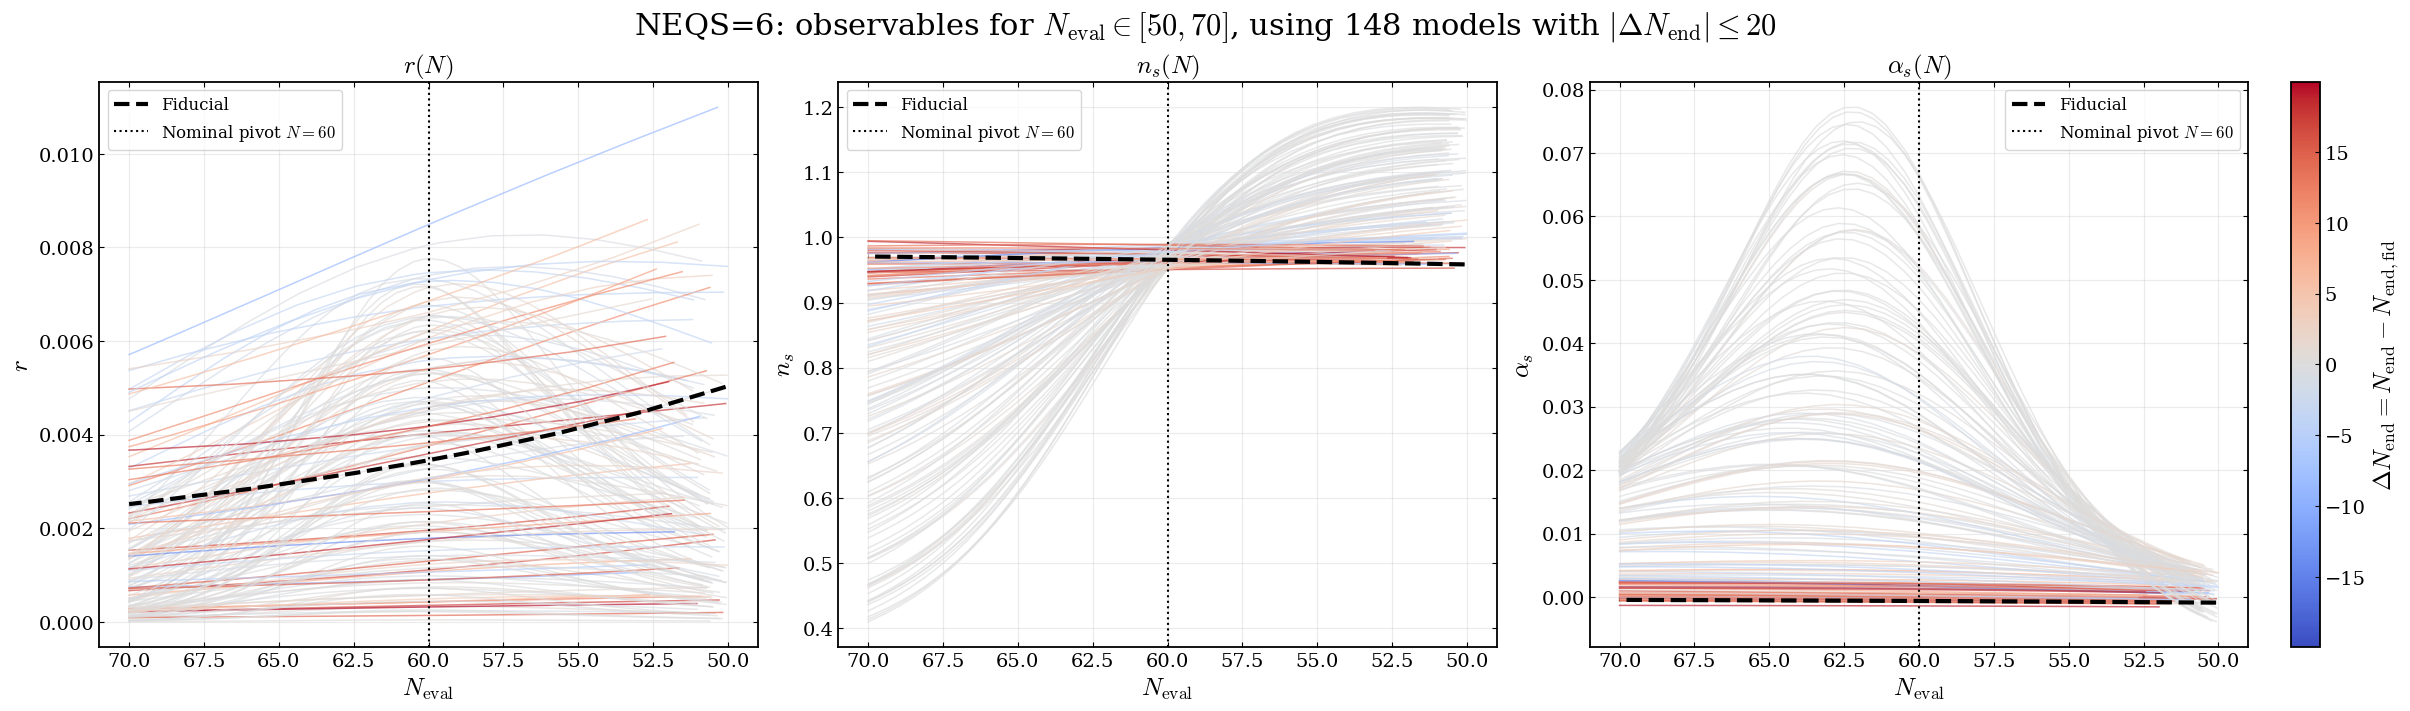

Figure saved to:
paper_higgs_neqs6_observables_N50_to_70_deltaNendmax_20.pdf


In [14]:
# ============================================================
# r(N), n_s(N), and alpha_s(N) for models passing
# |Delta N_end| <= DELTA_N_MAX
#
# First test:
#       45 <= N <= 60
#       -10 <= delta N_piv <= 5
#
# Uses the N points already saved in each path.
# No interpolation.
# No new integration.
# ============================================================


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
NEQS = 6

N_PIVOT_NOMINAL = 60
N_EVAL_MIN = 50.0
N_EVAL_MAX = 70.0

# Constant used in the calcpath observable formulas
c_obs = 0.0814514


# ============================================================
# Observable formulas copied from calcpath.py
# ============================================================
def calc_r(state):
    """
    Tensor-to-scalar ratio from one slow-roll state.
    """
    epsilon = state[2]
    sigma = state[3]

    return (
        16.0
        * epsilon
        * (
            1.0
            - c_obs * (sigma + 2.0 * epsilon)
        )
    )


def calc_ns(state):
    """
    Scalar spectral index from one slow-roll state.
    """
    epsilon = state[2]
    sigma = state[3]
    lambda2 = state[4]

    return (
        1.0
        + sigma
        - (5.0 - 3.0 * c_obs) * epsilon**2
        - 0.25
        * (3.0 - 5.0 * c_obs)
        * epsilon
        * sigma
        + 0.5
        * (3.0 - c_obs)
        * lambda2
    )


def calc_flow_derivatives(state):
    """
    Calculate the flow derivatives needed for alpha_s.

    For NEQS=6, state contains:
        phi, H, epsilon, sigma, lambda2, lambda3
    """
    epsilon = state[2]
    sigma = state[3]
    lambda2 = state[4]
    lambda3 = state[5]

    d_epsilon_dN = (
        epsilon
        * (sigma + 2.0 * epsilon)
    )

    d_sigma_dN = (
        2.0 * lambda2
        - 5.0 * epsilon * sigma
        - 12.0 * epsilon**2
    )

    d_lambda2_dN = (
        0.5 * sigma * lambda2
        + lambda3
    )

    return (
        d_epsilon_dN,
        d_sigma_dN,
        d_lambda2_dN,
    )


def calc_alpha_s(state):
    """
    Running of the scalar spectral index from one slow-roll state.
    """
    epsilon = state[2]
    sigma = state[3]

    (
        d_epsilon_dN,
        d_sigma_dN,
        d_lambda2_dN,
    ) = calc_flow_derivatives(state)

    return -(
        1.0 / (1.0 - epsilon)
    ) * (
        d_sigma_dN

        - 2.0
        * (5.0 - 3.0 * c_obs)
        * epsilon
        * d_epsilon_dN

        - 0.25
        * (3.0 - 5.0 * c_obs)
        * (
            epsilon * d_sigma_dN
            + sigma * d_epsilon_dN
        )

        + 0.5
        * (3.0 - c_obs)
        * d_lambda2_dN
    )


# ============================================================
# Calculate observable curves for one saved model
# ============================================================
def observables_from_saved_path(
    model,
    N_min=N_EVAL_MIN,
    N_max=N_EVAL_MAX,
):
    """
    Load one saved path and calculate r, n_s, and alpha_s
    directly at its saved N values.
    """

    if "path_file" in model:
        path_file = model["path_file"]
        data = np.loadtxt(path_file)

    else:
        data, path_file = load_path_from_outdir(
            model["outdir"],
            NEQS=NEQS,
        )

    data = np.asarray(
        data,
        dtype=float,
    )

    # First NEQS columns are the flow states.
    states = data[:, :NEQS]
    #states 0-6 are col, phi, H, eps, sig, lam2, lam3

    # Column NEQS is N.
    N_values = data[:, NEQS]

    # Keep finite rows inside the uncertainty interval.
    keep = (
        np.isfinite(N_values)
        & np.all(np.isfinite(states), axis=1)
        & (N_values >= N_min)
        & (N_values <= N_max)
    )

    N_values = N_values[keep]
    states = states[keep]

    if len(N_values) < 2:
        raise ValueError(
            f"Not enough saved points between "
            f"N={N_min:g} and N={N_max:g}: "
            f"{path_file}"
        )

    
    # Check that the saved N coordinate is monotonic
    dN = np.diff(N_values)

    if np.all(dN >= 0):
        # N is already increasing
        pass

    elif np.all(dN <= 0):
        # N is decreasing, so reverse N and the corresponding states
        N_values = N_values[::-1]
        states = states[::-1]

    else:
        raise ValueError(
            f"N is non-monotonic in path: {path_file}"
        )

    

    N_values = N_values
    states = states

    r_values = np.asarray(
        [calc_r(state) for state in states],
        dtype=float,
    )

    ns_values = np.asarray(
        [calc_ns(state) for state in states],
        dtype=float,
    )

    alpha_values = np.asarray(
        [calc_alpha_s(state) for state in states],
        dtype=float,
    )

    finite_observables = (
        np.isfinite(r_values)
        & np.isfinite(ns_values)
        & np.isfinite(alpha_values)
    )

    N_values = N_values[finite_observables]
    r_values = r_values[finite_observables]
    ns_values = ns_values[finite_observables]
    alpha_values = alpha_values[finite_observables]

    if len(N_values) < 2:
        raise ValueError(
            f"Not enough finite observable values: "
            f"{path_file}"
        )

    return {
        "N": N_values,

        "deltaN_piv": (
            N_values - N_PIVOT_NOMINAL
        ),

        "r": r_values,
        "n_s": ns_values,
        "alpha_s": alpha_values,

        "path_file": path_file,
        "outdir": model.get("outdir"),

        "original_N_end": float(
            model["original_N_end"]
        ),

        "deltaN_from_base": float(
            model["deltaN_from_base"]
        ),
    }


# ============================================================
# Process every model passing the Delta N_end cut
# ============================================================
observable_curves = []
observable_failures = []

#enurmerate gives position index and model
#model index for all my passed models
for model_index, model in enumerate(
    passed_models #dictionary of accepted models
):
    try: #will call func for one model
        curves = observables_from_saved_path(
            model
        )

        curves["model_index"] = model_index

        observable_curves.append(
            curves
        )

    except (
        FileNotFoundError,
        ValueError,
        KeyError,
        TypeError,
    ) as exc:
        observable_failures.append({
            "model_index": model_index,
            "outdir": model.get("outdir"),
            "error": str(exc),
        })


print("\n" + "=" * 70)
print("OBSERVABLE CURVES")
print("=" * 70)

print(
    f"Models passing Delta N_end cut : "
    f"{len(passed_models)}"
)

print(
    f"Observable curves produced     : "
    f"{len(observable_curves)}"
)

print(
    f"Failed observable calculations : "
    f"{len(observable_failures)}"
)

print(
    f"N interval                    : "
    f"[{N_EVAL_MIN:g}, {N_EVAL_MAX:g}]"
)

print(
    f"delta N_piv interval           : "
    f"[{N_EVAL_MIN - N_PIVOT_NOMINAL:g}, "
    f"{N_EVAL_MAX - N_PIVOT_NOMINAL:g}]"
)

print("=" * 70)


if observable_failures:
    print("\nFirst failures:")

    for failure in observable_failures[:10]:
        print(
            f"  model {failure['model_index']}: "
            f"{failure['error']}"
        )


if not observable_curves:
    raise RuntimeError(
        "No observable curves were produced."
    )


# ============================================================
# Fiducial model
# ============================================================
base_model = {
    "outdir": base_row["outdir"],
    "original_N_end": base_N_end,
    "deltaN_from_base": 0.0,
}

base_observables = observables_from_saved_path(
    base_model
)


# ============================================================
# Color the models by Delta N_end
# ============================================================
#Get all end vals make an array
deltaN_end_values = np.asarray(
    [
        curves["deltaN_from_base"]
        for curves in observable_curves
    ],
    dtype=float,
)

#what is largest deltaN?
max_abs_deltaN = np.max(
    np.abs(deltaN_end_values)
)

#if max is zero then make max 1, edge case scenario
if np.isclose(max_abs_deltaN, 0.0):
    max_abs_deltaN = 1.0

norm = mcolors.TwoSlopeNorm(
    vmin=-max_abs_deltaN,
    vcenter=0.0,
    vmax=max_abs_deltaN,
)

cmap = plt.get_cmap(
    "coolwarm"
)


# ============================================================
# Plot
# ============================================================
fig, axes = plt.subplots(
    1,
    3,
    figsize=(24, 7),
    constrained_layout=True,
)

ax_r, ax_ns, ax_alpha = axes


# Plot every accepted model
for curves in observable_curves:
    color = cmap(
        norm(curves["deltaN_from_base"])
    )

    ax_r.plot(
        curves["N"],
        curves["r"],
        color=color,
        lw=1.1,
        alpha=0.65,
    )

    ax_ns.plot(
        curves["N"],
        curves["n_s"],
        color=color,
        lw=1.1,
        alpha=0.65,
    )

    ax_alpha.plot(
        curves["N"],
        curves["alpha_s"],
        color=color,
        lw=1.1,
        alpha=0.65,
    )


# Fiducial model
fiducial_style = {
    "color": "black",
    "lw": 3.0,
    "ls": "--",
    "label": "Fiducial",
    "zorder": 5,
}

ax_r.plot(
    base_observables["N"],
    base_observables["r"],
    **fiducial_style,
)

ax_ns.plot(
    base_observables["N"],
    base_observables["n_s"],
    **fiducial_style,
)

ax_alpha.plot(
    base_observables["N"],
    base_observables["alpha_s"],
    **fiducial_style,
)


# Labels and styling
ax_r.set_title(
    r"$r(N)$"
)

ax_ns.set_title(
    r"$n_s(N)$"
)

ax_alpha.set_title(
    r"$\alpha_s(N)$"
)

ax_r.set_ylabel(
    r"$r$"
)

ax_ns.set_ylabel(
    r"$n_s$"
)

ax_alpha.set_ylabel(
    r"$\alpha_s$"
)


for axis in axes:
    axis.set_xlabel(
        r"$N_{\rm eval}$"
    )

    axis.axvline(
        N_PIVOT_NOMINAL,
        color="black",
        ls=":",
        lw=1.5,
        label=rf"Nominal pivot $N={N_PIVOT_NOMINAL:g}$",
    )

    axis.grid(
        True,
        alpha=0.25,
    )

    # Show N=60 first and N=50 later.
    axis.invert_xaxis()

    axis.legend(
        loc="best"
    )


# Shared colorbar
scalar_mappable = cm.ScalarMappable(
    norm=norm,
    cmap=cmap,
)

scalar_mappable.set_array([])

colorbar = fig.colorbar(
    scalar_mappable,
    ax=axes.ravel().tolist(),
    pad=0.02,
)

colorbar.set_label(
    r"$\Delta N_{\rm end}"
    r"=N_{\rm end}-N_{\rm end,fid}$"
)


fig.suptitle(
    rf"NEQS={NEQS}: observables for "
    rf"$N_{{\rm eval}}\in[{N_EVAL_MIN:g},{N_EVAL_MAX:g}]$, "
    rf"using {len(observable_curves)} models with "
    rf"$|\Delta N_{{\rm end}}|\leq{DELTA_N_MAX:g}$"
)


output_name = (
    f"paper_higgs_neqs{NEQS}_"
    f"observables_N{N_EVAL_MIN:g}_to_{N_EVAL_MAX:g}_"
    f"deltaNendmax_{DELTA_N_MAX:g}.pdf"
)

fig.savefig(
    output_name,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    f"Figure saved to:\n{output_name}"
)

# CMB Consistent Models Across $\delta N_{piv}$

The observables most relevant to CMB scales are: $r(N_{eval})$, $n_s(N_{eval})$, $\alpha_s(N_{eval})$. The expectation is that at a particular pivot scale (a pivot corresponding to CMB scales) we can measure these observables and we expect them to be in some range that can be probed by experiments/detectors. Our $\delta N$ should account for uncertainty in truncation. A model can be considered to pass if all three conditions are true together. It probably should not pass if $r$ passes at $N=52$, $n_s$ passes at $N=57$, and $\alpha_s$ passes at $N=59$. They should all pass at $N=52$ or ALL pass at $N=59$.

I may even be able to get several passing observables values at a multiple N values for a model. I think. We are probing here if the model is compatible with the data for some allowed truncation-induced shift.
**Right now, I am going to use general assumed values for CMB passing at the standard pivot scale $k_{piv} = 0.05 hMpc^{-1}$, we should double check these.** I make it so that all three of them must be true.

I am looking at $r(N)$, $n_s(N)$, $\alpha_s(N)$ in the $N_{eval}$ interval $\in [45,60]$ and seeing which of those are within CMB limits. Basically, is there a single $N_eval$ where the model is simultaneously consistent with observables. That shiuld follow because $\delta N$ represents one uncertain pivot location per realization, not three independent ones.


A limitation worth mentioning If two adjacent saved points are far apart in N and the true observable curve dips into the allowed window between them, this method would miss it and mark the model as failing. Is my N resolution fine (dense enough)? Something to consider.




In [86]:
# # Exploratory CMB observable limits

# #Values at k=0.05
# # Tensor-to-scalar ratio:
# # P-ACT-LB-BK18 95% upper limit
# R_MIN_CMB = 0.0
# R_MAX_CMB = 0.038

# # Loose exploratory scalar-index range
# NS_MIN_CMB = 0.96
# NS_MAX_CMB = 0.99

# # ACT DR6 + Planck + lensing/BAO:
# # alpha_s = 0.0062 +/- 0.0052 at 68%
# ALPHA_CENTER_CMB = 0.0062
# ALPHA_ERROR_CMB = 0.0052

# # ALPHA_MIN_CMB = (
# #     ALPHA_CENTER_CMB
# #     - ALPHA_ERROR_CMB
# # )

# # ALPHA_MAX_CMB = (
# #     ALPHA_CENTER_CMB
# #     + ALPHA_ERROR_CMB
# # )


# ALPHA_SIGMA_LEVEL = 2.0

# ALPHA_MIN_CMB = (
#     ALPHA_CENTER_CMB
#     - ALPHA_SIGMA_LEVEL * ALPHA_ERROR_CMB
# )

# ALPHA_MAX_CMB = (
#     ALPHA_CENTER_CMB
#     + ALPHA_SIGMA_LEVEL * ALPHA_ERROR_CMB
# )


In [55]:
#Fiducial Specific Expectations
##0.001 gives 3sigma measurement of amp

# R_TARGET = 2.737e-03 #0.00335
# R_DELTA = 0.002

# R_MIN_CMB = R_TARGET - R_DELTA
# R_MAX_CMB = R_TARGET + R_DELTA


# ALPHA_MIN_CMB = -0.005
# ALPHA_MAX_CMB = 0.005 


# ============================================================
# Fiducial CMB expectations
# evaluated at nominal N_piv = 60
# ============================================================

R_FID = 3.4541891486e-03
NS_FID = 9.6567801085e-01
ALPHA_FID = -5.9646914604e-04


# Assumed 2-sigma tolerances
R_DELTA_2SIGMA = 0.002
NS_DELTA_2SIGMA = 0.0055
ALPHA_DELTA_2SIGMA = 0.005


R_MIN_CMB = R_FID - R_DELTA_2SIGMA
R_MAX_CMB = R_FID + R_DELTA_2SIGMA

NS_MIN_CMB = NS_FID - NS_DELTA_2SIGMA
NS_MAX_CMB = NS_FID + NS_DELTA_2SIGMA

ALPHA_MIN_CMB = ALPHA_FID - ALPHA_DELTA_2SIGMA
ALPHA_MAX_CMB = ALPHA_FID + ALPHA_DELTA_2SIGMA

In [58]:
# ============================================================
# Identify CMB-compatible N values for every model
# ============================================================

cmb_passing_models = []
cmb_failing_models = []

for curves in observable_curves:

    r_pass = (
        (curves["r"] >= R_MIN_CMB)
        & (curves["r"] <= R_MAX_CMB)
    )

    ns_pass = (
        (curves["n_s"] >= NS_MIN_CMB)
        & (curves["n_s"] <= NS_MAX_CMB)
    )

    alpha_pass = (
        (curves["alpha_s"] >= ALPHA_MIN_CMB)
        & (curves["alpha_s"] <= ALPHA_MAX_CMB)
    )

    # All three observables must pass at the same N.
    cmb_pass_mask = (
        r_pass
        & ns_pass
        & alpha_pass
    )

    # Save the mask inside the model dictionary.
    curves["r_pass_mask"] = r_pass
    curves["ns_pass_mask"] = ns_pass
    curves["alpha_pass_mask"] = alpha_pass
    curves["cmb_pass_mask"] = cmb_pass_mask

    # A model passes if at least one saved N point works.
    #We define that below, creating a new key and assigning a value
    #Given also that curves is a reference to one specific dictioning (same one in observable curves)
    #it keeps trck of these values model by model i.i one dict per model
    #now every single dict has been enriched with these new keys
    curves["passes_cmb_somewhere"] = bool(
        np.any(cmb_pass_mask)
    )

    if curves["passes_cmb_somewhere"]:

        passing_N = curves["N"][
            cmb_pass_mask
        ]

        passing_deltaN_piv = curves[
            "deltaN_piv"
        ][cmb_pass_mask]

        curves["N_pass_min"] = float(
            np.min(passing_N)
        )

        curves["N_pass_max"] = float(
            np.max(passing_N)
        )

        curves["deltaN_piv_pass_min"] = float(
            np.min(passing_deltaN_piv)
        )

        curves["deltaN_piv_pass_max"] = float(
            np.max(passing_deltaN_piv)
        )

        curves["number_of_passing_points"] = int(
            np.sum(cmb_pass_mask)
        )

        curves["fraction_of_saved_points_passing"] = float(
            np.mean(cmb_pass_mask)
        )

        cmb_passing_models.append(
            curves
        )

    else: #if it doesnt pass it it set to nan and 0 and appended
        curves["N_pass_min"] = np.nan
        curves["N_pass_max"] = np.nan

        curves["deltaN_piv_pass_min"] = np.nan
        curves["deltaN_piv_pass_max"] = np.nan

        curves["number_of_passing_points"] = 0
        curves["fraction_of_saved_points_passing"] = 0.0

        cmb_failing_models.append(
            curves
        )
        
        

In [59]:
print("\n" + "=" * 72)
print("CMB COMPATIBILITY OVER THE NUISANCE INTERVAL")
print("=" * 72)

print(
    f"Models entering CMB test       : "
    f"{len(observable_curves)}"
)

print(
    f"Models passing at some N       : "
    f"{len(cmb_passing_models)}"
) 

print(
    f"Models passing at no saved N   : "
    f"{len(cmb_failing_models)}"
)

print(
    f"r interval                     : "
    f"[{R_MIN_CMB:g}, {R_MAX_CMB:g}]"
)

print(
    f"n_s interval                   : "
    f"[{NS_MIN_CMB:g}, {NS_MAX_CMB:g}]"
)

print(
    f"alpha_s interval               : "
    f"[{ALPHA_MIN_CMB:g}, "
    f"{ALPHA_MAX_CMB:g}]"
)

print("=" * 72)

for curves in cmb_passing_models[:20]:
    print(
        f"model={curves['model_index']:4d} | "
        f"N pass=["
        f"{curves['N_pass_min']:.4f}, "
        f"{curves['N_pass_max']:.4f}] | "
        f"deltaN_piv pass=["
        f"{curves['deltaN_piv_pass_min']:.4f}, "
        f"{curves['deltaN_piv_pass_max']:.4f}] | "
        f"points={curves['number_of_passing_points']}"
    )


CMB COMPATIBILITY OVER THE NUISANCE INTERVAL
Models entering CMB test       : 148
Models passing at some N       : 22
Models passing at no saved N   : 126
r interval                     : [0.00145419, 0.00545419]
n_s interval                   : [0.960178, 0.971178]
alpha_s interval               : [-0.00559647, 0.00440353]
model=   0 | N pass=[52.7948, 70.0000] | deltaN_piv pass=[-7.2052, 10.0000] | points=17
model=   7 | N pass=[68.1962, 70.0000] | deltaN_piv pass=[8.1962, 10.0000] | points=2
model=   9 | N pass=[59.6173, 62.4414] | deltaN_piv pass=[-0.3827, 2.4414] | points=12
model=  11 | N pass=[57.2654, 60.0195] | deltaN_piv pass=[-2.7346, 0.0195] | points=10
model=  21 | N pass=[56.3418, 56.3418] | deltaN_piv pass=[-3.6582, -3.6582] | points=1
model=  25 | N pass=[62.4414, 65.3434] | deltaN_piv pass=[2.4414, 5.3434] | points=2
model=  43 | N pass=[57.8687, 70.0000] | deltaN_piv pass=[-2.1313, 10.0000] | points=15
model=  46 | N pass=[50.7269, 53.4870] | deltaN_piv pass=[-9.2731

I am reading this as, given a model 0 for instance, the saved trajectory path that passes all three CMB  observable cuts are in between N=52 and 70, outside of that, observables does not pass. The $\delta N$ for that associated model at 52.7948 is shifted from the **nominal** model by about -7.2052 e-folds and it contains 17 saved N-location that satisfy all three cuts simultaneously (points).


In [18]:
model0 = cmb_passing_models[0]

mask = model0["cmb_pass_mask"]

print("Passing N values:")
print(model0["N"][mask])

print("\nPassing deltaN_piv values:")
print(model0["deltaN_piv"][mask])

print("\nr values:")
print(model0["r"][mask])

print("\nn_s values:")
print(model0["n_s"][mask])

print("\nalpha_s values:")
print(model0["alpha_s"][mask])

#This is a good check to see if they are contiguous 



Passing N values:
[52.794833 55.653255 58.662731 60.       60.000001 60.000006 60.000031
 60.000156 60.000781 60.003906 60.019531 60.097656 60.488281 62.441406
 65.875271 69.309137 70.      ]

Passing deltaN_piv values:
[-7.20516700e+00 -4.34674500e+00 -1.33726900e+00  0.00000000e+00
  9.99999997e-07  6.00000000e-06  3.10000000e-05  1.56000000e-04
  7.81000000e-04  3.90600000e-03  1.95310000e-02  9.76560000e-02
  4.88281000e-01  2.44140600e+00  5.87527100e+00  9.30913700e+00
  1.00000000e+01]

r values:
[0.00450009 0.00403457 0.00361859 0.00345419 0.00345419 0.00345419
 0.00345419 0.00345417 0.0034541  0.00345372 0.00345187 0.00344263
 0.00339696 0.00318173 0.0028501  0.00256786 0.00251617]

n_s values:
[0.96077754 0.9628763  0.96486163 0.96567801 0.96567801 0.96567802
 0.96567803 0.96567811 0.96567848 0.96568034 0.96568966 0.96573615
 0.96596674 0.96707432 0.96885282 0.97044097 0.97073974]

alpha_s values:
[-0.0007744  -0.00069633 -0.00062506 -0.00059647 -0.00059647 -0.00059647
 -0.00

To highlight the passing portions on my existing curves, I build on the same logic as before.
It should build an array the same length as N, and replace failing points with Nan. 


OBSERVABLE CURVES
Models passing Delta N_end cut : 148
Observable curves produced     : 148
Failed observable calculations : 0
N interval                    : [50, 70]
delta N_piv interval           : [-10, 10]

CMB COMPATIBILITY OVER THE NUISANCE INTERVAL
Models entering CMB test       : 148
Models passing at some N       : 23
Models passing at no saved N   : 125
r interval                     : [0.000737, 0.004737]
n_s interval                   : [0.96, 0.971]
alpha_s interval               : [-0.005, 0.005]
model=   0 | N pass=[52.7948, 70.0000] | deltaN_piv pass=[-7.2052, 10.0000] | points=17
model=   7 | N pass=[68.1962, 70.0000] | deltaN_piv pass=[8.1962, 10.0000] | points=2
model=   9 | N pass=[59.6173, 62.4414] | deltaN_piv pass=[-0.3827, 2.4414] | points=12
model=  10 | N pass=[60.0000, 60.0195] | deltaN_piv pass=[0.0000, 0.0195] | points=8
model=  13 | N pass=[58.3589, 58.3589] | deltaN_piv pass=[-1.6411, -1.6411] | points=1
model=  21 | N pass=[56.3418, 56.3418] | deltaN_p

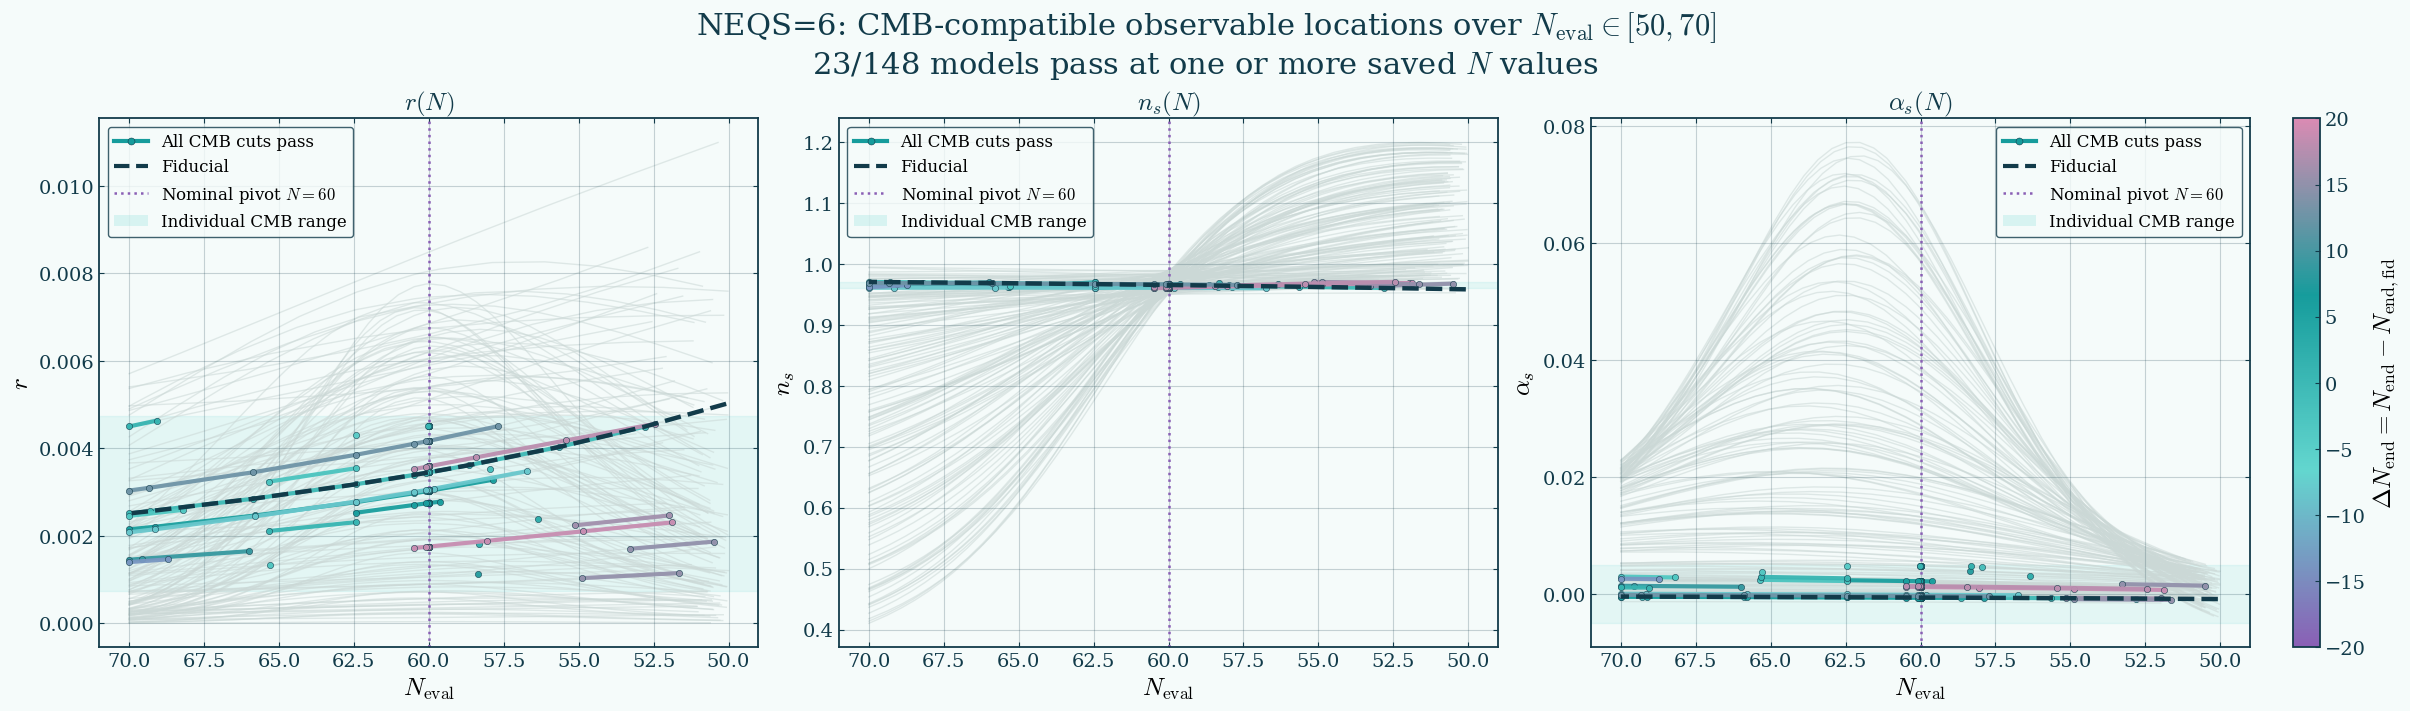

Figure saved to:
paper_higgs_neqs6_cmb_compatible_observables_N50_to_70_deltaNendmax_20.pdf

CMB model summary:
   model_index                                             outdir  \
0            0  /Users/epmeador/Desktop/research/rwarthur/infl...   
1            1  /Users/epmeador/Desktop/research/rwarthur/infl...   
2            2  /Users/epmeador/Desktop/research/rwarthur/infl...   
3            3  /Users/epmeador/Desktop/research/rwarthur/infl...   
4            4  /Users/epmeador/Desktop/research/rwarthur/infl...   

   deltaN_from_base  passes_cmb_somewhere  N_pass_min  N_pass_max  \
0          0.000000                  True   52.794833        70.0   
1          5.600459                 False         NaN         NaN   
2         -3.659740                 False         NaN         NaN   
3          0.828181                 False         NaN         NaN   
4          0.355197                 False         NaN         NaN   

   deltaN_piv_pass_min  deltaN_piv_pass_max  number_of_pas

In [19]:
# ============================================================
# r(N), n_s(N), and alpha_s(N) for models passing
# |Delta N_end| <= DELTA_N_MAX
#
# One-sided nuisance interval:
#       50 <= N_eval <= 60
#       -10 <= delta N_piv <= 0
#
# A model is CMB-compatible if there is at least one saved N
# where r, n_s, and alpha_s all pass simultaneously.
#
# Uses saved path points directly:
#       no interpolation
#       no new integration

from matplotlib.patches import Patch


# ============================================================
# Calculate observable curves for one saved model
# ============================================================
def observables_from_saved_path(
    model,
    N_min=N_EVAL_MIN,
    N_max=N_EVAL_MAX,
):
    """
    Load one saved trajectory and calculate r, n_s, and alpha_s
    directly at its saved N values.

    No interpolation is performed.
    """

    if "path_file" in model:
        path_file = model["path_file"]
        data = np.loadtxt(path_file)

    elif "outdir" in model:
        data, path_file = load_path_from_outdir(
            model["outdir"],
            NEQS=NEQS,
        )

    else:
        raise KeyError(
            "Model contains neither 'path_file' nor 'outdir'."
        )

    data = np.asarray(
        data,
        dtype=float,
    )

    if data.ndim != 2:
        raise ValueError(
            f"Path data must be two-dimensional: {path_file}"
        )

    if data.shape[1] < NEQS + 1:
        raise ValueError(
            f"Path has {data.shape[1]} columns, but at least "
            f"{NEQS + 1} are required: {path_file}"
        )

    # First NEQS columns contain:
    # phi, H, epsilon, sigma, lambda2, lambda3
    states = data[:, :NEQS]

    # Column NEQS contains N
    N_values = data[:, NEQS]

    # Keep only finite states inside the nuisance interval
    keep = (
        np.isfinite(N_values)
        & np.all(
            np.isfinite(states),
            axis=1,
        )
        & (N_values >= N_min)
        & (N_values <= N_max)
    )

    N_values = N_values[keep]
    states = states[keep]

    if len(N_values) < 2:
        raise ValueError(
            f"Not enough saved points between "
            f"N={N_min:g} and N={N_max:g}: "
            f"{path_file}"
        )

    # --------------------------------------------------------
    # Verify that N is monotonic
    # --------------------------------------------------------
    dN = np.diff(N_values)

    if np.all(dN >= 0):
        # Already increasing
        pass

    elif np.all(dN <= 0):
        # Decreasing, so reverse both N and the corresponding states
        N_values = N_values[::-1]
        states = states[::-1]

    else:
        raise ValueError(
            f"N is non-monotonic in path: {path_file}"
        )

    # Duplicate N values are harmless for plotting, but print
    # a warning because they may matter for later interpolation.
    if np.any(np.diff(N_values) == 0):
        print(
            f"WARNING: duplicate N values found in: "
            f"{path_file}"
        )

    # --------------------------------------------------------
    # Calculate observables at every saved state
    # --------------------------------------------------------
    r_values = np.asarray(
        [
            calc_r(state)
            for state in states
        ],
        dtype=float,
    )

    ns_values = np.asarray(
        [
            calc_ns(state)
            for state in states
        ],
        dtype=float,
    )

    alpha_values = np.asarray(
        [
            calc_alpha_s(state)
            for state in states
        ],
        dtype=float,
    )

    finite_observables = (
        np.isfinite(r_values)
        & np.isfinite(ns_values)
        & np.isfinite(alpha_values)
    )

    N_values = N_values[finite_observables]
    r_values = r_values[finite_observables]
    ns_values = ns_values[finite_observables]
    alpha_values = alpha_values[finite_observables]

    if len(N_values) < 2:
        raise ValueError(
            f"Not enough finite observable values: "
            f"{path_file}"
        )

    return {
        "N": N_values,

        "deltaN_piv": (
            N_values
            - N_PIVOT_NOMINAL
        ),

        "r": r_values,
        "n_s": ns_values,
        "alpha_s": alpha_values,

        "path_file": path_file,
        "outdir": model.get(
            "outdir"
        ),

        "original_N_end": float(
            model["original_N_end"]
        ),

        "deltaN_from_base": float(
            model["deltaN_from_base"]
        ),
    }


# ============================================================
# Process every model passing the Delta N_end cut
# ============================================================
observable_curves = []
observable_failures = []

for model_index, model in enumerate(
    passed_models
):
    try:
        curves = observables_from_saved_path(
            model
        )

        curves["model_index"] = model_index

        observable_curves.append(
            curves
        )

    except (
        FileNotFoundError,
        ValueError,
        KeyError,
        TypeError,
    ) as exc:

        observable_failures.append({
            "model_index": model_index,
            "outdir": model.get(
                "outdir"
            ),
            "error": str(exc),
        })


print("\n" + "=" * 72)
print("OBSERVABLE CURVES")
print("=" * 72)

print(
    f"Models passing Delta N_end cut : "
    f"{len(passed_models)}"
)

print(
    f"Observable curves produced     : "
    f"{len(observable_curves)}"
)

print(
    f"Failed observable calculations : "
    f"{len(observable_failures)}"
)

print(
    f"N interval                    : "
    f"[{N_EVAL_MIN:g}, {N_EVAL_MAX:g}]"
)

print(
    f"delta N_piv interval           : "
    f"[{N_EVAL_MIN - N_PIVOT_NOMINAL:g}, "
    f"{N_EVAL_MAX - N_PIVOT_NOMINAL:g}]"
)

print("=" * 72)


if observable_failures:
    print("\nFirst failures:")

    for failure in observable_failures[:10]:
        print(
            f"  model {failure['model_index']}: "
            f"{failure['error']}"
        )


if not observable_curves:
    raise RuntimeError(
        "No observable curves were produced."
    )


# ============================================================
# Identify CMB-compatible N locations
# ============================================================
cmb_passing_models = []
cmb_failing_models = []

for curves in observable_curves:

    # Individual observable masks
    r_pass_mask = (
        (curves["r"] >= R_MIN_CMB)
        & (curves["r"] <= R_MAX_CMB)
    )

    ns_pass_mask = (
        (curves["n_s"] >= NS_MIN_CMB)
        & (curves["n_s"] <= NS_MAX_CMB)
    )

    alpha_pass_mask = (
        (curves["alpha_s"] >= ALPHA_MIN_CMB)
        & (curves["alpha_s"] <= ALPHA_MAX_CMB)
    )

    # All observables must pass at the same saved N point
    cmb_pass_mask = (
        r_pass_mask
        & ns_pass_mask
        & alpha_pass_mask
    )

    # Store all masks in the model dictionary
    curves["r_pass_mask"] = r_pass_mask
    curves["ns_pass_mask"] = ns_pass_mask
    curves["alpha_pass_mask"] = alpha_pass_mask
    curves["cmb_pass_mask"] = cmb_pass_mask

    curves["passes_cmb_somewhere"] = bool(
        np.any(cmb_pass_mask)
    )

    if curves["passes_cmb_somewhere"]:

        passing_N = curves["N"][
            cmb_pass_mask
        ]

        passing_deltaN_piv = curves[
            "deltaN_piv"
        ][cmb_pass_mask]

        curves["N_pass_min"] = float(
            np.min(passing_N)
        )

        curves["N_pass_max"] = float(
            np.max(passing_N)
        )

        curves["deltaN_piv_pass_min"] = float(
            np.min(passing_deltaN_piv)
        )

        curves["deltaN_piv_pass_max"] = float(
            np.max(passing_deltaN_piv)
        )

        curves["number_of_passing_points"] = int(
            np.sum(cmb_pass_mask)
        )

        curves["fraction_of_saved_points_passing"] = float(
            np.mean(cmb_pass_mask)
        )

        cmb_passing_models.append(
            curves
        )

    else:
        curves["N_pass_min"] = np.nan
        curves["N_pass_max"] = np.nan

        curves["deltaN_piv_pass_min"] = np.nan
        curves["deltaN_piv_pass_max"] = np.nan

        curves["number_of_passing_points"] = 0
        curves["fraction_of_saved_points_passing"] = 0.0

        cmb_failing_models.append(
            curves
        )


# ============================================================
# CMB compatibility summary
# ============================================================
print("\n" + "=" * 72)
print("CMB COMPATIBILITY OVER THE NUISANCE INTERVAL")
print("=" * 72)

print(
    f"Models entering CMB test       : "
    f"{len(observable_curves)}"
)

print(
    f"Models passing at some N       : "
    f"{len(cmb_passing_models)}"
)

print(
    f"Models passing at no saved N   : "
    f"{len(cmb_failing_models)}"
)

print(
    f"r interval                     : "
    f"[{R_MIN_CMB:g}, {R_MAX_CMB:g}]"
)

print(
    f"n_s interval                   : "
    f"[{NS_MIN_CMB:g}, {NS_MAX_CMB:g}]"
)

print(
    f"alpha_s interval               : "
    f"[{ALPHA_MIN_CMB:g}, "
    f"{ALPHA_MAX_CMB:g}]"
)

print("=" * 72)


# Print the first 20 passing models
for curves in cmb_passing_models[:20]:

    print(
        f"model={curves['model_index']:4d} | "
        f"N pass=["
        f"{curves['N_pass_min']:.4f}, "
        f"{curves['N_pass_max']:.4f}] | "
        f"deltaN_piv pass=["
        f"{curves['deltaN_piv_pass_min']:.4f}, "
        f"{curves['deltaN_piv_pass_max']:.4f}] | "
        f"points={curves['number_of_passing_points']}"
    )


# ============================================================
# Fiducial model
# ============================================================
base_model = {
    "outdir": base_row["outdir"],
    "original_N_end": base_N_end,
    "deltaN_from_base": 0.0,
}

base_observables = observables_from_saved_path(
    base_model
)

#This part is for the plotting scheme
# ============================================================
# Mermaid-themed plot colors
# ============================================================
mermaid_dark = "#123B4A"
mermaid_teal = "#169C9C"
mermaid_aqua = "#63D6CF"
mermaid_purple = "#8A5FB5"
mermaid_pink = "#D98BB3"
mermaid_sand = "#E8DCC4"
mermaid_gray = "#CBD8D6"
mermaid_background = "#F5FBFA"

# The color of each passing trajectory still represents
# Delta N_end relative to the fiducial model.
#LinearSegmentedColormap.from_list: 
#creates a custom, smoothly-varying color map from a list of colors
cmap = mcolors.LinearSegmentedColormap.from_list(
    "mermaid",
    [
        mermaid_purple,
        mermaid_aqua,
        mermaid_teal,
        mermaid_pink,
    ],
)

# Fixed limits make the color meaning consistent between plots
norm = mcolors.TwoSlopeNorm(
    vmin=-DELTA_N_MAX,
    vcenter=0.0,
    vmax=DELTA_N_MAX,
)


# ============================================================
# Plot
# ============================================================
fig, axes = plt.subplots(
    1,
    3,
    figsize=(24, 7),
    constrained_layout=True,
)

ax_r, ax_ns, ax_alpha = axes

#patch.set_facecolor() is a Matplotlib method used to change the background fill color of a 2D artist object
fig.patch.set_facecolor(
    mermaid_background
)

for axis in axes:
    axis.set_facecolor(
        mermaid_background
    )


# ------------------------------------------------------------
# Individual CMB allowed bands
# ------------------------------------------------------------
ax_r.axhspan(
    R_MIN_CMB,
    R_MAX_CMB,
    color=mermaid_aqua,
    alpha=0.12,
    zorder=0,
)

ax_ns.axhspan(
    NS_MIN_CMB,
    NS_MAX_CMB,
    color=mermaid_aqua,
    alpha=0.12,
    zorder=0,
)

ax_alpha.axhspan(
    ALPHA_MIN_CMB,
    ALPHA_MAX_CMB,
    color=mermaid_aqua,
    alpha=0.12,
    zorder=0,
)


# ------------------------------------------------------------
# Plot every complete trajectory faintly
# ------------------------------------------------------------
for curves in observable_curves:

    ax_r.plot(
        curves["N"],
        curves["r"],
        color=mermaid_gray,
        lw=1.0,
        alpha=0.55,
        zorder=1,
    )

    ax_ns.plot(
        curves["N"],
        curves["n_s"],
        color=mermaid_gray,
        lw=1.0,
        alpha=0.55,
        zorder=1,
    )

    ax_alpha.plot(
        curves["N"],
        curves["alpha_s"],
        color=mermaid_gray,
        lw=1.0,
        alpha=0.55,
        zorder=1,
    )


# ------------------------------------------------------------
# Highlight saved N locations where all cuts pass together
# ------------------------------------------------------------
for curves in cmb_passing_models:

    pass_mask = curves["cmb_pass_mask"]

    color = cmap(
        norm(
            curves["deltaN_from_base"]
        )
    )

    # Failing locations become NaN.
    # Matplotlib only draws passing portions.
    r_passing = np.where(
        pass_mask,
        curves["r"],
        np.nan,
    )

    ns_passing = np.where(
        pass_mask,
        curves["n_s"],
        np.nan,
    )

    alpha_passing = np.where(
        pass_mask,
        curves["alpha_s"],
        np.nan,
    )

    ax_r.plot(
        curves["N"],
        r_passing,
        color=color,
        lw=3.0,
        marker="o",
        markersize=4.5,
        markeredgecolor=mermaid_dark,
        markeredgewidth=0.4,
        alpha=0.95,
        zorder=3,
    )

    ax_ns.plot(
        curves["N"],
        ns_passing,
        color=color,
        lw=3.0,
        marker="o",
        markersize=4.5,
        markeredgecolor=mermaid_dark,
        markeredgewidth=0.4,
        alpha=0.95,
        zorder=3,
    )

    ax_alpha.plot(
        curves["N"],
        alpha_passing,
        color=color,
        lw=3.0,
        marker="o",
        markersize=4.5,
        markeredgecolor=mermaid_dark,
        markeredgewidth=0.4,
        alpha=0.95,
        zorder=3,
    )


# ------------------------------------------------------------
# Fiducial model
# ------------------------------------------------------------
fiducial_style = {
    "color": mermaid_dark,
    "lw": 3.2,
    "ls": "--",
    "zorder": 5,
}

ax_r.plot(
    base_observables["N"],
    base_observables["r"],
    **fiducial_style,
)

ax_ns.plot(
    base_observables["N"],
    base_observables["n_s"],
    **fiducial_style,
)

ax_alpha.plot(
    base_observables["N"],
    base_observables["alpha_s"],
    **fiducial_style,
)


# ============================================================
# Titles and axis labels
# ============================================================
ax_r.set_title(
    r"$r(N)$",
    color=mermaid_dark,
)

ax_ns.set_title(
    r"$n_s(N)$",
    color=mermaid_dark,
)

ax_alpha.set_title(
    r"$\alpha_s(N)$",
    color=mermaid_dark,
)

ax_r.set_ylabel(
    r"$r$"
)

ax_ns.set_ylabel(
    r"$n_s$"
)

ax_alpha.set_ylabel(
    r"$\alpha_s$"
)


# ============================================================
# Custom legend
# ============================================================
passing_handle = Line2D(
    [0],
    [0],
    color=mermaid_teal,
    lw=3.0,
    marker="o",
    markersize=5,
    markeredgecolor=mermaid_dark,
    markeredgewidth=0.4,
    label="All CMB cuts pass",
)

fiducial_handle = Line2D(
    [0],
    [0],
    color=mermaid_dark,
    lw=3.0,
    ls="--",
    label="Fiducial",
)

pivot_handle = Line2D(
    [0],
    [0],
    color=mermaid_purple,
    lw=1.8,
    ls=":",
    label=rf"Nominal pivot $N={N_PIVOT_NOMINAL:g}$",
)

cmb_band_handle = Patch(
    facecolor=mermaid_aqua,
    alpha=0.20,
    label="Individual CMB range",
)


# ============================================================
# Shared axis styling
# ============================================================
for axis in axes:

    axis.set_xlabel(
        r"$N_{\rm eval}$"
    )

    axis.axvline(
        N_PIVOT_NOMINAL,
        color=mermaid_purple,
        ls=":",
        lw=1.8,
        zorder=2,
    )

    axis.grid(
        True,
        alpha=0.22,
        color=mermaid_dark,
    )

    # N decreases toward the end of inflation.
    # Display N=60 on the left and N=50 on the right.
    axis.invert_xaxis()

    axis.tick_params(
        colors=mermaid_dark
    )

    for spine in axis.spines.values():
        spine.set_color(
            mermaid_dark
        )

    axis.legend(
        handles=[
            passing_handle,
            fiducial_handle,
            pivot_handle,
            cmb_band_handle,
        ],
        loc="best",
        frameon=True,
        facecolor=mermaid_background,
        edgecolor=mermaid_dark,
    )


# ============================================================
# Shared Delta N_end colorbar
# ============================================================
scalar_mappable = cm.ScalarMappable(
    norm=norm,
    cmap=cmap,
)

scalar_mappable.set_array([])

colorbar = fig.colorbar(
    scalar_mappable,
    ax=axes.ravel().tolist(),
    pad=0.02,
)

colorbar.set_label(
    r"$\Delta N_{\rm end}"
    r"=N_{\rm end}-N_{\rm end,fid}$"
)

colorbar.ax.tick_params(
    colors=mermaid_dark
)

colorbar.outline.set_edgecolor(
    mermaid_dark
)


# ============================================================
# Figure title and output
# ============================================================
fig.suptitle(
    rf"NEQS={NEQS}: CMB-compatible observable locations over "
    rf"$N_{{\rm eval}}\in[{N_EVAL_MIN:g},{N_EVAL_MAX:g}]$"
    "\n"
    rf"{len(cmb_passing_models)}/{len(observable_curves)} models "
    rf"pass at one or more saved $N$ values",
    color=mermaid_dark,
)


output_name = (
    f"paper_higgs_neqs{NEQS}_"
    f"cmb_compatible_observables_"
    f"N{N_EVAL_MIN:g}_to_{N_EVAL_MAX:g}_"
    f"deltaNendmax_{DELTA_N_MAX:g}.pdf"
)

fig.savefig(
    output_name,
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor(),
)

plt.show()

print(
    f"Figure saved to:\n{output_name}"
)


# ============================================================
# Build a model-level CMB summary DataFrame
# ============================================================
cmb_summary_records = []

for curves in observable_curves:

    cmb_summary_records.append({
        "model_index": curves["model_index"],

        "outdir": curves["outdir"],

        "deltaN_from_base": (
            curves["deltaN_from_base"]
        ),

        "passes_cmb_somewhere": (
            curves["passes_cmb_somewhere"]
        ),

        "N_pass_min": curves["N_pass_min"],
        "N_pass_max": curves["N_pass_max"],

        "deltaN_piv_pass_min": (
            curves["deltaN_piv_pass_min"]
        ),

        "deltaN_piv_pass_max": (
            curves["deltaN_piv_pass_max"]
        ),

        "number_of_passing_points": (
            curves["number_of_passing_points"]
        ),

        "fraction_of_saved_points_passing": (
            curves[
                "fraction_of_saved_points_passing"
            ]
        ),
    })


cmb_model_summary = pd.DataFrame(
    cmb_summary_records
)

print("\nCMB model summary:")
print(
    cmb_model_summary.head()
)


# Optional: display only models that pass somewhere
cmb_passing_summary = cmb_model_summary.loc[
    cmb_model_summary[
        "passes_cmb_somewhere"
    ]
].copy()

print(
    f"\nPassing model rows: "
    f"{len(cmb_passing_summary)}"
)


It seems as though there is an interval in which every model that satisfies the |\Delta N| < 20 cut, has some nuisance/uncertainty accounting shift that put $n_s$ into the broad 0.96-0.99 range. Typically, the limits on $r$ and $\alpha_s$ are already being met. It is the current $\delta N_{piv} \in [-10,5]$ that moves its scalar spectral index into the assumed CMB compatible range for a particular range of N.

Additionally, reasoning behind the choice of $N=55$ comes from the fact that $N=60$ maps to $k_{piv}=3.2e-4 h Mpc^{-1}$. Initially, I rang this with $N=60$ as the nominal evaluation location. But my observational bounds are quoted at $k_{piv} = 0.05 hMpc^{-1}$, which is more so around $N=55$.

In [20]:
print("\nConstraint diagnostics for first 20 models")
print("=" * 90)


#lopps over first 20 model dic
for curves in observable_curves[:20]:

    print(
        f"model={curves['model_index']:3d} | "
        f"total={len(curves['N']):2d} | " #total number of saved points in nuisance window
        f"r pass={np.sum(curves['r_pass_mask']):2d} | " #how many saved N points satisfy the r bound alone, regardless of the other two observables.
        f"ns pass={np.sum(curves['ns_pass_mask']):2d} | "
        f"alpha pass={np.sum(curves['alpha_pass_mask']):2d} | "
        f"all pass={np.sum(curves['cmb_pass_mask']):2d}"
    )


Constraint diagnostics for first 20 models
model=  0 | total=18 | r pass=17 | ns pass=17 | alpha pass=18 | all pass=17
model=  1 | total=18 | r pass= 2 | ns pass= 2 | alpha pass=18 | all pass= 0
model=  2 | total=22 | r pass= 4 | ns pass= 1 | alpha pass= 3 | all pass= 0
model=  3 | total=34 | r pass= 0 | ns pass= 9 | alpha pass= 1 | all pass= 0
model=  4 | total=39 | r pass= 0 | ns pass= 1 | alpha pass= 2 | all pass= 0
model=  5 | total=29 | r pass=29 | ns pass= 1 | alpha pass= 1 | all pass= 0
model=  6 | total=24 | r pass= 6 | ns pass=11 | alpha pass= 2 | all pass= 0
model=  7 | total=18 | r pass=18 | ns pass= 2 | alpha pass=18 | all pass= 2
model=  8 | total=36 | r pass=27 | ns pass= 0 | alpha pass= 1 | all pass= 0
model=  9 | total=18 | r pass=18 | ns pass=12 | alpha pass=18 | all pass=12
model= 10 | total=20 | r pass=15 | ns pass= 9 | alpha pass=16 | all pass= 8
model= 11 | total=19 | r pass= 6 | ns pass=10 | alpha pass=19 | all pass= 0
model= 12 | total=28 | r pass=20 | ns pass= 

In [21]:
model = observable_curves[0]

diagnostic = pd.DataFrame({
    "N": model["N"],
    "r": model["r"],
    "r_pass": model["r_pass_mask"],
    "n_s": model["n_s"],
    "ns_pass": model["ns_pass_mask"],
    "alpha_s": model["alpha_s"],
    "alpha_pass": model["alpha_pass_mask"],
    "all_pass": model["cmb_pass_mask"],
})

print(diagnostic)

            N         r  r_pass       n_s  ns_pass   alpha_s  alpha_pass  \
0   50.079689  0.005021   False  0.958562    False -0.000860        True   
1   52.794833  0.004500    True  0.960778     True -0.000774        True   
2   55.653255  0.004035    True  0.962876     True -0.000696        True   
3   58.662731  0.003619    True  0.964862     True -0.000625        True   
4   60.000000  0.003454    True  0.965678     True -0.000596        True   
5   60.000001  0.003454    True  0.965678     True -0.000596        True   
6   60.000006  0.003454    True  0.965678     True -0.000596        True   
7   60.000031  0.003454    True  0.965678     True -0.000596        True   
8   60.000156  0.003454    True  0.965678     True -0.000596        True   
9   60.000781  0.003454    True  0.965678     True -0.000596        True   
10  60.003906  0.003454    True  0.965680     True -0.000596        True   
11  60.019531  0.003452    True  0.965690     True -0.000596        True   
12  60.09765

The next step here is to identify the passing $\delta N$ range for each model. Specifically, I want to identify for a given model's CMB passing range, what is the minimum $\delta N_{piv}$ and the maximum? Also, is it continuous in that range? I will call these for each model: $\delta N_{min}$ and $\delta N_{max}$ and track if it is continuous in that N interval and I will save it to a dataframe so i can call it later.

In [22]:
# ============================================================
# Simple pass/fail and continuity summary for every model
# ============================================================

print("\n" + "=" * 90)
print("MODEL CMB PASSING SUMMARY")
print("=" * 90)

for curves in observable_curves:

    model_index = curves["model_index"]
    pass_mask = curves["cmb_pass_mask"]

    passing_N = curves["N"][pass_mask]
    passing_deltaN = curves["deltaN_piv"][pass_mask]

    passing_indices = np.where(pass_mask)[0] #gives me the position where compound cut passes

    # --------------------------------------------------------
    # Case 1: model does not pass anywhere
    # --------------------------------------------------------
    if len(passing_indices) == 0:
        curves["is_continuous"] = False

        print(
            f"model={model_index:4d} | "
            f"PASS=False | "
            f"no allowed N values"
        )

        continue

    # --------------------------------------------------------
    # Case 2: model passes at one or more saved N values
    # --------------------------------------------------------
    is_continuous = bool(
        np.all(
            np.diff(passing_indices) == 1
        )
    ) #np. diff gives me gaps between consecutive passsing positions
    #if every gap is 1, every passing point is immediatley followed by another passing point, aka no hole
    curves["is_continuous"] = is_continuous 

    N_min = float(np.min(passing_N))
    N_max = float(np.max(passing_N))

    deltaN_min = float(np.min(passing_deltaN))
    deltaN_max = float(np.max(passing_deltaN))
    

    print(
        f"model={model_index:4d} | "
        f"PASS=True | "
        f"N=[{N_min:.4f}, {N_max:.4f}] | "
        f"deltaN_piv=[{deltaN_min:.4f}, {deltaN_max:.4f}] | "
        f"points={len(passing_N):2d} | "
        f"continuous={is_continuous}"
    )

print("=" * 90)




# ============================================================
# Prepare endpoint DataFrame for spectrum calculations
# ============================================================

deltaN_ranges_df = cmb_model_summary.rename(
    columns={
        "deltaN_piv_pass_min": "deltaN_min",
        "deltaN_piv_pass_max": "deltaN_max",
    }
).copy()

deltaN_ranges_df = deltaN_ranges_df.loc[
    deltaN_ranges_df["passes_cmb_somewhere"]
].copy()

deltaN_ranges_df = deltaN_ranges_df.reset_index(
    drop=True
)

continuity_lookup = {
    curves["model_index"]: curves["is_continuous"]
    for curves in observable_curves
}

deltaN_ranges_df["is_continuous"] = deltaN_ranges_df["model_index"].map(continuity_lookup)


print(
    deltaN_ranges_df[
        [
            "model_index",
            "deltaN_min",
            "deltaN_max",
            "is_continuous",
            "outdir",
        ]
    ].head()
)


MODEL CMB PASSING SUMMARY
model=   0 | PASS=True | N=[52.7948, 70.0000] | deltaN_piv=[-7.2052, 10.0000] | points=17 | continuous=True
model=   1 | PASS=False | no allowed N values
model=   2 | PASS=False | no allowed N values
model=   3 | PASS=False | no allowed N values
model=   4 | PASS=False | no allowed N values
model=   5 | PASS=False | no allowed N values
model=   6 | PASS=False | no allowed N values
model=   7 | PASS=True | N=[68.1962, 70.0000] | deltaN_piv=[8.1962, 10.0000] | points= 2 | continuous=True
model=   8 | PASS=False | no allowed N values
model=   9 | PASS=True | N=[59.6173, 62.4414] | deltaN_piv=[-0.3827, 2.4414] | points=12 | continuous=True
model=  10 | PASS=True | N=[60.0000, 60.0195] | deltaN_piv=[0.0000, 0.0195] | points= 8 | continuous=True
model=  11 | PASS=False | no allowed N values
model=  12 | PASS=False | no allowed N values
model=  13 | PASS=True | N=[58.3589, 58.3589] | deltaN_piv=[-1.6411, -1.6411] | points= 1 | continuous=True
model=  14 | PASS=False

This is similar to the previous diagnostic table but now I am checking to see if the passing saved points form an uninterupted black within that tested interval N. We do mean, continuous across the saved trajectory points. Again, $\delta N_{piv}$ is distance from that model's N=55 point.

# Identify Passing Spectra and $\Omega_{GW,\delta N_{min}}$ and $\Omega_{GW,\delta N_{max}}$ for One Model

First, we can try this for one model.

In [23]:
#The line below uses whatever is currently held as a variable in the botejook memory, not necessarily zero,
#when model_index = model_index, so i explicitly am choosing the index 0 to test 
row = deltaN_ranges_df.loc[
    deltaN_ranges_df["model_index"] == 0
].iloc[0]

deltaN_min = row["deltaN_min"]
print(deltaN_min)
deltaN_max = row["deltaN_max"]

spec_t = np.loadtxt(
    os.path.join(
        row["outdir"],
        f"spec_t_neqs{NEQS}.dat",
    )
)

k_t, Pt = prepare_increasing(
    spec_t[:, 0],
    np.abs(spec_t[:, 1]),
)

k_nominal = k_t

k_deltaN_min = (
    k_t * np.exp(-deltaN_min)
)

k_deltaN_max = (
    k_t * np.exp(-deltaN_max)
)



-7.205167000000003


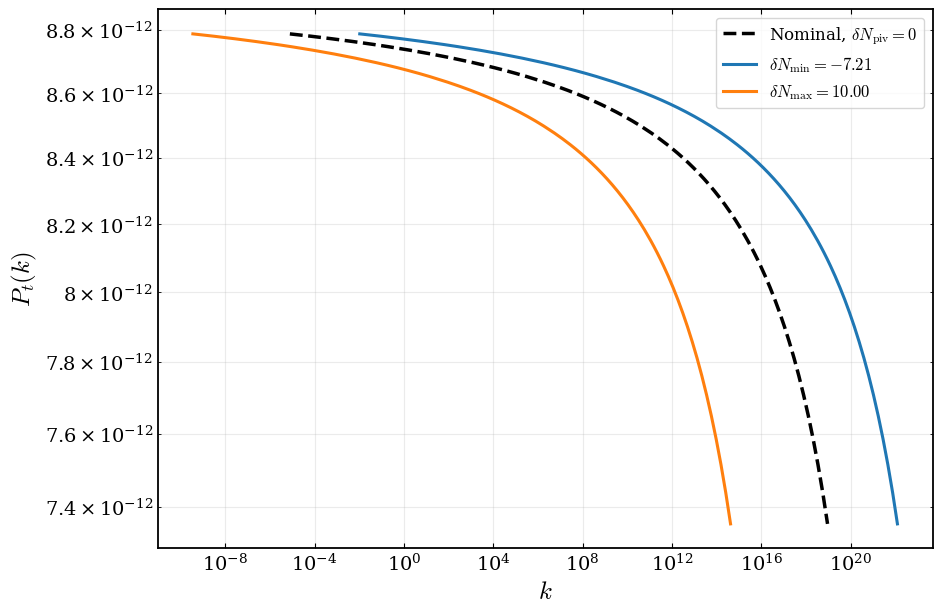

In [24]:
plt.figure(figsize=(10, 7))

plt.loglog(
    k_nominal,
    Pt,
    color="black",
    ls="--",
    lw=2.5,
    label=rf"Nominal, $\delta N_{{\rm piv}}=0$",
)

plt.loglog(
    k_deltaN_min,
    Pt,
    lw=2.2,
    label=rf"$\delta N_{{\min}}={deltaN_min:.2f}$",
)

plt.loglog(
    k_deltaN_max,
    Pt,
    lw=2.2,
    label=rf"$\delta N_{{\max}}={deltaN_max:.2f}$",
)

plt.xlabel(r"$k$")
plt.ylabel(r"$P_t(k)$")
plt.grid(True, which="both", alpha=0.25)
plt.legend()
plt.show()

# print(
#     deltaN_ranges_df.loc[
#         deltaN_ranges_df["model_index"] == 0
#     ][["model_index", "outdir", "deltaN_min", "deltaN_max"]]
# )



To then apply transfer function for this one model:

In [25]:
# ============================================================
# Omega_GW for one model:
# deltaN_min, nominal deltaN=0, and deltaN_max
# ============================================================

## Take CMB passing deltaNpiv range and show what tensor spec implies for OmegaGW at nominal and min and max 


def plot_one_model_omegaGW(
    model_index,
    deltaN_ranges_df,
    tf_k_invMpc,
    tf_median,
    NEQS=6,
    h=0.67,
    save_name=None,
    show=True,
):
    """
    Horizontally shift one model's tensor spectrum using:

        k_shifted = k * exp(-deltaN_piv)

    Then calculate:

        OmegaGW_h2 = T(k_shifted) * Pt
        OmegaGW    = OmegaGW_h2 / h**2

    Curves shown:
        deltaN_min
        nominal deltaN = 0
        deltaN_max
    """

    # --------------------------------------------------------
    # Helper: preserve the original physical k-P pairing
    # --------------------------------------------------------
    def ensure_increasing_k(k, P, name):
        k = np.asarray(k, dtype=float)
        P = np.asarray(P, dtype=float)

        if len(k) != len(P):
            raise ValueError(
                f"{name}: k and data arrays have different lengths."
            )

        if len(k) < 2:
            raise ValueError(
                f"{name}: fewer than two valid data points."
            )

        dk = np.diff(k)

        if np.all(dk > 0):
            # Already increasing: leave untouched
            return k, P

        if np.all(dk < 0):
            # Decreasing: reverse both arrays together
            print(f"{name}: reversing strictly decreasing k array.")
            return k[::-1], P[::-1]

        raise ValueError(
            f"{name}: k is not monotonic. "
            "The data were not sorted automatically."
        )

    # --------------------------------------------------------
    # 1. Get this model's nuisance boundaries assuming requested model exists 
    # --------------------------------------------------------
    matches = deltaN_ranges_df.loc[
        deltaN_ranges_df["model_index"] == model_index
    ]

    if matches.empty:
        raise ValueError(
            f"No entry found for model_index={model_index}."
        )

    row = matches.iloc[0]

    if not bool(row["passes_cmb_somewhere"]):
        print(
            f"Model {model_index} has no CMB-compatible N range."
        )
        return None

    deltaN_min = float(row["deltaN_min"])
    deltaN_max = float(row["deltaN_max"])
    outdir = row["outdir"]

    print("\n" + "=" * 60)
    print(f"Model {model_index}")
    print(f"deltaN_min     = {deltaN_min:.6f}")
    print(f"deltaN_nominal = {0.0:.6f}")
    print(f"deltaN_max     = {deltaN_max:.6f}")
    print("=" * 60)

    # --------------------------------------------------------
    # 2. Load tensor spectrum
    # --------------------------------------------------------
    tensor_file = os.path.join(
        outdir,
        f"spec_t_neqs{NEQS}.dat",
    )

    tensor_data = np.loadtxt(tensor_file)

    k_raw = np.asarray(
        tensor_data[:, 0],
        dtype=float,
    )
    k_raw = k_raw * h   # convert h/Mpc -> Mpc^-1, to match tf_k_invMpc's units

    Pt_raw = np.abs(
        np.asarray(
            tensor_data[:, 1],
            dtype=float,
        )
    )

    good_tensor = (
        np.isfinite(k_raw)
        & np.isfinite(Pt_raw)
        & (k_raw > 0)
        & (Pt_raw > 0)
    )

    k_raw = k_raw[good_tensor]
    Pt_raw = Pt_raw[good_tensor]

    #make sure its monotonic
    k_raw, Pt_raw = ensure_increasing_k(
        k_raw,
        Pt_raw,
        name=f"Model {model_index} tensor spectrum",
    )

    
    # --------------------------------------------------------
    # 3. Prepare transfer function
    # --------------------------------------------------------
    tf_k = np.asarray(
        tf_k_invMpc,
        dtype=float,
    )

    tf_T = np.asarray(
        tf_median,
        dtype=float,
    )

    good_tf = (
        np.isfinite(tf_k)
        & np.isfinite(tf_T)
        & (tf_k > 0)
        & (tf_T > 0)
    )

    tf_k = tf_k[good_tf]
    tf_T = tf_T[good_tf]

    tf_k, tf_T = ensure_increasing_k(
        tf_k,
        tf_T,
        name="Transfer function",
    )

    #load and interp transfer func
    # Linear interpolation in log(k)-log(T)
    logT_interp = interp1d(
        np.log(tf_k),
        np.log(tf_T),
        kind="linear",
        bounds_error=False,
        fill_value=np.nan,
    )

    #min and max defined as transfer func range
    kmin_tf = tf_k[0]
    kmax_tf = tf_k[-1]

    # --------------------------------------------------------
    # 4. Shift spectrum and apply transfer function
    # --------------------------------------------------------
    def calculate_shifted_omega(deltaN):
        #define appropriate k shift
        k_shifted = k_raw * np.exp(-deltaN)

        #only get k shifted within tomain of transfer func, 
        #cannot evaluate T where you have no data for it
        overlap = (
            (k_shifted >= kmin_tf)
            & (k_shifted <= kmax_tf)
        )

        k_use = k_shifted[overlap]
        Pt_use = Pt_raw[overlap]

        #make sure theres enough pts
        if len(k_use) < 5:
            raise ValueError(
                f"deltaN={deltaN:.4f}: only {len(k_use)} points "
                "overlap the transfer-function range."
            )
        #evaluates T at k_use
        T_use = np.exp(
            logT_interp(
                np.log(k_use)
            )
        )

        valid = (
            np.isfinite(T_use)
            & (T_use > 0)
        )

        k_use = k_use[valid]
        Pt_use = Pt_use[valid]
        T_use = T_use[valid]

        if len(k_use) < 5:
            raise ValueError(
                f"deltaN={deltaN:.4f}: fewer than five valid "
                "transferred points remain."
            )
        #make sure it is valid
        #T use is basically Transfer function at a given k 
        #Then omega is T evaluated at specific k multiplied by power spectrum that is raw.
        #This is where my issue lives. For nominal sure, not a biggie but spectra should be shifted 
        #and should evaluate nominal spectra at a shifted k....
        #tensor spec file gives me (k,Pt) pairs, when i include deltaNpiv shift, physics at trajectory pt is unchanged
        #but corresponds to diff wavenumber.
        #Nothing about deltaN changes the physics or the trajectory. given this trajectory, what kind of model 
        #corresponds to CMB pivot scale
        
        
        
        
        OmegaGW_h2 = T_use * Pt_use
        OmegaGW = OmegaGW_h2 / h**2

        print(
            f"deltaN={deltaN:8.4f} | "
            f"shift={np.exp(-deltaN):.4e} | "
            f"points={len(k_use)}"
        )

        return k_use, OmegaGW_h2, OmegaGW

    # Lower boundary
    k_min, omega_h2_min, omega_min = (
        calculate_shifted_omega(deltaN_min)
    )

    # Nominal model
    k_nom, omega_h2_nom, omega_nom = (
        calculate_shifted_omega(0.0)
    )

    # Upper boundary
    k_max, omega_h2_max, omega_max = (
        calculate_shifted_omega(deltaN_max)
    )

    # --------------------------------------------------------
    # 5. Plot
    # --------------------------------------------------------
    
    
    # original transfer function
    plt.figure(figsize=(10, 7))

    plt.loglog(
        tf_k,
        tf_T,
        lw=2,
        label="Original transfer function"
    )


    # transfer function sampled at the nominal tensor k grid
    T_nom = np.exp(
        logT_interp(np.log(k_nom))
    )

    plt.scatter(
        k_nom,
        T_nom,
        s=30,
        label="T(k) sampled at spectrum k"
    )

    plt.xlabel(r"$k\ [{\rm Mpc}^{-1}]$")
    plt.ylabel(r"$T(k)$")
    plt.legend()
    plt.grid(True, which="both", alpha=0.25)
    plt.show()


        
    plt.figure(figsize=(10, 7))

    plt.scatter(
        k_nom,
        omega_h2_nom,
        s=35,
    )

    plt.xscale("log")
    plt.yscale("log")

    plt.xlabel(r"$k\ [{\rm Mpc}^{-1}]$")
    plt.ylabel(r"$\Omega_{\rm GW}h^2$")
    plt.grid(True, which="both", alpha=0.25)
    plt.show()

        
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(16, 6),
        constrained_layout=True,
    )

    ax_h2, ax_plain = axes

    # OmegaGW h^2
    ax_h2.loglog(
        k_min,
        omega_h2_min,
        lw=2.0,
        label=rf"$\delta N_{{\min}}={deltaN_min:.2f}$",
    )

    ax_h2.loglog(
        k_nom,
        omega_h2_nom,
        color="black",
        lw=2.5,
        linestyle=":",
        label=r"Nominal, $\delta N_{\rm piv}=0$",
    )

    ax_h2.loglog(
        k_max,
        omega_h2_max,
        lw=2.0,
        linestyle="--",
        label=rf"$\delta N_{{\max}}={deltaN_max:.2f}$",
    )

    # OmegaGW
    ax_plain.loglog(
        k_min,
        omega_min,
        lw=2.0,
        label=rf"$\delta N_{{\min}}={deltaN_min:.2f}$",
    )

    ax_plain.loglog(
        k_nom,
        omega_nom,
        color="black",
        lw=2.5,
        linestyle=":",
        label=r"Nominal, $\delta N_{\rm piv}=0$",
    )

    ax_plain.loglog(
        k_max,
        omega_max,
        lw=2.0,
        linestyle="--",
        label=rf"$\delta N_{{\max}}={deltaN_max:.2f}$",
    )

    ax_h2.set_title(
        r"$\Omega_{\rm GW}h^2$"
    )

    ax_plain.set_title(
        r"$\Omega_{\rm GW}$"
    )

    ax_h2.set_ylabel(
        r"$\Omega_{\rm GW}h^2(k)$"
    )

    ax_plain.set_ylabel(
        r"$\Omega_{\rm GW}(k)$"
    )

    for ax in axes:
#         ax.set_xlabel(
#             r"$k_{\rm shifted}\ [{\rm Mpc}^{-1}]$"
#         )
        ax.set_xlabel(
    r"$k(\delta N_{\rm piv})\ [{\rm Mpc}^{-1}]$"
        )

        ax.grid(
            True,
            which="major",
            alpha=0.25,
        )

        ax.grid(
            True,
            which="minor",
            alpha=0.12,
        )

        ax.minorticks_on()
        ax.legend(
            frameon=False,
            loc="best",
        )

    fig.suptitle(
        rf"Model {model_index}: transferred tensor spectrum"
    )

    if save_name is None:
        save_name = (
            f"model_{model_index}_"
            "omegaGW_nominal_and_boundaries.png"
        )

    fig.savefig(
        save_name,
        dpi=300,
        bbox_inches="tight",
    )

    if show:
        plt.show()
    else:
        plt.close(fig)

    print(f"\nSaved figure: {save_name}")

    return {
        "model_index": model_index,
        "deltaN_min": deltaN_min,
        "deltaN_max": deltaN_max,

        "k_deltaN_min": k_min,
        "OmegaGW_h2_deltaN_min": omega_h2_min,
        "OmegaGW_deltaN_min": omega_min,

        "k_nominal": k_nom,
        "OmegaGW_h2_nominal": omega_h2_nom,
        "OmegaGW_nominal": omega_nom,

        "k_deltaN_max": k_max,
        "OmegaGW_h2_deltaN_max": omega_h2_max,
        "OmegaGW_deltaN_max": omega_max,
    }




Model 0
deltaN_min     = -7.205167
deltaN_nominal = 0.000000
deltaN_max     = 10.000000
deltaN= -7.2052 | shift=1.3464e+03 | points=92
deltaN=  0.0000 | shift=1.0000e+00 | points=101
deltaN= 10.0000 | shift=4.5400e-05 | points=57


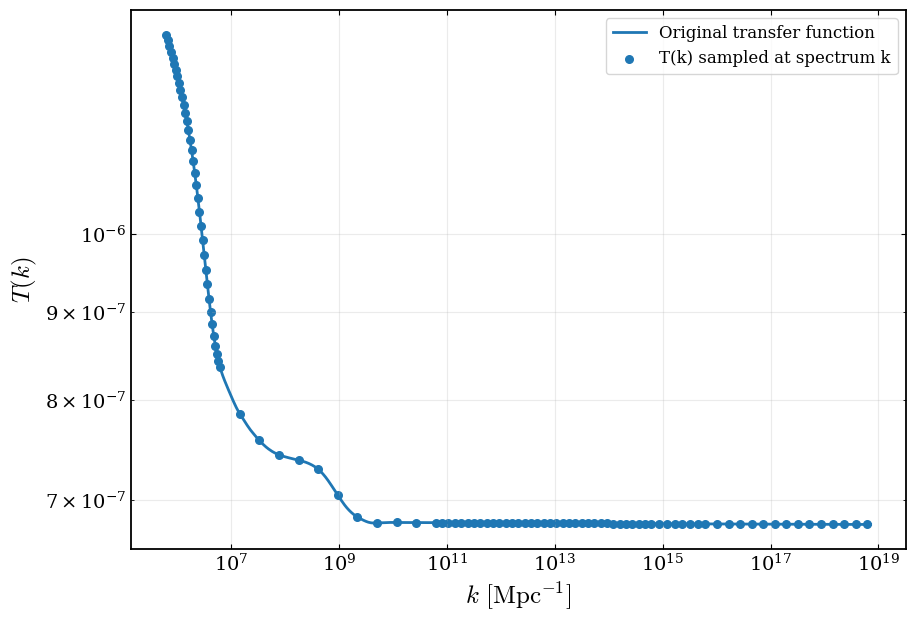

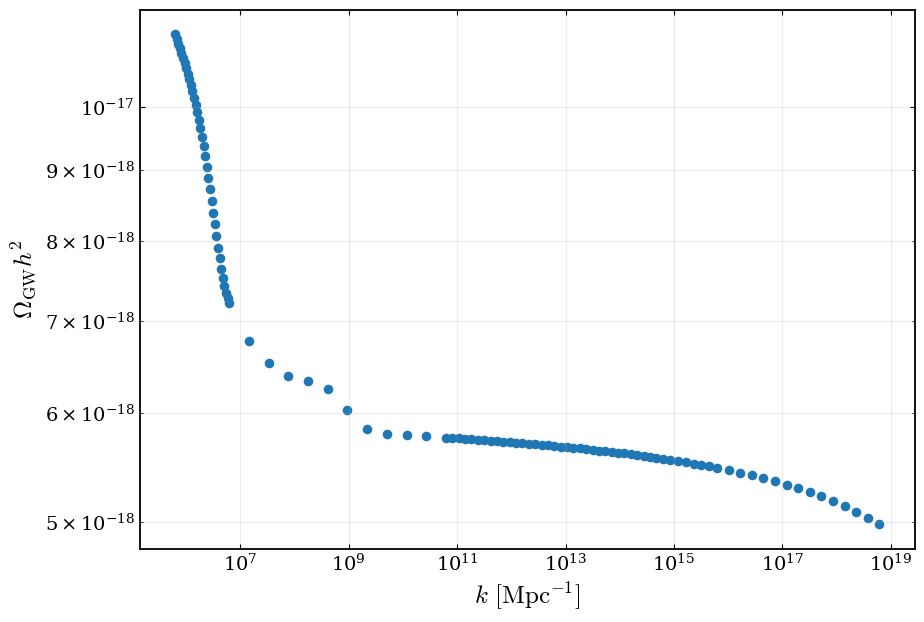

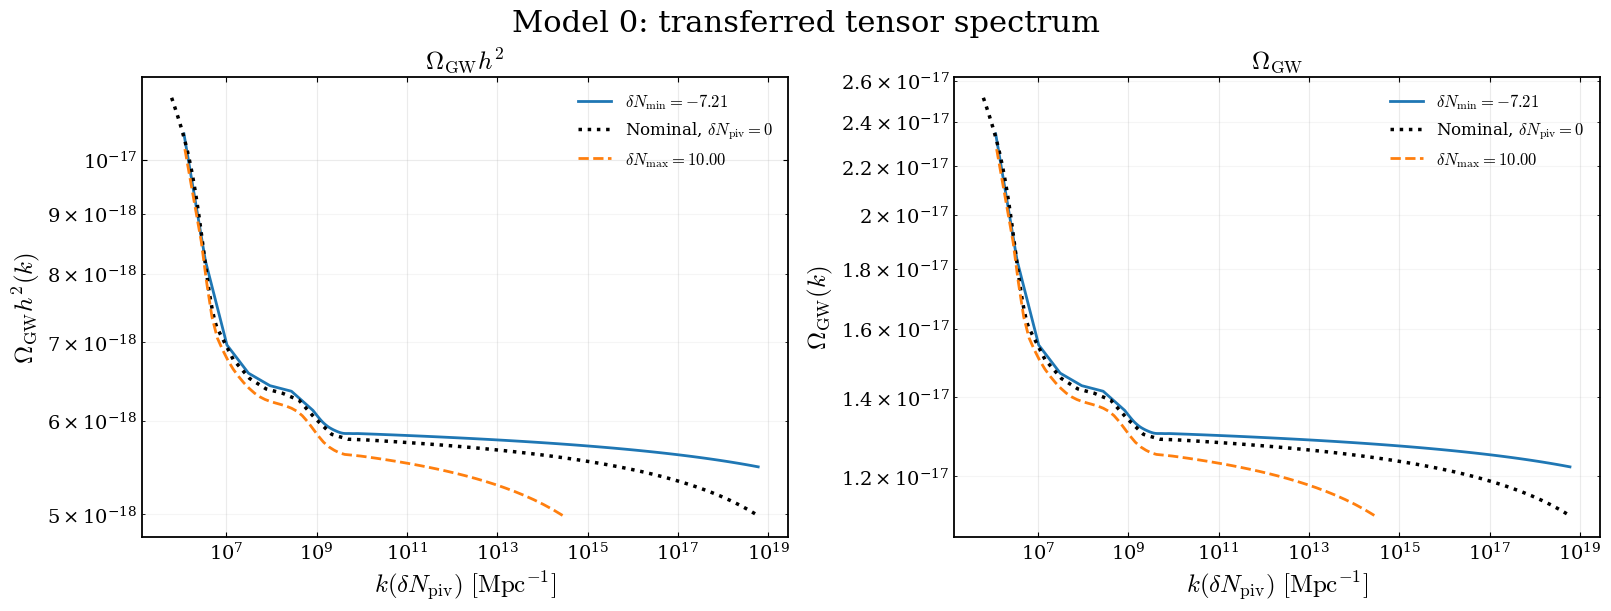


Saved figure: model_0_omegaGW_nominal_and_boundaries.png
   model_index                                             outdir  deltaN_min  \
0            0  /Users/epmeador/Desktop/research/rwarthur/infl...   -7.205167   

   deltaN_max  
0        10.0  


In [26]:
model0_omega = plot_one_model_omegaGW(
    model_index=0,
    deltaN_ranges_df=deltaN_ranges_df,
    tf_k_invMpc=tf_k_invMpc,
    tf_median=tf_median,
    NEQS=NEQS,
    h=0.67,
)

print(
    deltaN_ranges_df.loc[
        deltaN_ranges_df["model_index"] == 0
    ][["model_index", "outdir", "deltaN_min", "deltaN_max"]]
)



We know that a comiving mode $k$ exits the horizon when $k(N) = a(N) H(N)$. Given an associated $\delta N_{piv}$ value where $\delta N_{piv}= N_{eval} - N_{nominal}$, one may redefine $k \rightarrow k_{shifted} = k e^{\delta N_{piv}}$. In this case, we assume our $\Omega_{GW}h^2 = T(k_{shifted}) P_t(k)$ and similarly for as assume $h\approx 0.67$ for instance, $\Omega_{GW} = \frac{\Omega_{GW}h^2}{h^2}$. The point here is not to recompute the same tensor specrum but to apply a horizontal shift (translation in $k$). We assume that if the true horizon crossing point between $N$ and $k$ was off by $\delta N_{piv}$ due to truncation uncertainty, we can examine the same physical spectrums translated in $k-space$. The sign convetion assumes $\delta N_{piv} > 0$ means that the $N_{eval} > N_{nominal}$ so we are evaluating at an N that corresponds to earlier in time/further from the end of inflation which also corresponds to a larger physical scale (smaller k). $k_{shifted} = e^{-\deltaN_{piv}} < k$.



# Identify Passing Spectra and $\Omega_{GW,\delta N_{min}}$ and $\Omega_{GW,\delta N_{max}}$ for Many Passing Models

Now,for many models:

In [27]:

def ensure_increasing_k(k, values, name="data"):
    """
    Preserve the original k-value pairing.

    - Leave increasing data unchanged.
    - Reverse both arrays if strictly decreasing.
    - Refuse to reorder non-monotonic data.
    """

    k = np.asarray(k, dtype=float)
    values = np.asarray(values, dtype=float)

    if len(k) != len(values):
        raise ValueError(f"{name}: arrays have different lengths.")

    dk = np.diff(k)

    if np.all(dk > 0):
        return k, values

    if np.all(dk < 0):
        return k[::-1], values[::-1]

    raise ValueError(
        f"{name}: k is not monotonic. "
        "Data were not sorted automatically."
    )
    
    

## Allowed $\delta N_{piv}$ for Each Model

In [60]:
def plot_deltaN_intervals(
    deltaN_ranges_df,
    save_name="allowed_deltaN_intervals.png",
    show=True,
):
    """
    Plot each model's CMB-compatible deltaN_piv interval.

    Solid horizontal lines show the allowed interval for each
    model. The two endpoints are marked with points.
    """

    df = deltaN_ranges_df.copy()

    # Only models that pass somewhere
    df = df.loc[
        df["passes_cmb_somewhere"]
    ].copy()

    # Put models in model-index order
    df = df.sort_values(
        "model_index"
    )

    fig, ax = plt.subplots(
        figsize=(11, 10),
        constrained_layout=True,
    )

    for _, row in df.iterrows():

        model_index = int(
            row["model_index"]
        )

        deltaN_min = float(
            row["deltaN_min"]
        )

        deltaN_max = float(
            row["deltaN_max"]
        )

        # Draw the allowed interval
        ax.hlines(
            y=model_index,
            xmin=deltaN_min,
            xmax=deltaN_max,
            linewidth=1.5,
            linestyle="-",
            alpha=0.8,
        )

        # Mark the two boundaries
        ax.scatter(
            [deltaN_min, deltaN_max],
            [model_index, model_index],
            s=12,
            zorder=3,
        )

    # Nominal pivot location
    ax.axvline(
        0.0,
        color="black",
        linestyle=":",
        linewidth=2.0,
        label=r"Nominal: $\delta N_{\rm piv}=0$",
    )

    ax.set_xlabel(
        r"Allowed $\delta N_{\rm piv}$"
    )

    ax.set_ylabel(
        "Model index"
    )

    ax.set_title(
        r"CMB-compatible nuisance interval for each model"
    )

    ax.grid(
        True,
        axis="x",
        which="major",
        alpha=0.25,
    )

    ax.legend(
        frameon=False,
        loc="best",
    )

    fig.savefig(
        save_name,
        dpi=300,
        bbox_inches="tight",
    )

    if show:
        plt.show()
    else:
        plt.close(fig)

    print(
        f"Models plotted: {len(df)}"
    )

    print(
        f"Saved: {save_name}"
    )

    return df

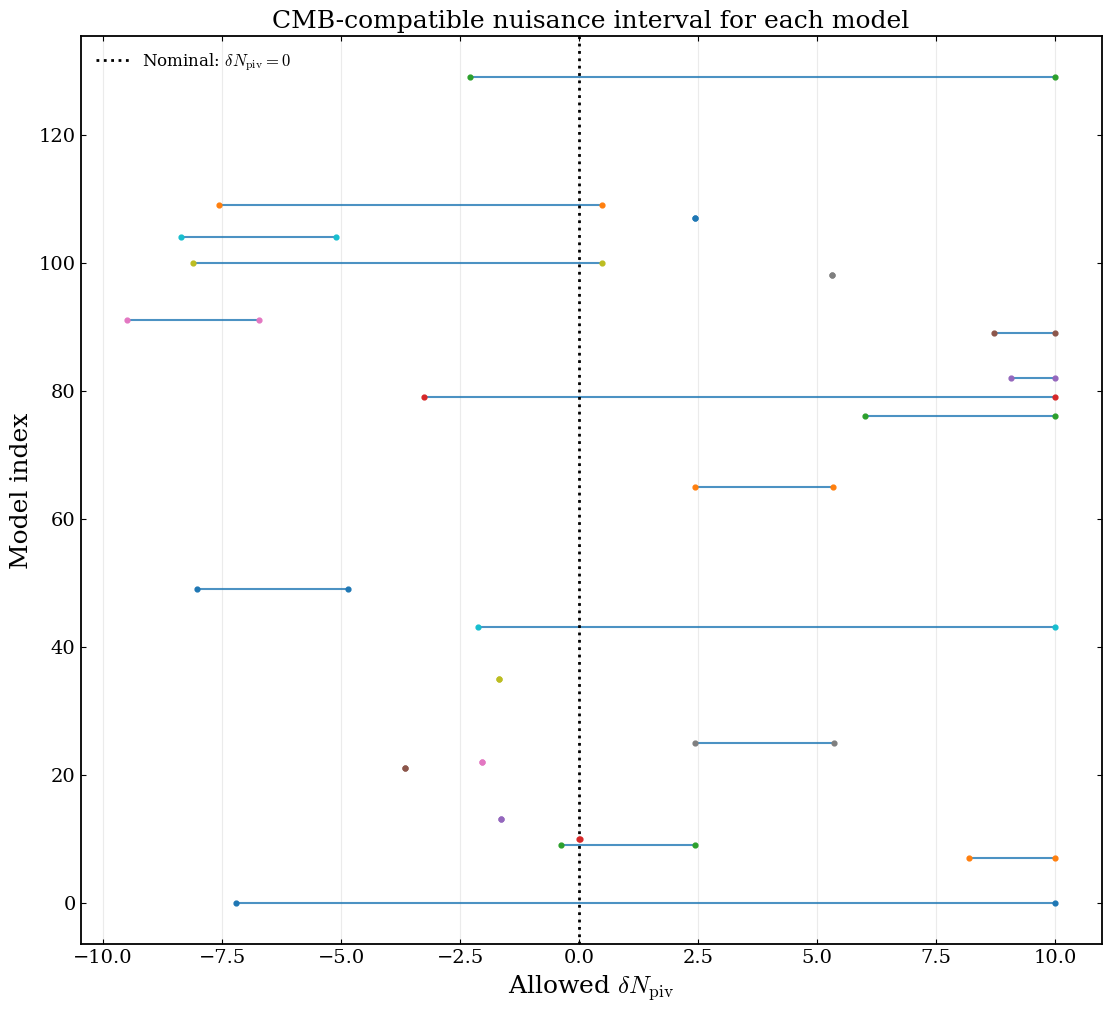

Models plotted: 23
Saved: allowed_deltaN_intervals.png


In [61]:
figureA_df = plot_deltaN_intervals(
    deltaN_ranges_df
)



A dashed interval means the passing saved points were not one consecutive block. Solid means continuous across the saved points, but these should all be continuous. ANotehr ord for this kind of plot is a forest plot! So a horizontal line sigment per model spanning that model's $\delta N$ range. There is honestly not much a pattern to this.

## Population of $\Omega_{GW}$ Bands Across ALLOWED Boundary Predictions

In [102]:
# def plot_population_omegaGW(
#     deltaN_ranges_df,
#     tf_k_invMpc,
#     tf_median,
#     NEQS=6,
#     h=0.67,
#     number_of_k_points=600,
#     require_continuous=True,
#     save_name="population_omegaGW_bands.png",
#     show=True,
# ):
#     """
#     Construct population Omega_GW bands from each model's
#     deltaN_min and deltaN_max boundary spectra.
#     """

#     # ========================================================
#     # 1. Prepare transfer function
#     # ========================================================
#     tf_k = np.asarray(
#         tf_k_invMpc,
#         dtype=float,
#     )

#     tf_T = np.asarray(
#         tf_median,
#         dtype=float,
#     )

#     good_tf = (
#         np.isfinite(tf_k)
#         & np.isfinite(tf_T)
#         & (tf_k > 0)
#         & (tf_T > 0)
#     )

#     tf_k = tf_k[good_tf]
#     tf_T = tf_T[good_tf]

#     tf_k, tf_T = ensure_increasing_k(
#         tf_k,
#         tf_T,
#         name="transfer function",
#     )

#     logT_interp = interp1d(
#         np.log(tf_k),
#         np.log(tf_T),
#         kind="linear",
#         bounds_error=False,
#         fill_value=np.nan,
#     )

#     kmin_tf = tf_k[0]
#     kmax_tf = tf_k[-1]

#     # ========================================================
#     # 2. Select usable models
#     # ========================================================
#     models_df = deltaN_ranges_df.loc[
#         deltaN_ranges_df["passes_cmb_somewhere"]
#     ].copy()

#     if require_continuous:
#         models_df = models_df.loc[
#             models_df["passing_range_continuous"]
#         ].copy()

#     # Each entry will hold one boundary curve
#     curve_records = []

#     skipped_models = []

#     # ========================================================
#     # 3. Build the two boundary curves for every model
#     # ========================================================
#     for _, row in models_df.iterrows():

#         model_index = int(row["model_index"])
#         outdir = row["outdir"]

#         tensor_file = os.path.join(
#             outdir,
#             f"spec_t_neqs{NEQS}.dat",
#         )

#         try:
#             tensor_data = np.loadtxt(
#                 tensor_file
#             )

#             k_raw = np.asarray(
#                 tensor_data[:, 0],
#                 dtype=float,
#             )

#             Pt_raw = np.abs(
#                 np.asarray(
#                     tensor_data[:, 1],
#                     dtype=float,
#                 )
#             )

#             good_tensor = (
#                 np.isfinite(k_raw)
#                 & np.isfinite(Pt_raw)
#                 & (k_raw > 0)
#                 & (Pt_raw > 0)
#             )

#             k_raw = k_raw[good_tensor]
#             Pt_raw = Pt_raw[good_tensor]

#             k_raw, Pt_raw = ensure_increasing_k(
#                 k_raw,
#                 Pt_raw,
#                 name=f"model {model_index}",
#             )

#             boundary_values = {
#                 "deltaN_min": float(
#                     row["deltaN_min"]
#                 ),
#                 "deltaN_max": float(
#                     row["deltaN_max"]
#                 ),
#             }

#             for boundary_name, deltaN in boundary_values.items():

#                 # Horizontal nuisance shift
#                 k_shifted = (
#                     k_raw
#                     * np.exp(-deltaN)
#                 )

#                 overlap = (
#                     (k_shifted >= kmin_tf)
#                     & (k_shifted <= kmax_tf)
#                 )

#                 k_use = k_shifted[overlap]
#                 Pt_use = Pt_raw[overlap]

#                 if len(k_use) < 5:
#                     continue

#                 T_use = np.exp(
#                     logT_interp(
#                         np.log(k_use)
#                     )
#                 )

#                 valid = (
#                     np.isfinite(T_use)
#                     & (T_use > 0)
#                     & np.isfinite(Pt_use)
#                     & (Pt_use > 0)
#                 )

#                 k_use = k_use[valid]
#                 Pt_use = Pt_use[valid]
#                 T_use = T_use[valid]

#                 if len(k_use) < 5:
#                     continue

#                 OmegaGW_h2 = (
#                     T_use
#                     * Pt_use
#                 )

#                 OmegaGW = (
#                     OmegaGW_h2
#                     / h**2
#                 )

#                 curve_records.append({
#                     "model_index": model_index,
#                     "boundary": boundary_name,
#                     "deltaN_piv": deltaN,
#                     "k": k_use,
#                     "OmegaGW_h2": OmegaGW_h2,
#                     "OmegaGW": OmegaGW,
#                 })

#         except (
#             FileNotFoundError,
#             ValueError,
#             IndexError,
#         ) as exc:

#             skipped_models.append({
#                 "model_index": model_index,
#                 "reason": str(exc),
#             })

#     if len(curve_records) == 0:
#         raise ValueError(
#             "No usable Omega_GW curves were produced."
#         )

#     # ========================================================
#     # 4. Find the shared k-domain
#     # ========================================================
#     common_k_min = max(
#         curve["k"].min()
#         for curve in curve_records
#     )

#     common_k_max = min(
#         curve["k"].max()
#         for curve in curve_records
#     )

#     if common_k_min >= common_k_max:
#         raise ValueError(
#             "The boundary curves do not share a common k-domain."
#         )

#     k_common = np.logspace(
#         np.log10(common_k_min),
#         np.log10(common_k_max),
#         number_of_k_points,
#     )

#     # ========================================================
#     # 5. Interpolate every curve onto the common grid
#     # ========================================================
#     omega_matrix = []

#     for curve in curve_records:

#         logOmega_interp = interp1d(
#             np.log(curve["k"]),
#             np.log(curve["OmegaGW"]),
#             kind="linear",
#             bounds_error=False,
#             fill_value=np.nan,
#         )

#         omega_common = np.exp(
#             logOmega_interp(
#                 np.log(k_common)
#             )
#         )

#         omega_matrix.append(
#             omega_common
#         )

#     omega_matrix = np.asarray(
#         omega_matrix
        
#     )
    

#     # ========================================================
#     # 6. Population statistics
#     # ========================================================
#     absolute_min = np.nanmin(
#         omega_matrix,
#         axis=0,
#     )

#     q05 = np.nanpercentile(
#         omega_matrix,
#         5,
#         axis=0,
#     )

#     q16 = np.nanpercentile(
#         omega_matrix,
#         16,
#         axis=0,
#     )

#     median = np.nanpercentile(
#         omega_matrix,
#         50,
#         axis=0,
#     )

#     q84 = np.nanpercentile(
#         omega_matrix,
#         84,
#         axis=0,
#     )

#     q95 = np.nanpercentile(
#         omega_matrix,
#         95,
#         axis=0,
#     )

#     absolute_max = np.nanmax(
#         omega_matrix,
#         axis=0,
#     )

#     # ========================================================
#     # 7. Plot
#     # ========================================================
#     fig, ax = plt.subplots(
#         figsize=(11, 7),
#         constrained_layout=True,
#     )
    
    

#     # Individual boundary curves
#     for omega_curve in omega_matrix:
#         ax.loglog(
#             k_common,
#             omega_curve,
#             linewidth=0.6,
#             alpha=0.06,
#         )
        
        
        

#     # Broad percentile band
#     ax.fill_between(
#         k_common,
#         q05,
#         q95,
#         alpha=0.18,
#         label="5–95% range",
#     )

#     # Central percentile band
#     ax.fill_between(
#         k_common,
#         q16,
#         q84,
#         alpha=0.32,
#         label="16–84% range",
#     )

#     # Median
#     ax.loglog(
#         k_common,
#         median,
#         color="black",
#         linewidth=2.6,
#         label="Median",
#     )

#     # Absolute population envelope
#     ax.loglog(
#         k_common,
#         absolute_min,
#         color="black",
#         linestyle="--",
#         linewidth=1.1,
#         alpha=0.75,
#         label="Absolute min/max",
#     )

#     ax.loglog(
#         k_common,
#         absolute_max,
#         color="black",
#         linestyle="--",
#         linewidth=1.1,
#         alpha=0.75,
#     )

#     ax.set_xlabel(
#         r"$k_{\rm shifted}\ [{\rm Mpc}^{-1}]$"
#     )

#     ax.set_ylabel(
#         r"$\Omega_{\rm GW}(k)$"
#     )

#     ax.set_title(
#         r"Population prediction including allowed "
#         r"$\delta N_{\rm piv}$ boundaries"
#     )

#     ax.grid(
#         True,
#         which="major",
#         alpha=0.25,
#     )

#     ax.grid(
#         True,
#         which="minor",
#         alpha=0.12,
#     )

#     ax.minorticks_on()
    
    
    
    
#     ####### FOr base
#     # Highlight one chosen base model
#     base_model_index = 0

#     base_curves = [
#         curve for curve in curve_records
#         if curve["model_index"] == base_model_index
#     ]

#     for curve in base_curves:
#         log_base_interp = interp1d(
#             np.log(curve["k"]),
#             np.log(curve["OmegaGW"]),
#             kind="linear",
#             bounds_error=False,
#             fill_value=np.nan,
#         )

#         base_omega_common = np.exp(
#             log_base_interp(np.log(k_common))
#         )

#         ax.loglog(
#             k_common,
#             base_omega_common,
#             color="crimson",
#             linestyle="--",
#             linewidth=2.2,
#             label=(
#                 f"Base model {base_model_index}"
#                 if curve is base_curves[0]
#                 else None
#             ),
#             zorder=5,
#         )


#     ax.legend(
#         frameon=False,
#         loc="best",
#     )

#     fig.savefig(
#         save_name,
#         dpi=300,
#         bbox_inches="tight",
#     )

#     if show:
#         plt.show()
#     else:
#         plt.close(fig)

#     # ========================================================
#     # 8. Save population bands in a DataFrame
#     # ========================================================
#     population_df = pd.DataFrame({
#         "k": k_common,
#         "OmegaGW_absolute_min": absolute_min,
#         "OmegaGW_q05": q05,
#         "OmegaGW_q16": q16,
#         "OmegaGW_median": median,
#         "OmegaGW_q84": q84,
#         "OmegaGW_q95": q95,
#         "OmegaGW_absolute_max": absolute_max,
#     })

#     print("\nPopulation OmegaGW summary")
#     print("=" * 60)
#     print(f"Models considered : {len(models_df)}")
#     print(f"Boundary curves   : {len(curve_records)}")
#     print(f"Skipped models    : {len(skipped_models)}")
#     print(
#         f"Common k range    : "
#         f"[{common_k_min:.4e}, {common_k_max:.4e}]"
#     )
#     print(f"Saved figure      : {save_name}")
#     print("=" * 60)

#     return (
#         population_df,
#         curve_records,
#         pd.DataFrame(skipped_models),
#     )

In [103]:
# population_omega_df, omega_curve_records, skipped_omega_models = (
#     plot_population_omegaGW(
#         deltaN_ranges_df=deltaN_ranges_df,
#         tf_k_invMpc=tf_k_invMpc,
#         tf_median=tf_median,
#         NEQS=6,
#         h=0.67,
#         number_of_k_points=600,
#         require_continuous=True,
#     )
# )

The percentile bands are calculated across those boundary curves. The dashed outer lines are the full min–max envelope, while the filled bands show where most of the predictions lie.
Note for later: the percentiles treat the two boundary curves as two population samples.

Does the shifted spectra contain the ranges we are interested in for astrometry and interferometry scales??? It should.


Did my base model pass though?

In [30]:
fiducial_rows = deltaN_ranges_df.loc[
    np.isclose(
        deltaN_ranges_df["deltaN_from_base"],
        0.0,
        atol=1e-8,
    )
]

print(fiducial_rows[[
    "model_index",
    "deltaN_from_base",
    "passes_cmb_somewhere",
    "deltaN_min",
    "deltaN_max",
]])

   model_index  deltaN_from_base  passes_cmb_somewhere  deltaN_min  deltaN_max
0            0               0.0                  True   -7.205167        10.0


# Determining the Liklihood

The next step here is to define a liklihood relative to the base model. There are a few additional steps we need to iron out before doing this. In general, the expectation is that we can compare each of the models with the measured value of $\Omega_{GW}$ for teh fiducial model. I will call this value:  $\Omega_{\rm meas}$. This measurement of $\Omega_{\rm meas}$ is drawn from a normal distribution about the fiducial model's true value $\Omega(k)$, with measurement uncertainty $\sigma$.
**Question 1: Is this supposed to be the base model without the shift???? Because the base model passes in between a specific $N_{min}$ and $N_{max}$.**
Following this definition of  $\Omega_{\rm meas}$, we can proceed to define a set of $\Omega_i(k)$ for all of the models passing the CMB cut off. Given an amplitude of the fiducial model we should be able to form

$\mathcal{L}\!\left(\Omega_{\rm meas} \mid \Omega(k)\right)
= \frac{1}{\sqrt{2\pi}\,\sigma}
\exp\!\left[
-\frac{\left(\Omega_{\rm meas} - \Omega(k)\right)^2}{2\sigma^2}
\right]$

and similarly, 

$\mathcal{L}\!\left(n_{\rm meas} \mid n(k)\right)
= \frac{1}{\sqrt{2\pi}\,\sigma}
\exp\!\left[
-\frac{\left(n_{\rm meas} - n(k)\right)^2}{2\sigma^2}
\right]$


We are most interested in probing scales relevant for astrometry and inferometry, these scales will be referred to as $k_{int}$ and $k_{ast}$, respectively. The form of the liklihood at each of these scales follows like so:

$\mathcal{L}_{\rm int}
=
\mathcal{L}\!\left(\Omega_{\rm meas, int} \mid \Omega(k_{\rm int})\right)
\times
\mathcal{L}\!\left(n_{\rm meas, int} \mid n(k_{\rm int})\right)$

$\mathcal{L}_{\rm ast}
=
\mathcal{L}\!\left(\Omega_{\rm meas, ast} \mid \Omega(k_{\rm ast})\right)
\times
\mathcal{L}\!\left(n_{\rm meas, ast} \mid n(k_{\rm ast})\right)$


Where it should be the case where the joint or total liklihood given measurements at all scales flows like:

$\mathcal{L}_{\rm total}
=
  \mathcal{L}_{\rm int} \times \mathcal{L}_{\rm ast}$
  
And, we expect that their uncertainties for us appear like,

$\sigma_{\rm int} = \frac{\Omega(k_{\rm meas, int})}{S_{\rm int}}
\qquad
\sigma_{\rm ast} = \frac{\Omega(k_{\rm meas, ast})}{S_{\rm ast}}$

Where SN is the assumed signal-to-noise of the fiducial detection. So, $S = 10$ corresponds to a 10 % amplitude measurement detection ($10\sigma$), $S = 5$ would be a 20 % detection ($5\sigma$), so on and so forth. These uncertainties we are having be a free choice rather than something set because the detections are set to take place in the future from now.


The problem to think through is the fact that I have just determined $\Omega_{GW}$ for passing CMB models and their associated minimum passing $\delta N_{min}$ and $\delta N_{max}$ from the nominal model. I am wondering the best way to utilize what I have. Specifically, Arthur stated


"Finally, as far as implementing the Delta N: for a given set of initial conditions, there will be
a small range of Delta N which are consistent with assumed measurements of n_s and r
at CMB scales. That is because as you change Delta N, you are slowly changing the value
of r and n_s as you vary Delta N. n_s in particular will be very well constrained. So what I
would do is pick random initial values for the slow-roll parameters consistent with the prior
ranges you decide on. Then for each one of those random models, look through the range
of allowable Delta N values to find which ones (if any) are consistent with assumed measurements
of n_s and r. I would keep the two which are on either end of the allowed Delta N range, maybe
noting them somehow as the upper and lower ends of the allowed range. We’ll have to decide
just how to display these or draw conclusions later."

So, I am taking this a step further to try and pick out the right way to compute the liklihood. One big difference is that I computed the full range for CMB validity according to the $\delta N$ interval I used. Arthur suggests picking randomly which is certainly different. 


Regardless, I will have to define my fiducial measurement.

# Fiducial Measurement

In [31]:
def define_fiducial_measurements(
    deltaN_ranges_df,
    tf_k_invMpc,
    tf_median,
    k_int,
    k_ast,
    NEQS=6,
    h=0.67,
    SN_int=10.0,
    SN_ast=10.0,
    deltaN_true=0.0,
):
    """
    Define the mock measurements used in the likelihood forecast.

    The true model is the fiducial model satisfying:

        deltaN_from_base = 0

    The default mock truth uses:

        deltaN_true = 0

    Returns the fiducial Omega_GW amplitude and local spectral slope
    at k_int and k_ast, along with assumed measurement uncertainties.
    """

    # --------------------------------------------------------
    # 1. Identify the true fiducial model
    # --------------------------------------------------------
    fiducial_matches = deltaN_ranges_df.loc[
        np.isclose(
            deltaN_ranges_df["deltaN_from_base"], #good deltaN_from_base = N_end - base_N_end
            0.0,
            atol=1e-8,
        )
    ]

    if fiducial_matches.empty:
        raise ValueError(
            "No fiducial model with deltaN_from_base = 0 was found."
        )

    if len(fiducial_matches) > 1: #better not be more than 1 I would say
        raise ValueError(
            "More than one model has deltaN_from_base = 0."
        )

    fiducial_row = fiducial_matches.iloc[0]

    model_index = int(fiducial_row["model_index"])
    deltaN_min = float(fiducial_row["deltaN_min"])
    deltaN_max = float(fiducial_row["deltaN_max"])
    outdir = fiducial_row["outdir"]

    # Check that the assumed true shift is CMB allowed
    if not (deltaN_min <= deltaN_true <= deltaN_max):
        raise ValueError(
            f"deltaN_true={deltaN_true:.4f} is outside the fiducial "
            f"CMB-compatible interval "
            f"[{deltaN_min:.4f}, {deltaN_max:.4f}]."
        )

    # --------------------------------------------------------
    # 2. Load the fiducial tensor spectrum
    # --------------------------------------------------------
    tensor_file = os.path.join(
        outdir,
        f"spec_t_neqs{NEQS}.dat",
    )

    tensor_data = np.loadtxt(tensor_file)

    k_raw = np.asarray(
        tensor_data[:, 0],
        dtype=float,
    )
    k_raw = k_raw * h   # convert h/Mpc -> Mpc^-1, to match tf_k_invMpc's units

    Pt_raw = np.abs(
        np.asarray(
            tensor_data[:, 1],
            dtype=float,
        )
    )

    good_tensor = (
        np.isfinite(k_raw)
        & np.isfinite(Pt_raw)
        & (k_raw > 0)
        & (Pt_raw > 0)
    )

    k_raw = k_raw[good_tensor]
    Pt_raw = Pt_raw[good_tensor]
    
    ## NO SHIFT IS EVER APPLIED!! THIS IS SUPPOSED TO BE THE NOMINAL UNSHIFTED SPEC FOR OUR BASE MODEL

    k_raw, Pt_raw = ensure_increasing_k(
        k_raw,
        Pt_raw,
        name="fiducial tensor spectrum",
    )

    # --------------------------------------------------------
    # 3. Prepare the transfer function
    # --------------------------------------------------------
    tf_k = np.asarray(
        tf_k_invMpc,
        dtype=float,
    )

    tf_T = np.asarray(
        tf_median,
        dtype=float,
    )

    good_tf = (
        np.isfinite(tf_k)
        & np.isfinite(tf_T)
        & (tf_k > 0)
        & (tf_T > 0)
    )

    tf_k = tf_k[good_tf]
    tf_T = tf_T[good_tf]

    tf_k, tf_T = ensure_increasing_k(
        tf_k,
        tf_T,
        name="transfer function",
    )

    logT_interp = interp1d(
        np.log(tf_k),
        np.log(tf_T),
        kind="linear",
        bounds_error=False,
        fill_value=np.nan,
    )


 # --------------------------------------------------------
# 4. Keep the fiducial spectrum unshifted
# --------------------------------------------------------

    overlap = (
        (k_raw >= tf_k[0])
        & (k_raw <= tf_k[-1])
    )

    k_use = k_raw[overlap]
    Pt_use = Pt_raw[overlap]

    # --------------------------------------------------------
    # 4b. Apply the transfer function
    # --------------------------------------------------------
    T_use = np.exp(
        logT_interp(
            np.log(k_use)
        )
    )

    valid = (
        np.isfinite(k_use)
        & np.isfinite(Pt_use)
        & np.isfinite(T_use)
        & (k_use > 0)
        & (Pt_use > 0)
        & (T_use > 0)
    )

    k_use = k_use[valid]
    Pt_use = Pt_use[valid]
    T_use = T_use[valid]

    OmegaGW_h2 = T_use * Pt_use
    OmegaGW = OmegaGW_h2 / h**2




    # --------------------------------------------------------
    # 5. Interpolate the observable spectrum
    # --------------------------------------------------------
    logOmega_interp = interp1d(
        np.log(k_use),
        np.log(OmegaGW),
        kind="linear",
        bounds_error=False,
        fill_value=np.nan,
    )

    def omega_at_k(k_target):
        value = np.exp(
            logOmega_interp(
                np.log(k_target)
            )
        )

        if not np.isfinite(value):
            raise ValueError(
                f"k={k_target:.4e} Mpc^-1 lies outside the "
                "fiducial transferred-spectrum range."
            )

        return float(value)

    # --------------------------------------------------------
    # 6. Local observable slope:
    #       n_Omega = d ln(Omega_GW) / d ln(k)
    # --------------------------------------------------------
    logk = np.log(k_use)
    logOmega = np.log(OmegaGW)

    nOmega_values = np.gradient(
        logOmega,
        logk,
    ) #this uses central differences in interior and onsesided diff at endpoints

    nOmega_interp = interp1d(
        logk,
        nOmega_values,
        kind="linear",
        bounds_error=False,
        fill_value=np.nan,
    )
    
#     nOmega_interp = logOmega_interp.derivative()


    def nOmega_at_k(k_target):
        value = nOmega_interp(
            np.log(k_target)
        )

        if not np.isfinite(value):
            raise ValueError(
                f"Cannot evaluate n_Omega at "
                f"k={k_target:.4e} Mpc^-1."
            )

        return float(value)

    # --------------------------------------------------------
    # 7. Mock measurements from the fiducial prediction
    # --------------------------------------------------------
    Omega_meas_int = omega_at_k(k_int)
    Omega_meas_ast = omega_at_k(k_ast)

    n_meas_int = nOmega_at_k(k_int)
    n_meas_ast = nOmega_at_k(k_ast)

    # Fixed experimental uncertainties
    sigma_Omega_int = (
        Omega_meas_int
        / SN_int
    )

    sigma_Omega_ast = (
        Omega_meas_ast
        / SN_ast
    )

    # --------------------------------------------------------
    # 8. Store everything
    # --------------------------------------------------------
    fiducial_measurements = {
        "model_index": model_index,
        "outdir": outdir,
        "deltaN_true": deltaN_true,
        "deltaN_min": deltaN_min,
        "deltaN_max": deltaN_max,

        "k_int": float(k_int),
        "Omega_meas_int": Omega_meas_int,
        "n_meas_int": n_meas_int,
        "SN_int": float(SN_int),
        "sigma_Omega_int": sigma_Omega_int,

        "k_ast": float(k_ast),
        "Omega_meas_ast": Omega_meas_ast,
        "n_meas_ast": n_meas_ast,
        "SN_ast": float(SN_ast),
        "sigma_Omega_ast": sigma_Omega_ast,

        "k_spectrum": k_use,
        "OmegaGW_spectrum": OmegaGW,
        "OmegaGW_h2_spectrum": OmegaGW_h2,
        "nOmega_spectrum": nOmega_values,
    }

    print("\nFiducial mock measurements")
    print("=" * 65)
    print(f"Fiducial model index : {model_index}")
    print(f"True deltaN          : {deltaN_true:.6f}")
    print(
        f"Allowed deltaN       : "
        f"[{deltaN_min:.6f}, {deltaN_max:.6f}]"
    )

    print("\nInterferometer scale")
    print(f"k_int                : {k_int:.6e} Mpc^-1")
    print(f"Omega_meas_int       : {Omega_meas_int:.6e}")
    print(f"n_meas_int           : {n_meas_int:.6e}")
    print(f"sigma_Omega_int      : {sigma_Omega_int:.6e}")

    print("\nAstrometry scale")
    print(f"k_ast                : {k_ast:.6e} Mpc^-1")
    print(f"Omega_meas_ast       : {Omega_meas_ast:.6e}")
    print(f"n_meas_ast           : {n_meas_ast:.6e}")
    print(f"sigma_Omega_ast      : {sigma_Omega_ast:.6e}")
    print("=" * 65)

    return fiducial_measurements




In [32]:
fiducial_data = define_fiducial_measurements(
    deltaN_ranges_df=deltaN_ranges_df,
    tf_k_invMpc=tf_k_invMpc,
    tf_median=tf_median,
    k_int=1.6e14,
    k_ast=2.05e7,
    NEQS=6,
    h=0.67,
    SN_int=10.0,
    SN_ast=10.0,
)


Omega_meas_int = fiducial_data["Omega_meas_int"]
Omega_meas_ast = fiducial_data["Omega_meas_ast"]

n_meas_int = fiducial_data["n_meas_int"]
n_meas_ast = fiducial_data["n_meas_ast"]





Fiducial mock measurements
Fiducial model index : 0
True deltaN          : 0.000000
Allowed deltaN       : [-7.205167, 10.000000]

Interferometer scale
k_int                : 1.600000e+14 Mpc^-1
Omega_meas_int       : 1.247781e-17
n_meas_int           : -5.008382e-03
sigma_Omega_int      : 1.247781e-18

Astrometry scale
k_ast                : 2.050000e+07 Mpc^-1
Omega_meas_ast       : 1.483457e-17
n_meas_ast           : -4.883567e-02
sigma_Omega_ast      : 1.483457e-18


# Stats Lesson for: Likelihood of $\Omega_{GW}$


I think it makes sense for $\delta N$ to be the nuisance parameter that gets marginalized over, and have the sampled slow-roll initial conditions label the underlying model. Given a set of slow roll parameters truncated to some order: $\epsilon_i, \sigma_i, ^2\lambda_i, ^X\lambda_i$, etc we find within an interval as wide as the uncertainty in $N_{end}$ a set of models that pass CMB constraints. Each of those models with a given $\delta N$ has an associated scalar and tensor spectra. The tensor spectra are shifted relative to their nominal model by amount $\delta N,i$, and using a standard transfer function we find $\Omega_{GW,i}$ and eventually $n(k,\delta N)$.


For each sampled model i overall steps we wanna:

Discard it if its physical end time differs from the fiducial by more than your selected cutoff, such as 20 e-folds.

Scan $\delta N$ over the nuisance range.

Calculate ns($\delta N$) and r($\delta N$)

Find the model-specific CMB-compatible interval $\delta N$ range. It might be better to not do hard cuts cause some models barely pass and receieve the same weight as some of those that pass more than edge case points.

Save the endpoints spectra for visualization.

Calculate 
$\Omega_{GW,i}(k_{int};\delta N)$, $n_{i}(k_{int};\delta N)$
$\Omega_{GW,i}(k_{ast};\delta N)$, $n_{i}(k_{ast};\delta N)$

Integrate join liklihood over $\delta N$

Assign one marginalized likelihood


NOW: Below we can look at OmegaGW at two scales for all CMB passing models 

In [33]:
def evaluate_model_omega_over_deltaN(
    model_index,
    deltaN_ranges_df,
    tf_k_invMpc,
    tf_median,
    k_int,
    k_ast,
    NEQS=6,
    h=0.67,
    number_deltaN=100,
):
    """
    Calculate Omega_GW at k_int and k_ast over one model's
    CMB-compatible deltaN interval.
    """

    # --------------------------------------------------------
    # Get model information
    # --------------------------------------------------------
    matches = deltaN_ranges_df.loc[
        deltaN_ranges_df["model_index"] == model_index
    ]

    if matches.empty:
        raise ValueError(
            f"No model found with model_index={model_index}."
        )

    row = matches.iloc[0] #remember iloc selects rows (or cols) by integrer position in df. in this row i want its value

    deltaN_min = float(row["deltaN_min"])
    deltaN_max = float(row["deltaN_max"])
    outdir = row["outdir"]

    # --------------------------------------------------------
    # Load tensor spectrum
    # --------------------------------------------------------
    tensor_file = os.path.join(
        outdir,
        f"spec_t_neqs{NEQS}.dat",
    )

    tensor_data = np.loadtxt(
        tensor_file
    )

    
    k_raw = np.asarray(
        tensor_data[:, 0],
        dtype=float,
    )
    k_raw = k_raw * h   # convert h/Mpc -> Mpc^-1, to match tf_k_invMpc's units

    Pt_raw = np.abs(
        np.asarray(
            tensor_data[:, 1],
            dtype=float,
        )
    )

    good_tensor = (
        np.isfinite(k_raw)
        & np.isfinite(Pt_raw)
        & (k_raw > 0)
        & (Pt_raw > 0)
    )

    k_raw = k_raw[good_tensor]
    Pt_raw = Pt_raw[good_tensor]
    

    k_raw, Pt_raw = ensure_increasing_k(
        k_raw,
        Pt_raw,
        name=f"Model {model_index} tensor spectrum",
    )    
    

    # --------------------------------------------------------
    # Prepare transfer function
    # --------------------------------------------------------
    
    
    
    tf_k = np.asarray(
        tf_k_invMpc,
        dtype=float,
    )

    tf_T = np.asarray(
        tf_median,
        dtype=float,
    )

    good_tf = (
        np.isfinite(tf_k)
        & np.isfinite(tf_T)
        & (tf_k > 0)
        & (tf_T > 0)
    )

    tf_k = tf_k[good_tf]
    tf_T = tf_T[good_tf]


    
    tf_k, tf_T = ensure_increasing_k(
        tf_k,
        tf_T,
        name="Transfer function",
    )

#     logT_interp = interp1d(
#         np.log(tf_k),
#         np.log(tf_T),
#         kind="linear",
#         bounds_error=False,
#         fill_value=np.nan,
#     )
    
    logT_interp = PchipInterpolator(
    np.log(tf_k),
    np.log(tf_T),
    extrapolate=False,
    ) #extrapolate false means querying outside domain will give me a nan


    # --------------------------------------------------------
    # Scan the allowed deltaN interval
    # --------------------------------------------------------
    #Given this space of deltaN, for every deltaN find me the OmegaGW
    deltaN_values = np.linspace(
        deltaN_min,
        deltaN_max,
        number_deltaN,
    )

    records = []

    for deltaN in deltaN_values:

        # Shift the tensor-spectrum k values
        k_shifted = (
            k_raw
            * np.exp(-deltaN)
        )

        # Transfer function evaluated on shifted k grid
        T_shifted = np.exp(
            logT_interp(
                np.log(k_shifted)
            )
        )

        OmegaGW = (
            T_shifted
            * Pt_raw
            / h**2
        )

        valid = (
            np.isfinite(k_shifted)
            & np.isfinite(OmegaGW)
            & (k_shifted > 0)
            & (OmegaGW > 0)
        )

        k_use = k_shifted[valid]
        omega_use = OmegaGW[valid]
        
        #Given this omega over the deltaN interval

        if len(k_use) < 2:
            continue

        # Interpolate Omega_GW in log(k)-log(Omega_GW)
#         log_omega_interp = interp1d(
#             np.log(k_use),
#             np.log(omega_use),
#             kind="linear",
#             bounds_error=False,
#             fill_value=np.nan,
#         )
        
        log_omega_interp = PchipInterpolator(
            np.log(k_use),
            np.log(omega_use),
            extrapolate=False,
        )

        #We then evaluate at scales of interest to us
        #This gives OmegaGW (k;deltaN) for both k scales
        omega_int = np.exp(
            log_omega_interp(
                np.log(k_int)
            )
        )

        omega_ast = np.exp(
            log_omega_interp(
                np.log(k_ast)
            )
        )

        records.append({
            "model_index": model_index,
            "deltaN": float(deltaN),
            "OmegaGW_int": float(omega_int),
            "OmegaGW_ast": float(omega_ast),
        })

    return pd.DataFrame(
        records
    )




In [34]:
k_int = 1.6e14

# Replace this with your chosen astrometry scale
k_ast = 2.05e7

model0_omega_vs_deltaN = (
    evaluate_model_omega_over_deltaN(
        model_index=0,
        deltaN_ranges_df=deltaN_ranges_df,
        tf_k_invMpc=tf_k_invMpc,
        tf_median=tf_median,
        k_int=k_int,
        k_ast=k_ast,
        NEQS=NEQS,
        h=0.67,
        number_deltaN=500, # number_deltaN is how finely I wanna uniformly sample this interval given my model 
    )
)

print(
    model0_omega_vs_deltaN.head()
)

print(
    model0_omega_vs_deltaN.tail()
)



   model_index    deltaN   OmegaGW_int   OmegaGW_ast
0            0 -7.205167  1.279538e-17  1.490296e-17
1            0 -7.170688  1.279428e-17  1.490417e-17
2            0 -7.136208  1.279317e-17  1.490562e-17
3            0 -7.101729  1.279208e-17  1.490705e-17
4            0 -7.067250  1.279097e-17  1.490852e-17
     model_index     deltaN   OmegaGW_int   OmegaGW_ast
495            0   9.862083  1.128908e-17  1.452282e-17
496            0   9.896562  1.128094e-17  1.452198e-17
497            0   9.931041  1.127275e-17  1.452164e-17
498            0   9.965521  1.126450e-17  1.452117e-17
499            0  10.000000  1.125621e-17  1.452013e-17



Model 0
deltaN_min     = -7.205167
deltaN_nominal = 0.000000
deltaN_max     = 10.000000
deltaN= -7.2052 | shift=1.3464e+03 | points=92
deltaN=  0.0000 | shift=1.0000e+00 | points=101
deltaN= 10.0000 | shift=4.5400e-05 | points=57


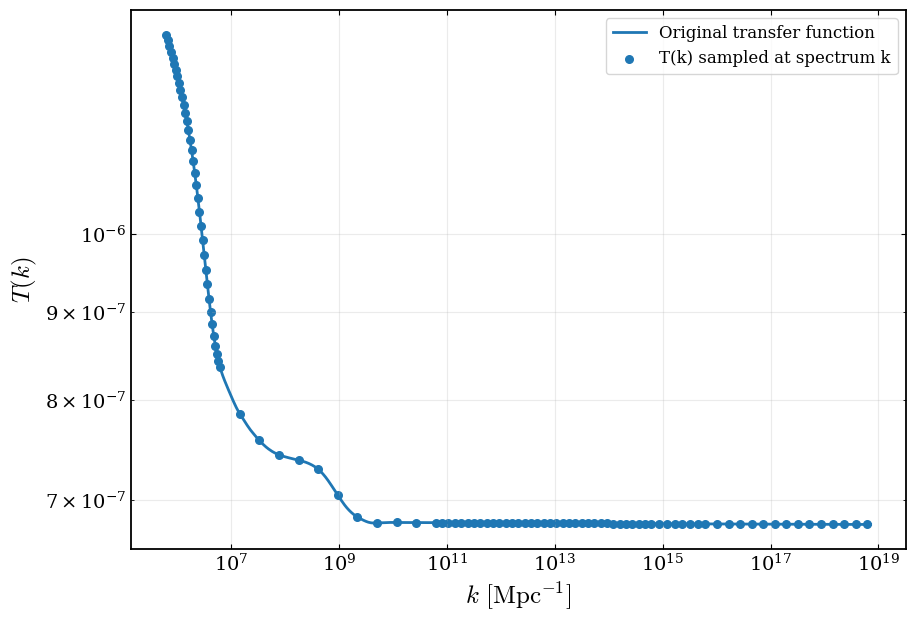

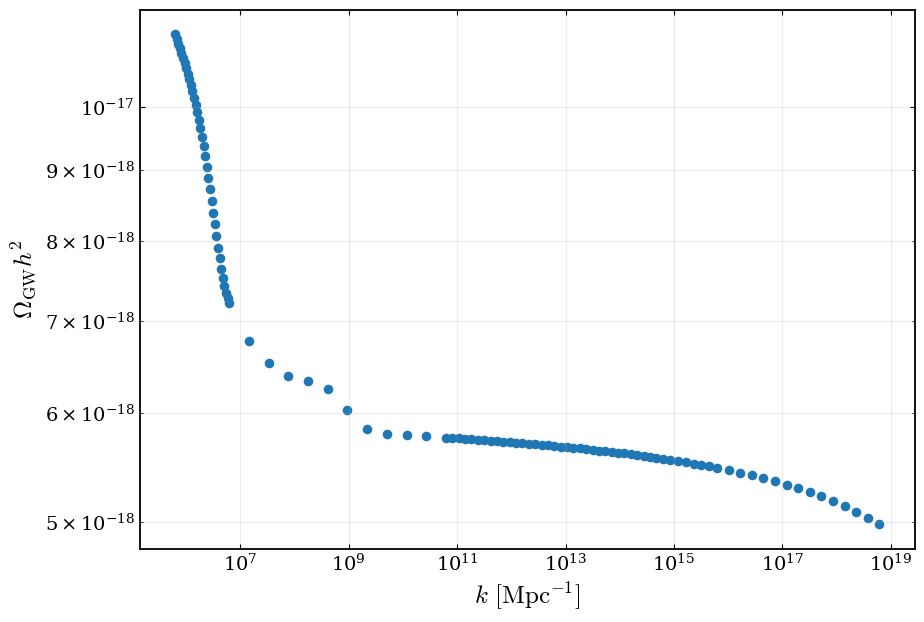


Saved figure: model_0_omegaGW_nominal_and_boundaries.png


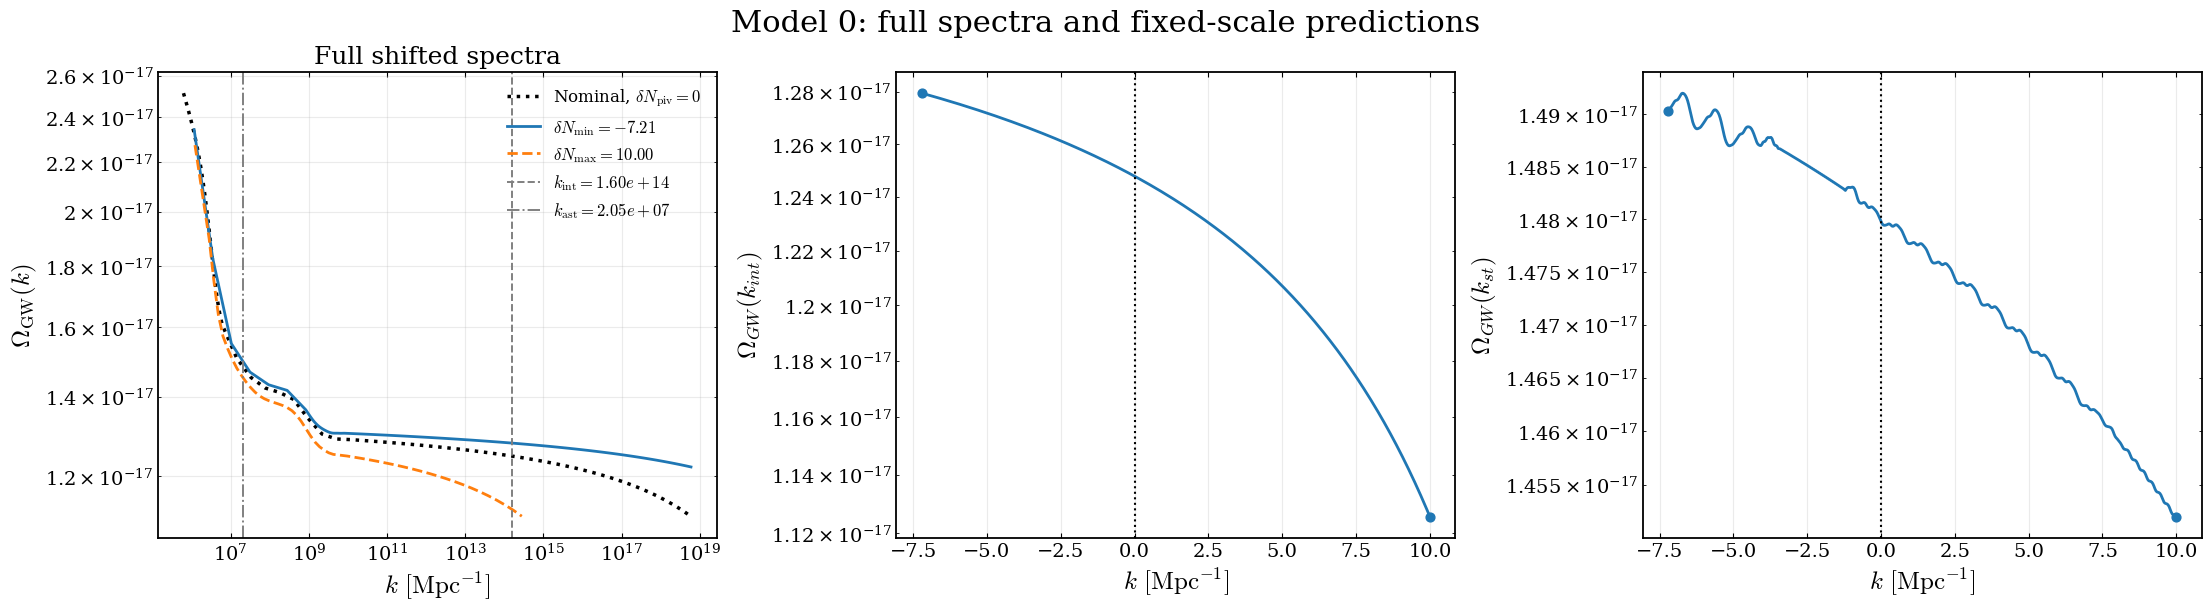

In [35]:
# ============================================================
# Full OmegaGW spectra and fixed-scale values over deltaN
# ============================================================

# Calculate the full nominal and endpoint spectra
model0_full_omega = plot_one_model_omegaGW(
    model_index=0,
    deltaN_ranges_df=deltaN_ranges_df,
    tf_k_invMpc=tf_k_invMpc,
    tf_median=tf_median,
    NEQS=NEQS,
    h=0.67,
    show=False, #is still saving a fig so be mindful
)

# Fixed scales
k_int = 1.6e14
k_ast = 2.05e7

# Values over the full allowed deltaN interval
model0_omega_vs_deltaN = evaluate_model_omega_over_deltaN(
    model_index=0,
    deltaN_ranges_df=deltaN_ranges_df,
    tf_k_invMpc=tf_k_invMpc,
    tf_median=tf_median,
    k_int=k_int,
    k_ast=k_ast,
    NEQS=NEQS,
    h=0.67,
    number_deltaN=500,
)

# Model endpoint values
deltaN_min = model0_full_omega["deltaN_min"]
deltaN_max = model0_full_omega["deltaN_max"]

# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------
fig, axes = plt.subplots(
    1,
    3,
    figsize=(22, 6),
    constrained_layout=True,
)

ax_full, ax_int, ax_ast = axes #yesss my three axes

# ------------------------------------------------------------
# Full OmegaGW spectra
# ------------------------------------------------------------
ax_full.loglog(
    model0_full_omega["k_nominal"],
    model0_full_omega["OmegaGW_nominal"],
    color="black",
    linestyle=":",
    linewidth=2.5,
    label=r"Nominal, $\delta N_{\rm piv}=0$",
)

ax_full.loglog(
    model0_full_omega["k_deltaN_min"],
    model0_full_omega["OmegaGW_deltaN_min"],
    linewidth=2.0,
    label=rf"$\delta N_{{\min}}={deltaN_min:.2f}$",
)

ax_full.loglog(
    model0_full_omega["k_deltaN_max"],
    model0_full_omega["OmegaGW_deltaN_max"],
    linestyle="--",
    linewidth=2.0,
    label=rf"$\delta N_{{\max}}={deltaN_max:.2f}$",
)

# Mark the two fixed scales
ax_full.axvline(
    k_int,
    color="gray",
    linestyle="--",
    linewidth=1.4,
    label=rf"$k_{{\rm int}}={k_int:.2e}$",
)

ax_full.axvline(
    k_ast,
    color="gray",
    linestyle="-.",
    linewidth=1.4,
    label=rf"$k_{{\rm ast}}={k_ast:.2e}$",
)



ax_full.set_xlabel(r"$k\ [{\rm Mpc}^{-1}]$")

ax_full.set_ylabel(
    r"$\Omega_{\rm GW}(k)$"
)

ax_full.set_title(
    r"Full shifted spectra"
)

ax_full.grid(
    True,
    which="both",
    alpha=0.25,
)

ax_full.legend(
    frameon=False,
    loc="best",
)

# ------------------------------------------------------------
# OmegaGW at interferometer scale
# ------------------------------------------------------------
ax_int.semilogy(
    model0_omega_vs_deltaN["deltaN"],
    model0_omega_vs_deltaN["OmegaGW_int"],
    linewidth=2.0,
)

ax_int.scatter(
    model0_omega_vs_deltaN["deltaN"].iloc[[0, -1]],
    model0_omega_vs_deltaN["OmegaGW_int"].iloc[[0, -1]],
    s=40,
    zorder=3,
)

ax_int.axvline(
    0.0,
    color="black",
    linestyle=":",
    linewidth=1.5,
)

ax_int.set_xlabel(
    r"$\delta N_{piv}$"
)

ax_int.set_ylabel(
    r"$\Omega_{GW}(k_{int})$"
)

ax_int.set_xlabel(r"$k\ [{\rm Mpc}^{-1}]$")


ax_int.grid(
    True,
    alpha=0.25,
)

# ------------------------------------------------------------
# OmegaGW at astrometry scale
# ------------------------------------------------------------
ax_ast.semilogy(
    model0_omega_vs_deltaN["deltaN"],
    model0_omega_vs_deltaN["OmegaGW_ast"],
    linewidth=2.0,
)

ax_ast.scatter(
    model0_omega_vs_deltaN["deltaN"].iloc[[0, -1]],
    model0_omega_vs_deltaN["OmegaGW_ast"].iloc[[0, -1]],
    s=40,
    zorder=3,
)

ax_ast.axvline(
    0.0,
    color="black",
    linestyle=":",
    linewidth=1.5,
)

ax_ast.set_xlabel(
    r"$\delta N_{piv}$"
)

ax_ast.set_ylabel(
    r"$\Omega_{GW}(k_{st})$"
)

ax_ast.set_xlabel(r"$k\ [{\rm Mpc}^{-1}]$")

ax_ast.grid(
    True,
    alpha=0.25,
)

fig.suptitle(
    r"Model 0: full spectra and fixed-scale predictions"
)

plt.show()




If I wanted to examine around the sampled points:

In [36]:
# fig, axes = plt.subplots(
#     1,
#     2,
#     figsize=(14, 5),
#     constrained_layout=True,
# )

# ax_int, ax_ast = axes

# ax_int.loglog(
#     model0_full_omega["k_nominal"],
#     model0_full_omega["OmegaGW_nominal"],
#     marker="o",
#     markersize=3,
#     linewidth=1.0,
# )

# ax_int.axvline(
#     k_int,
#     color="black",
#     linestyle="--",
# )

# ax_int.set_xlim(
#     k_int / 10.0,
#     k_int * 10.0,
# )

# ax_int.set_title(
#     "Sampling near interferometer scale"
# )

# ax_ast.loglog(
#     model0_full_omega["k_nominal"],
#     model0_full_omega["OmegaGW_nominal"],
#     marker="o",
#     markersize=3,
#     linewidth=1.0,
# )

# ax_ast.axvline(
#     k_ast,
#     color="black",
#     linestyle="--",
# )

# ax_ast.set_xlim(
#     k_ast / 10.0,
#     k_ast * 10.0,
# )

# ax_ast.set_title(
#     "Sampling near astrometry scale"
# )

# for ax in axes:
#     ax.set_xlabel(r"$k\ [{\rm Mpc}^{-1}]$")
#     ax.set_ylabel(r"$\Omega_{\rm GW}(k)$")
#     ax.grid(True, which="both", alpha=0.25)

# plt.show()



In [37]:
# plt.figure(figsize=(8, 5))

# plt.loglog(
#     tf_k_invMpc,
#     tf_median,
#     marker="o",
#     markersize=3,
#     linewidth=1.0,
# )

# plt.axvline(
#     k_ast,
#     color="black",
#     linestyle="--",
#     label=r"$k_{\rm ast}$",
# )

# plt.xlim(
#     k_ast / 10.0,
#     k_ast * 10.0,
# )

# plt.xlabel(r"$k\ [{\rm Mpc}^{-1}]$")
# plt.ylabel(r"$T(k)$")
# plt.grid(True, which="both", alpha=0.25)
# plt.legend()
# plt.show()

Displaying current number of points around the desired scale: aka there ain't enough



In [38]:
print(
    "CMB passing points:",
    int(
        deltaN_ranges_df.loc[
            deltaN_ranges_df["model_index"] == 0,
            "number_of_passing_points",
        ].iloc[0]
    )
)

print(
    "Omega deltaN points:",
    len(model0_omega_vs_deltaN)
)

factor = 2.0

n_tensor_near_ast = np.sum(
    (k_t >= k_ast / factor)
    & (k_t <= k_ast * factor)
)

n_transfer_near_ast = np.sum(
    (tf_k_invMpc >= k_ast / factor)
    & (tf_k_invMpc <= k_ast * factor)
)

print(
    "Tensor points within factor 2 of k_ast:",
    n_tensor_near_ast,
)

print(
    "Transfer points within factor 2 of k_ast:",
    n_transfer_near_ast,
)



CMB passing points: 17
Omega deltaN points: 500
Tensor points within factor 2 of k_ast: 1
Transfer points within factor 2 of k_ast: 602


In [39]:
k_ast = 2.05e7

deltaN_min = -2.205167
deltaN_max = 5.0

k_raw_ast_min = k_ast * np.exp(deltaN_min)
k_raw_ast_max = k_ast * np.exp(deltaN_max)

print("Raw tensor range needed:")
print(k_raw_ast_min, k_raw_ast_max)

n_tensor_relevant = np.sum(
    (k_t >= k_raw_ast_min)
    & (k_t <= k_raw_ast_max)
)

print(
    "Tensor points across full astrometry-relevant range:",
    n_tensor_relevant,
)

Raw tensor range needed:
2259758.3575832765 3042469761.6028204
Tensor points across full astrometry-relevant range: 27


# Acquiring $n_s(k; \delta N)$

Now that we have these $\Omega_{GW}$ values at each scale we can proceed to getting them at the two scales for ns too

In [40]:
def evaluate_model_n_over_deltaN(
    model_index,
    deltaN_ranges_df,
    tf_k_invMpc,
    tf_median,
    k_int,
    k_ast,
    NEQS=6,
    h=0.67,
    number_deltaN=500,
):
    """
    Calculate n(k) at k_int and k_ast over one model's
    CMB-compatible deltaN interval.

    n(k) = d ln(Omega_GW) / d ln(k)
    """

    matches = deltaN_ranges_df.loc[
        deltaN_ranges_df["model_index"] == model_index
    ]

    if matches.empty:
        raise ValueError(
            f"No model found with model_index={model_index}."
        )

    row = matches.iloc[0]

    deltaN_min = float(row["deltaN_min"])
    deltaN_max = float(row["deltaN_max"])
    outdir = row["outdir"]

    tensor_file = os.path.join(
        outdir,
        f"spec_t_neqs{NEQS}.dat",
    )

    tensor_data = np.loadtxt(
        tensor_file
    )
    
    
    
    k_raw = np.asarray(
        tensor_data[:, 0],
        dtype=float,
    )
    k_raw = k_raw * h   # convert h/Mpc -> Mpc^-1, to match tf_k_invMpc's units

    Pt_raw = np.abs(
        np.asarray(
            tensor_data[:, 1],
            dtype=float,
        )
    )

    good_tensor = (
        np.isfinite(k_raw)
        & np.isfinite(Pt_raw)
        & (k_raw > 0)
        & (Pt_raw > 0)
    )

    k_raw = k_raw[good_tensor]
    Pt_raw = Pt_raw[good_tensor]
    

    k_raw, Pt_raw = ensure_increasing_k(
        k_raw,
        Pt_raw,
        name=f"Model {model_index} tensor spectrum",
    )    
    
    
###TF filtering

    tf_k = np.asarray(
        tf_k_invMpc,
        dtype=float,
    )

    tf_T = np.asarray(
        tf_median,
        dtype=float,
    )

    good_tf = (
        np.isfinite(tf_k)
        & np.isfinite(tf_T)
        & (tf_k > 0)
        & (tf_T > 0)
    )

    tf_k = tf_k[good_tf]
    tf_T = tf_T[good_tf]
    
    
    tf_k, tf_T = ensure_increasing_k(
        tf_k,
        tf_T,
        name="Transfer function",
    )

    logT_interp = PchipInterpolator(
        np.log(tf_k),
        np.log(tf_T),
        extrapolate=False,
    )

    deltaN_values = np.linspace(
        deltaN_min,
        deltaN_max,
        number_deltaN,
    )

    records = []

    for deltaN in deltaN_values:

        k_shifted = (
            k_raw
            * np.exp(-deltaN)
        )

        T_shifted = np.exp(
            logT_interp(
                np.log(k_shifted)
            )
        )

        OmegaGW = (
            T_shifted
            * Pt_raw
            / h**2
        )

        valid = (
            np.isfinite(k_shifted)
            & np.isfinite(OmegaGW)
            & (k_shifted > 0)
            & (OmegaGW > 0)
        )

        k_use = k_shifted[valid]
        omega_use = OmegaGW[valid]

        if len(k_use) < 2:
            continue

        log_omega_interp = PchipInterpolator(
            np.log(k_use),
            np.log(omega_use),
            extrapolate=False,
        )

        #get that derivative
        n_interp = log_omega_interp.derivative()

        n_int = n_interp(
            np.log(k_int)
        )

        n_ast = n_interp(
            np.log(k_ast)
        )

        records.append({
            "model_index": model_index,
            "deltaN": float(deltaN),
            "n_int": float(n_int),
            "n_ast": float(n_ast),
        })

    return pd.DataFrame(
        records
    )



In [41]:
k_int = 1.6e14
k_ast = 2.05e7

model0_n_vs_deltaN = evaluate_model_n_over_deltaN(
    model_index=0,
    deltaN_ranges_df=deltaN_ranges_df,
    tf_k_invMpc=tf_k_invMpc,
    tf_median=tf_median,
    k_int=k_int,
    k_ast=k_ast,
    NEQS=NEQS,
    h=0.67,
    number_deltaN=500,
)

print(
    model0_n_vs_deltaN.head()
)

print(
    model0_n_vs_deltaN.tail()
)

   model_index    deltaN     n_int     n_ast
0            0 -7.205167 -0.002626 -0.043697
1            0 -7.170688 -0.002633 -0.043257
2            0 -7.136208 -0.002640 -0.042834
3            0 -7.101729 -0.002649 -0.042455
4            0 -7.067250 -0.002654 -0.042125
     model_index     deltaN     n_int     n_ast
495            0   9.862083 -0.020977 -0.047973
496            0   9.896562 -0.021126 -0.047194
497            0   9.931041 -0.021278 -0.046812
498            0   9.965521 -0.021432 -0.046842
499            0  10.000000 -0.021591 -0.047214



Model 0
deltaN_min     = -7.205167
deltaN_nominal = 0.000000
deltaN_max     = 10.000000
deltaN= -7.2052 | shift=1.3464e+03 | points=92
deltaN=  0.0000 | shift=1.0000e+00 | points=101
deltaN= 10.0000 | shift=4.5400e-05 | points=57


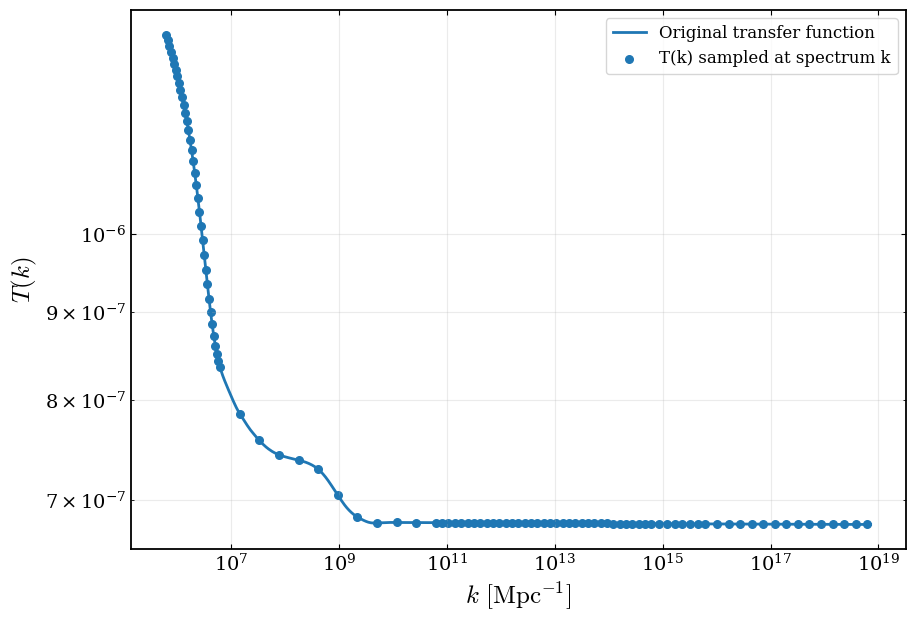

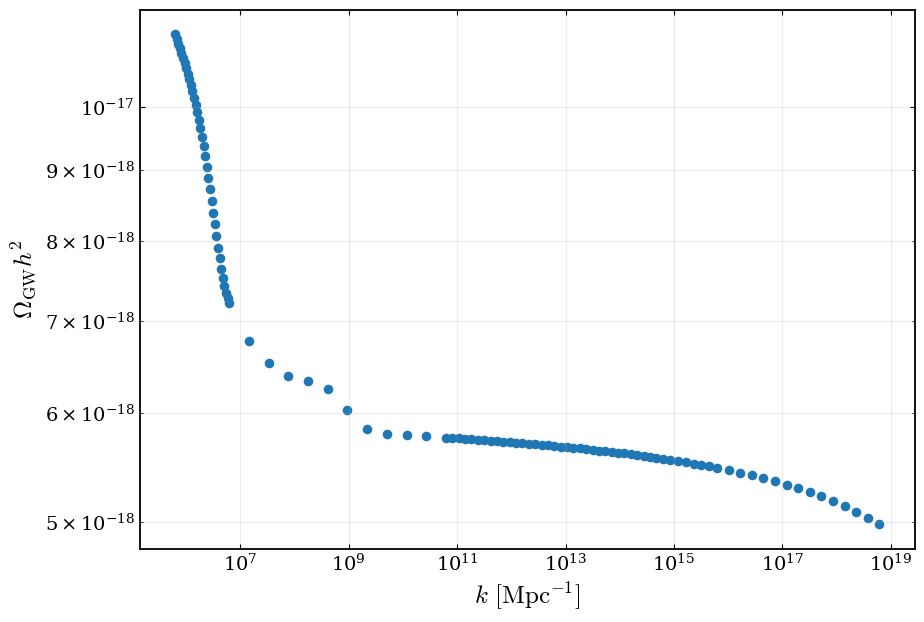


Saved figure: model_0_omegaGW_nominal_and_boundaries.png


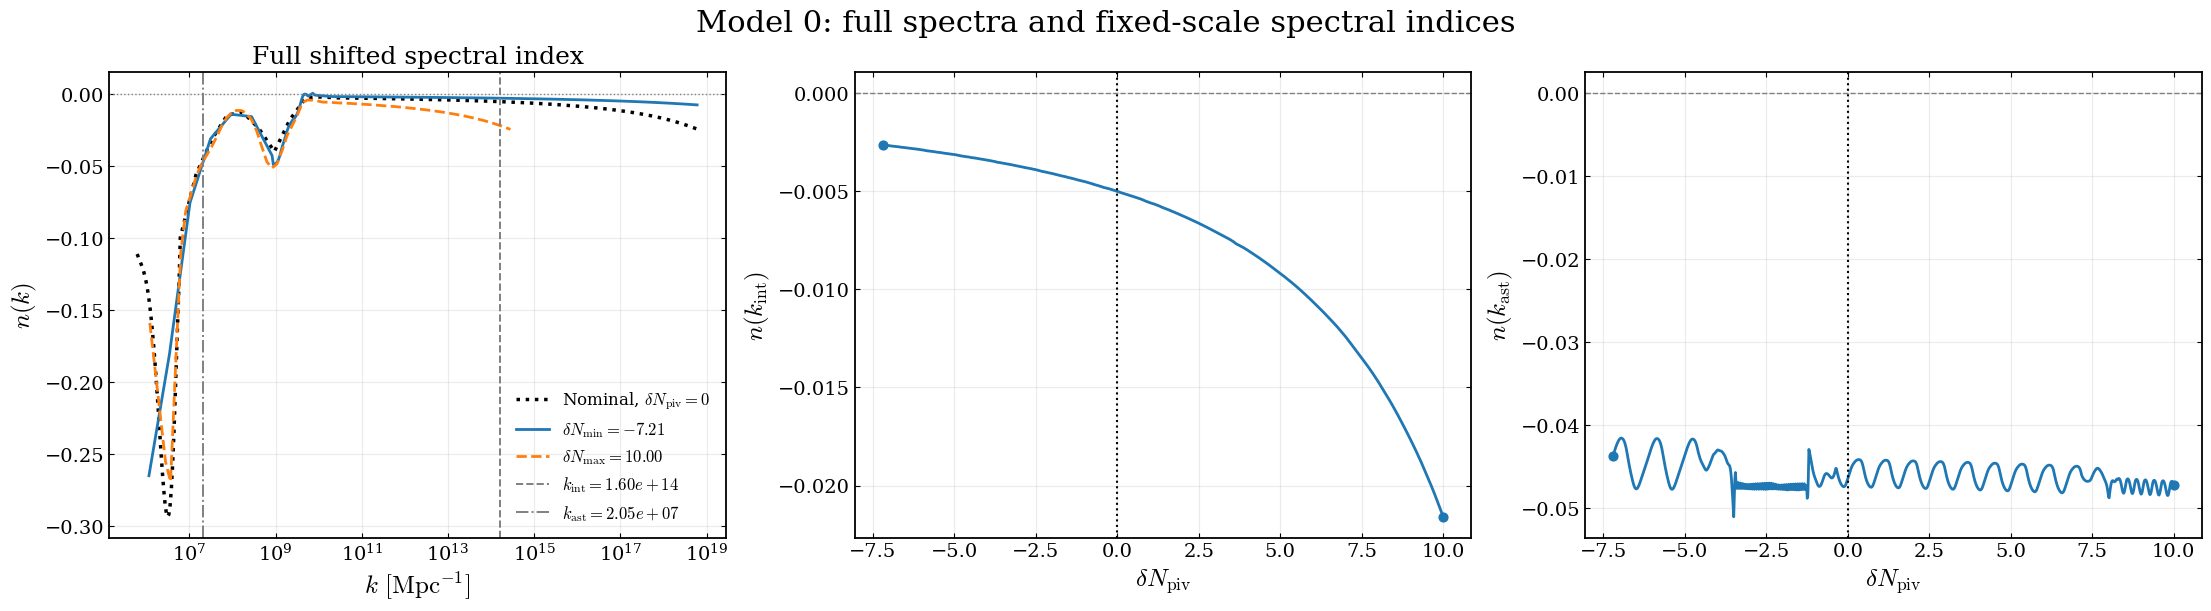

In [42]:
# ============================================================
# Full n(k) spectra and fixed-scale values over deltaN
# ============================================================

model0_full_omega = plot_one_model_omegaGW(
    model_index=0,
    deltaN_ranges_df=deltaN_ranges_df,
    tf_k_invMpc=tf_k_invMpc,
    tf_median=tf_median,
    NEQS=NEQS,
    h=0.67,
    show=False,
)

k_int = 1.6e14
k_ast = 2.05e7

model0_n_vs_deltaN = evaluate_model_n_over_deltaN(
    model_index=0,
    deltaN_ranges_df=deltaN_ranges_df,
    tf_k_invMpc=tf_k_invMpc,
    tf_median=tf_median,
    k_int=k_int,
    k_ast=k_ast,
    NEQS=NEQS,
    h=0.67,
    number_deltaN=1000,
)

deltaN_min = model0_full_omega["deltaN_min"]
deltaN_max = model0_full_omega["deltaN_max"]


# ------------------------------------------------------------
# Calculate full n(k) curves
# ------------------------------------------------------------
nominal_interp = PchipInterpolator(
    np.log(model0_full_omega["k_nominal"]),
    np.log(model0_full_omega["OmegaGW_nominal"]),
    extrapolate=False,
)

min_interp = PchipInterpolator(
    np.log(model0_full_omega["k_deltaN_min"]),
    np.log(model0_full_omega["OmegaGW_deltaN_min"]),
    extrapolate=False,
)

max_interp = PchipInterpolator(
    np.log(model0_full_omega["k_deltaN_max"]),
    np.log(model0_full_omega["OmegaGW_deltaN_max"]),
    extrapolate=False,
)

n_nominal = nominal_interp.derivative()(
    np.log(model0_full_omega["k_nominal"])
)

n_deltaN_min = min_interp.derivative()(
    np.log(model0_full_omega["k_deltaN_min"])
)

n_deltaN_max = max_interp.derivative()(
    np.log(model0_full_omega["k_deltaN_max"])
)


# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------
fig, axes = plt.subplots(
    1,
    3,
    figsize=(22, 6),
    constrained_layout=True,
)

ax_full, ax_int, ax_ast = axes


# ------------------------------------------------------------
# Full n(k) spectra
# ------------------------------------------------------------
ax_full.semilogx(
    model0_full_omega["k_nominal"],
    n_nominal,
    color="black",
    linestyle=":",
    linewidth=2.5,
    label=r"Nominal, $\delta N_{\rm piv}=0$",
)

ax_full.semilogx(
    model0_full_omega["k_deltaN_min"],
    n_deltaN_min,
    linewidth=2.0,
    label=rf"$\delta N_{{\min}}={deltaN_min:.2f}$",
)

ax_full.semilogx(
    model0_full_omega["k_deltaN_max"],
    n_deltaN_max,
    linestyle="--",
    linewidth=2.0,
    label=rf"$\delta N_{{\max}}={deltaN_max:.2f}$",
)

ax_full.axvline(
    k_int,
    color="gray",
    linestyle="--",
    linewidth=1.4,
    label=rf"$k_{{\rm int}}={k_int:.2e}$",
)

ax_full.axvline(
    k_ast,
    color="gray",
    linestyle="-.",
    linewidth=1.4,
    label=rf"$k_{{\rm ast}}={k_ast:.2e}$",
)

ax_full.axhline(
    0.0,
    color="gray",
    linestyle=":",
    linewidth=1.0,
)

ax_full.set_xlabel(
    r"$k\ [{\rm Mpc}^{-1}]$"
)

ax_full.set_ylabel(
    r"$n(k)$"
)

ax_full.set_title(
    r"Full shifted spectral index"
)

ax_full.grid(
    True,
    which="both",
    alpha=0.25,
)

ax_full.legend(
    frameon=False,
    loc="best",
)


# ------------------------------------------------------------
# n at interferometer scale
# ------------------------------------------------------------
ax_int.plot(
    model0_n_vs_deltaN["deltaN"],
    model0_n_vs_deltaN["n_int"],
    linewidth=2.0,
)

ax_int.scatter(
    model0_n_vs_deltaN["deltaN"].iloc[[0, -1]],
    model0_n_vs_deltaN["n_int"].iloc[[0, -1]],
    s=40,
    zorder=3,
)

ax_int.axvline(
    0.0,
    color="black",
    linestyle=":",
    linewidth=1.5,
)

ax_int.axhline(
    0.0,
    color="gray",
    linestyle="--",
    linewidth=1.0,
)

ax_int.set_xlabel(
    r"$\delta N_{\rm piv}$"
)

ax_int.set_ylabel(
    r"$n(k_{\rm int})$"
)

ax_int.grid(
    True,
    alpha=0.25,
)


# ------------------------------------------------------------
# n at astrometry scale
# ------------------------------------------------------------
ax_ast.plot(
    model0_n_vs_deltaN["deltaN"],
    model0_n_vs_deltaN["n_ast"],
    linewidth=2.0,
)

ax_ast.scatter(
    model0_n_vs_deltaN["deltaN"].iloc[[0, -1]],
    model0_n_vs_deltaN["n_ast"].iloc[[0, -1]],
    s=40,
    zorder=3,
)

ax_ast.axvline(
    0.0,
    color="black",
    linestyle=":",
    linewidth=1.5,
)

ax_ast.axhline(
    0.0,
    color="gray",
    linestyle="--",
    linewidth=1.0,
)

ax_ast.set_xlabel(
    r"$\delta N_{\rm piv}$"
)

ax_ast.set_ylabel(
    r"$n(k_{\rm ast})$"
)

ax_ast.grid(
    True,
    alpha=0.25,
)

fig.suptitle(
    r"Model 0: full spectra and fixed-scale spectral indices"
)

plt.show()

# Generating the Liklihood -- Marginalizing Over $\delta N$


There is a link to this helpful site: https://prappleizer.github.io/Tutorials/MCMC/MCMC_Tutorial.html
and this one:  https://emcee.readthedocs.io/en/stable/tutorials/line/

They use EMCEE. In our case, I only have one "nuisance parameter" which is $\delta N$. I already have my $\Omega_GW(k;\delta N)$ and $n_\Omega (k;\delta N)$ both as functions of $\delta N$. From my understanding if I have more nuisance parameters, it is useful to use MCMC or some other method to get my likelihood but I really think I would only need to marginalize over this one variable.

I can define a log-liklihood at the interferometer scale, and another at the astrometry scale. I should be able to marginalize over all the $\delta N$ values over my interval to get a marginalized likelihood. This marginalization is an integration (sum) over all $\delta N$ values for the model.

I will define several pieces.

First, the log-likelihood probability density:

Why log? Because of numerical stability, easier this way computationally.

In [43]:
def gaussian_log_likelihood(
    measured,
    predicted,
    sigma,
):
    """
    Gaussian log-likelihood for one measurement.
    """

    return (
        -0.5
        * (
            (measured - predicted) / sigma
        )**2
        - np.log(
            np.sqrt(2.0 * np.pi) * sigma
        )
    )


#squared residual over variance penalty (in log space)
#second term is normalization constant of gaussian
#im looking at normalized log probablily density here.
#i need that normalization term
#


Merged version of my functions beforehand: 

    evaluate_model_omega_and_n_over_deltaN

In [44]:
def evaluate_model_omega_and_n_over_deltaN(
    model_index,
    deltaN_ranges_df,
    tf_k_invMpc,
    tf_median,
    k_int,
    k_ast,
    NEQS=6,
    h=0.67,
    number_deltaN=100,
):
    """
    Calculate Omega_GW and n(k) = d ln(Omega_GW)/d ln(k)
    at k_int and k_ast, over one model's CMB-compatible
    deltaN interval.
    """

    # --------------------------------------------------------
    # Get model information
    # --------------------------------------------------------
    matches = deltaN_ranges_df.loc[
        deltaN_ranges_df["model_index"] == model_index
    ]

    if matches.empty:
        raise ValueError(
            f"No model found with model_index={model_index}."
        )

    row = matches.iloc[0]

    deltaN_min = float(row["deltaN_min"])
    deltaN_max = float(row["deltaN_max"])
    outdir = row["outdir"]

    # --------------------------------------------------------
    # Load tensor spectrum
    # --------------------------------------------------------
    tensor_file = os.path.join(
        outdir,
        f"spec_t_neqs{NEQS}.dat",
    )

    tensor_data = np.loadtxt(tensor_file)

    k_raw = np.asarray(tensor_data[:, 0], dtype=float)
    k_raw = k_raw * h   # convert h/Mpc -> Mpc^-1, to match tf_k_invMpc's units

    Pt_raw = np.abs(np.asarray(tensor_data[:, 1], dtype=float))

    good_tensor = (
        np.isfinite(k_raw)
        & np.isfinite(Pt_raw)
        & (k_raw > 0)
        & (Pt_raw > 0)
    )

    k_raw = k_raw[good_tensor]
    Pt_raw = Pt_raw[good_tensor]

    k_raw, Pt_raw = ensure_increasing_k(
        k_raw,
        Pt_raw,
        name=f"Model {model_index} tensor spectrum",
    )

    # --------------------------------------------------------
    # Prepare transfer function
    # --------------------------------------------------------
    tf_k = np.asarray(tf_k_invMpc, dtype=float)
    tf_T = np.asarray(tf_median, dtype=float)

    good_tf = (
        np.isfinite(tf_k)
        & np.isfinite(tf_T)
        & (tf_k > 0)
        & (tf_T > 0)
    )

    tf_k = tf_k[good_tf]
    tf_T = tf_T[good_tf]

    tf_k, tf_T = ensure_increasing_k(
        tf_k,
        tf_T,
        name="Transfer function",
    )

    logT_interp = PchipInterpolator(
        np.log(tf_k),
        np.log(tf_T),
        extrapolate=False,
    )

    # --------------------------------------------------------
    # Scan the allowed deltaN interval
    # --------------------------------------------------------
    deltaN_values = np.linspace(
        deltaN_min,
        deltaN_max,
        number_deltaN,
    )

    records = []

    for deltaN in deltaN_values:

        k_shifted = k_raw * np.exp(-deltaN)

        T_shifted = np.exp(
            logT_interp(np.log(k_shifted))
        )

        OmegaGW = T_shifted * Pt_raw / h**2

        valid = (
            np.isfinite(k_shifted)
            & np.isfinite(OmegaGW)
            & (k_shifted > 0)
            & (OmegaGW > 0)
        )

        k_use = k_shifted[valid]
        omega_use = OmegaGW[valid]

        if len(k_use) < 2:
            continue

        log_omega_interp = PchipInterpolator(
            np.log(k_use),
            np.log(omega_use),
            extrapolate=False,
        )

        # Amplitude at both scales
        omega_int = np.exp(log_omega_interp(np.log(k_int)))
        omega_ast = np.exp(log_omega_interp(np.log(k_ast)))

        # Slope at both scales -- reuses the SAME interpolator, no rebuilding
        n_interp = log_omega_interp.derivative()
        n_int = n_interp(np.log(k_int))
        n_ast = n_interp(np.log(k_ast))

        records.append({
            "model_index": model_index,
            "deltaN": float(deltaN),
            "OmegaGW_int": float(omega_int),
            "OmegaGW_ast": float(omega_ast),
            "n_int": float(n_int),
            "n_ast": float(n_ast),
        })

    return pd.DataFrame(records)

Interferometer scale likelihood for one model:

In [45]:
def evaluate_model_int_likelihood(
    model_index,
    deltaN_ranges_df,
    tf_k_invMpc,
    tf_median,
    k_int,
    k_ast,
    Omega_meas_int, #it needs these from the fiducial model
    n_meas_int, #same here
    sigma_Omega_int, #you also can set assumed gaussian uncertainties
    sigma_n_int,
    NEQS=6,
    h=0.67,
    number_deltaN=1000,
):
    """
    Calculate the interferometer OmegaGW likelihood,
    n likelihood, and joint likelihood over deltaN.
    """

    #first we gotta generate model predictions given an index, and the passing ranges of deltaN, TF, scale,
    #etc calls my earlier function
    #we want model predictions over the whole deltaN scan. a row of stuff per scanned deltaN value
    predictions = evaluate_model_omega_and_n_over_deltaN(
        model_index=model_index,
        deltaN_ranges_df=deltaN_ranges_df,
        tf_k_invMpc=tf_k_invMpc,
        tf_median=tf_median,
        k_int=k_int,
        k_ast=k_ast,
        NEQS=NEQS,
        h=h,
        number_deltaN=number_deltaN,
    )

    #this gets the amplitude of the log likelihood
    #i should mathematically write thius out in latex
    #so look at the measured interferometer amp with model prediction at every deltaN
    #likelihood is largest where predicted amp matches Omega_meas
    logL_Omega_int = gaussian_log_likelihood(
        measured=Omega_meas_int,
        predicted=predictions["OmegaGW_int"].to_numpy(),
        sigma=sigma_Omega_int,
    )
    
    #gives me an array of log likelihood values, one per deltaN in the scan, without an explicit loop

    #same business for spectra index
    logL_n_int = gaussian_log_likelihood(
        measured=n_meas_int,
        predicted=predictions["n_int"].to_numpy(),
        sigma=sigma_n_int,
    )

    #store both they are appended
    predictions["logL_Omega_int"] = logL_Omega_int
    predictions["logL_n_int"] = logL_n_int

     #in log space so adding 
    predictions["logL_int"] = (
        predictions["logL_Omega_int"]
        + predictions["logL_n_int"]
    )

    return predictions




Astrometry scale:

In [46]:
def evaluate_model_ast_likelihood(
    model_index,
    deltaN_ranges_df,
    tf_k_invMpc,
    tf_median,
    k_int,
    k_ast,
    Omega_meas_ast,
    n_meas_ast,
    sigma_Omega_ast,
    sigma_n_ast,
    NEQS=6,
    h=0.67,
    number_deltaN=1000,
):
    """
    Calculate the astrometry OmegaGW likelihood,
    n likelihood, and joint likelihood over deltaN.
    """

    # Generate model predictions over the allowed deltaN interval
    predictions = evaluate_model_omega_and_n_over_deltaN(
        model_index=model_index,
        deltaN_ranges_df=deltaN_ranges_df,
        tf_k_invMpc=tf_k_invMpc,
        tf_median=tf_median,
        k_int=k_int,
        k_ast=k_ast,
        NEQS=NEQS,
        h=h,
        number_deltaN=number_deltaN,
    )

    # Astrometry amplitude log-likelihood
    logL_Omega_ast = gaussian_log_likelihood(
        measured=Omega_meas_ast,
        predicted=predictions["OmegaGW_ast"].to_numpy(),
        sigma=sigma_Omega_ast,
    )

    # Astrometry spectral-index log-likelihood
    logL_n_ast = gaussian_log_likelihood(
        measured=n_meas_ast,
        predicted=predictions["n_ast"].to_numpy(),
        sigma=sigma_n_ast,
    )

    # Store separate likelihoods
    predictions["logL_Omega_ast"] = logL_Omega_ast
    predictions["logL_n_ast"] = logL_n_ast

    # Joint likelihood in log space
    predictions["logL_ast"] = (
        predictions["logL_Omega_ast"]
        + predictions["logL_n_ast"]
    )

    return predictions




# Marginalize

Given a likelihood $\mathcal{L}$, and a single nuisance parameter, in order for us to acquire a probabilty density for a set of models relative to the fiducial, it is in our best interest to marginalie over a single nuisance parameter ($\delta N$). Marginalization is averaging the likelihood over a particular nuisance parameter, weight by a uniform prior. To do so, we can integrate over $\delta N$.

$\mathcal{L}_{marg} = \frac{1}{\Delta N_{nuisance}} \int_{\delta N_{min}}^{\delta N_{max}} \mathcal{L}(\delta N) \,d\delta N $

where $\Delta N_{nuisance} = \delta N_{max} - \delta N_{min}$

To make the numerical computation more efficient and to avoid an underflow problem, we will do this calculation in log-space and determine the relative likelihood first. The relative likelihood appears as such in the code,

$\frac{\mathcal{L}}{\mathcal{L}_{max}} = e^{ln(\mathcal{L}) - ln(\mathcal{L}_{max})}$

As you can see, it is relative to its own peak value. This in turn also tells us that in this form we expect the relative likelihood value to be one at the peak. The interval width expands from $[\delta N_{last} - \delta N_{first}]$. In turn, this relative maginalized likelihood appears as:

$\mathcal{L}_{rel,marg} = \frac{1}{\Delta N_{nuisance}} \int_{\delta N_{first}}^{\delta N_{last}} \frac{\mathcal{L}}{\mathcal{L}_{max}} \,d\delta N $

To acquire then the true marginalized likelihood, $\mathcal{L}_{marg}$, we simply account for the max like so:

$\mathcal{L}_{rel,marg} = \frac{\mathcal{L}}{\mathcal{L}_{max}}$

$\mathcal{L}_{marg} = \mathcal{L}_{rel,marg} \times \mathcal{L}_{max}$

And in log form this becomes, 

$ln(\mathcal{L}_{marg}) = ln(\mathcal{L}_{rel,marg}) + ln(\mathcal{L}_{max})$

Thus, taking the exponent recovers the linear form of the desired likelihood, 

$\mathcal{L}_{marg} = e^{ln(\mathcal{L}_{rel,marg}) + ln(\mathcal{L}_{max})}$

In [47]:
def marginalize_likelihood_over_deltaN(
    likelihood_df, #dataframe with one row of logL omega int and logL n int and total Log int for deltaN
    log_likelihood_column, #tells us which column we gonna marginalize over
):
    """
    Marginalize a likelihood over deltaN using a uniform prior.
    """

    deltaN = likelihood_df[
        "deltaN"
    ].to_numpy() #extract our nusiance parameter and turns it into an arry

    logL = likelihood_df[
        log_likelihood_column
    ].to_numpy() #extract chosen log likelihood at every deltaN

    valid = (
        np.isfinite(deltaN)
        & np.isfinite(logL)
    )

    deltaN = deltaN[valid] #keep valid values
    logL = logL[valid]

    if len(deltaN) < 2: #there better be more than 2 hoe
        return np.nan, np.nan

    logL_max = np.max(logL) #find largest likelihood

    relative_L = np.exp(
        logL - logL_max #this converts to relative log likelihoodm subtracts largest value first
    )

    interval_width = (
        deltaN[-1] - deltaN[0]
    ) #calculate the allowed interval for that particular model

    #this step is the integration and it divide result by interval width
    #certain models may have larger wideth or sm
    marginal_relative = (
        np.trapezoid(
            relative_L,
            deltaN,
        )
        / interval_width
    )

    #okay now we can restore teh marginalized log likelihood since i had defined it relative before hand
    logL_marginal = (
        logL_max
        + np.log(marginal_relative)
    )

    #no unlog it
    L_marginal = np.exp(
        logL_marginal
    )

    #but return both forms
    return L_marginal, logL_marginal

Better languagrd to describe my uniform prior is a uniform prior on $\delta N_{piv}$ with support restricted to each model's own CMB-compatible interval.

Run them:

In [48]:
# ============================================================
# Fiducial measurements
# ============================================================

k_int = 1.6e14
k_ast = 2.05e7

Omega_meas_int = fiducial_data["Omega_meas_int"]
Omega_meas_ast = fiducial_data["Omega_meas_ast"]

n_meas_int = fiducial_data["n_meas_int"]
n_meas_ast = fiducial_data["n_meas_ast"]

# 10-sigma amplitude measurements
sigma_Omega_int = abs(Omega_meas_int) / 10.0
sigma_Omega_ast = abs(Omega_meas_ast) / 10.0

# Choose slope uncertainties explicitly
sigma_n_int = 0.05
sigma_n_ast = 0.05


print("Omega_meas_int:", Omega_meas_int, "sigma:", sigma_Omega_int)
print("Omega_meas_ast:", Omega_meas_ast, "sigma:", sigma_Omega_ast)
print("n_meas_int:", n_meas_int, "sigma:", sigma_n_int)
print("n_meas_ast:", n_meas_ast, "sigma:", sigma_n_ast)

Omega_meas_int: 1.247780813634323e-17 sigma: 1.2477808136343229e-18
Omega_meas_ast: 1.483456770903579e-17 sigma: 1.4834567709035789e-18
n_meas_int: -0.005008382040038787 sigma: 0.05
n_meas_ast: -0.04883567096078333 sigma: 0.05


In [49]:
# ============================================================
# Run interferometer and astrometry likelihoods for all models
# ============================================================

int_likelihood_curves = {}
ast_likelihood_curves = {}

likelihood_summary_records = []

for model_index in deltaN_ranges_df[
    "model_index"
].astype(int):

    # --------------------------------------------------------
    # Interferometer likelihood over deltaN
    # --------------------------------------------------------
    int_df = evaluate_model_int_likelihood(
        model_index=model_index,
        deltaN_ranges_df=deltaN_ranges_df,
        tf_k_invMpc=tf_k_invMpc,
        tf_median=tf_median,
        k_int=k_int,
        k_ast=k_ast,
        Omega_meas_int=Omega_meas_int,
        n_meas_int=n_meas_int,
        sigma_Omega_int=sigma_Omega_int,
        sigma_n_int=sigma_n_int,
        NEQS=NEQS,
        h=0.67,
        number_deltaN=500,
    )

    # --------------------------------------------------------
    # Astrometry likelihood over deltaN
    # --------------------------------------------------------
    ast_df = evaluate_model_ast_likelihood(
        model_index=model_index,
        deltaN_ranges_df=deltaN_ranges_df,
        tf_k_invMpc=tf_k_invMpc,
        tf_median=tf_median,
        k_int=k_int,
        k_ast=k_ast,
        Omega_meas_ast=Omega_meas_ast,
        n_meas_ast=n_meas_ast,
        sigma_Omega_ast=sigma_Omega_ast,
        sigma_n_ast=sigma_n_ast,
        NEQS=NEQS,
        h=0.67,
        number_deltaN=500,
    )

    # Save full likelihood curves for later plotting
    int_likelihood_curves[model_index] = int_df
    ast_likelihood_curves[model_index] = ast_df

    # --------------------------------------------------------
    # Marginalize interferometer likelihoods over deltaN
    # --------------------------------------------------------
    L_Omega_int_marg, logL_Omega_int_marg = (
        marginalize_likelihood_over_deltaN(
            int_df,
            "logL_Omega_int",
        )
    )

    L_n_int_marg, logL_n_int_marg = (
        marginalize_likelihood_over_deltaN(
            int_df,
            "logL_n_int",
        )
    )

    L_int_marg, logL_int_marg = (
        marginalize_likelihood_over_deltaN(
            int_df,
            "logL_int",
        )
    )

    # --------------------------------------------------------
    # Marginalize astrometry likelihoods over deltaN
    # --------------------------------------------------------
    L_Omega_ast_marg, logL_Omega_ast_marg = (
        marginalize_likelihood_over_deltaN(
            ast_df,
            "logL_Omega_ast",
        )
    )

    L_n_ast_marg, logL_n_ast_marg = (
        marginalize_likelihood_over_deltaN(
            ast_df,
            "logL_n_ast",
        )
    )

    L_ast_marg, logL_ast_marg = (
        marginalize_likelihood_over_deltaN(
            ast_df,
            "logL_ast",
        )
    )

    # --------------------------------------------------------
    # Store one summary row per model
    # --------------------------------------------------------
    likelihood_summary_records.append({
        "model_index": model_index,

        "L_Omega_int_marg": L_Omega_int_marg,
        "logL_Omega_int_marg": logL_Omega_int_marg,

        "L_n_int_marg": L_n_int_marg,
        "logL_n_int_marg": logL_n_int_marg,

        "L_int_marg": L_int_marg,
        "logL_int_marg": logL_int_marg,

        "L_Omega_ast_marg": L_Omega_ast_marg,
        "logL_Omega_ast_marg": logL_Omega_ast_marg,

        "L_n_ast_marg": L_n_ast_marg,
        "logL_n_ast_marg": logL_n_ast_marg,

        "L_ast_marg": L_ast_marg,
        "logL_ast_marg": logL_ast_marg,
    })


likelihood_summary = pd.DataFrame(
    likelihood_summary_records
)

/var/folders/r0/8yvh584n2rn3zjvr31j72v3r0000gn/T/ipykernel_2587/2567774920.py:41: RuntimeWarning: invalid value encountered in scalar divide
  np.trapezoid(


In [126]:
int_likelihood_curves[0]
ast_likelihood_curves[0]


,model_index,deltaN,OmegaGW_int,OmegaGW_ast,n_int,n_ast,logL_Omega_ast,logL_n_ast,logL_ast
0,0,-7.205167,1.279538e-17,1.490296e-17,-0.002626,-0.043697,40.132155,2.071512,42.203667
1,0,-7.170688,1.279428e-17,1.490417e-17,-0.002633,-0.043257,40.132118,2.070569,42.202686
2,0,-7.136208,1.279317e-17,1.490562e-17,-0.002640,-0.042834,40.132071,2.069590,42.201661
3,0,-7.101729,1.279208e-17,1.490705e-17,-0.002649,-0.042455,40.132024,2.068651,42.200675
4,0,-7.067250,1.279097e-17,1.490852e-17,-0.002654,-0.042125,40.131976,2.067788,42.199763
...,...,...,...,...,...,...,...,...,...
495,0,9.862083,1.128908e-17,1.452282e-17,-0.020977,-0.047973,40.111137,2.076645,42.187782
496,0,9.896562,1.128094e-17,1.452198e-17,-0.021126,-0.047194,40.111018,2.076255,42.187273
497,0,9.931041,1.127275e-17,1.452164e-17,-0.021278,-0.046812,40.110970,2.075975,42.186945
498,0,9.965521,1.126450e-17,1.452117e-17,-0.021432,-0.046842,40.110902,2.075999,42.186902


In [50]:
print(
    int_likelihood_curves[0][
        [
            "deltaN",
            "OmegaGW_int",
            "n_int",
            "logL_Omega_int",
            "logL_n_int",
            "logL_int",
        ]
    ].head()
)

     deltaN   OmegaGW_int     n_int  logL_Omega_int  logL_n_int   logL_int
0 -7.205167  1.279538e-17 -0.002626       40.273838    2.075659  42.349497
1 -7.170688  1.279428e-17 -0.002633       40.274063    2.075665  42.349728
2 -7.136208  1.279317e-17 -0.002640       40.274288    2.075672  42.349960
3 -7.101729  1.279208e-17 -0.002649       40.274508    2.075680  42.350189
4 -7.067250  1.279097e-17 -0.002654       40.274733    2.075685  42.350418


For astrometry curves:

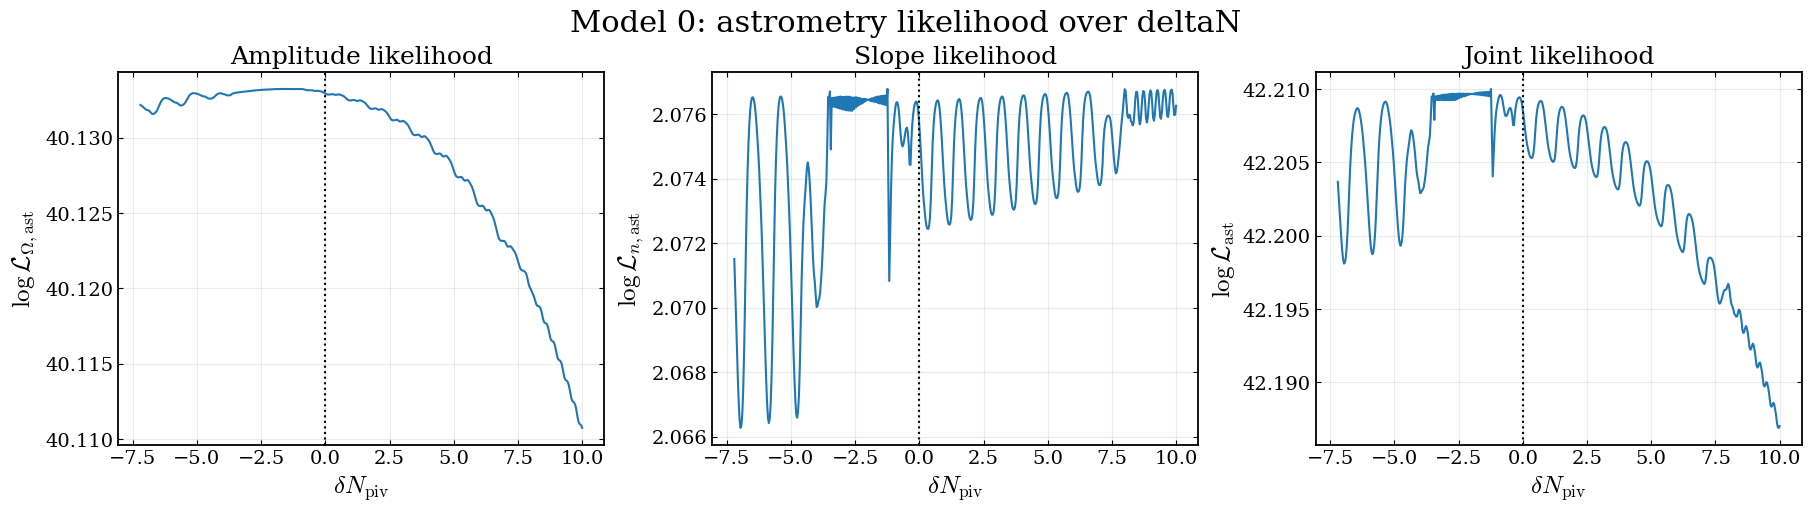

In [51]:
## Three panel breakdown!! Amp only, slope only, and joint eachas a function in deltaN in log space


model_index = 0

ast_df = ast_likelihood_curves[model_index]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5),
    constrained_layout=True,
)

ax_omega, ax_n, ax_joint = axes

ax_omega.plot(
    ast_df["deltaN"],
    ast_df["logL_Omega_ast"],
)

ax_omega.set_xlabel(
    r"$\delta N_{\rm piv}$"
)

ax_omega.set_ylabel(
    r"$\log\mathcal{L}_{\Omega,\rm ast}$"
)

ax_omega.set_title(
    "Amplitude likelihood"
)

ax_n.plot(
    ast_df["deltaN"],
    ast_df["logL_n_ast"],
)

ax_n.set_xlabel(
    r"$\delta N_{\rm piv}$"
)

ax_n.set_ylabel(
    r"$\log\mathcal{L}_{n,\rm ast}$"
)

ax_n.set_title(
    "Slope likelihood"
)

ax_joint.plot(
    ast_df["deltaN"],
    ast_df["logL_ast"],
)

ax_joint.set_xlabel(
    r"$\delta N_{\rm piv}$"
)

ax_joint.set_ylabel(
    r"$\log\mathcal{L}_{\rm ast}$"
)

ax_joint.set_title(
    "Joint likelihood"
)

for ax in axes:
    ax.axvline(
        0.0,
        color="black",
        linestyle=":",
    )

    ax.grid(
        True,
        alpha=0.25,
    )

fig.suptitle(
    f"Model {model_index}: astrometry likelihood over deltaN"
)

plt.show()

Okay above are the RAW log likelihoods. No normalization, so subtraction of max, nothing relative here. Below is the relative likelihoods, each normalized so its peak equals 1.


Relative likelihoods:

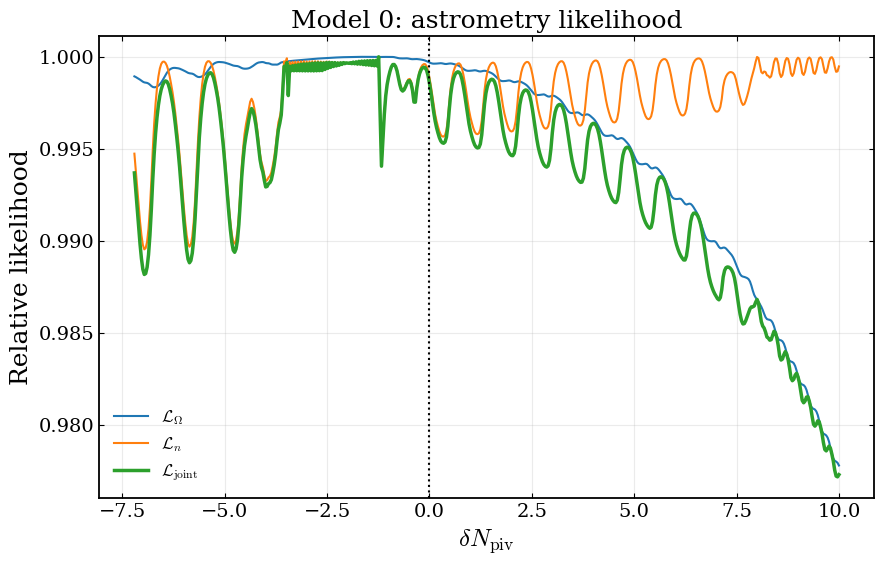

In [52]:
model_index = 0

ast_df = ast_likelihood_curves[
    model_index
].copy()

ast_df["relative_L_Omega_ast"] = np.exp(
    ast_df["logL_Omega_ast"]
    - ast_df["logL_Omega_ast"].max()
)

ast_df["relative_L_n_ast"] = np.exp(
    ast_df["logL_n_ast"]
    - ast_df["logL_n_ast"].max()
)

ast_df["relative_L_ast"] = np.exp(
    ast_df["logL_ast"]
    - ast_df["logL_ast"].max()
)

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    ast_df["deltaN"],
    ast_df["relative_L_Omega_ast"],
    label=r"$\mathcal{L}_{\Omega}$",
)

plt.plot(
    ast_df["deltaN"],
    ast_df["relative_L_n_ast"],
    label=r"$\mathcal{L}_{n}$",
)

plt.plot(
    ast_df["deltaN"],
    ast_df["relative_L_ast"],
    linewidth=2.5,
    label=r"$\mathcal{L}_{\rm joint}$",
)

plt.axvline(
    0.0,
    color="black",
    linestyle=":",
)

plt.xlabel(
    r"$\delta N_{\rm piv}$"
)

plt.ylabel(
    "Relative likelihood"
)

plt.title(
    f"Model {model_index}: astrometry likelihood"
)

plt.grid(
    True,
    alpha=0.25,
)

plt.legend(
    frameon=False,
)

plt.show()

If I want the total likelihood on both scales, for a given model it is the same $\delta N$ that controls both scales. 


I have already run likelihoods for interferometer and astrometry scales. Below, I am merging rows from int_df and ast_df ONLY where model_index and deltaN match exactly. It is in log space so, multiplying is adding. One thing is to make sure that the $\delta N$ range matches at both scales, it should because it is for that particular model that we found CMB compatible values.

This seems like the rigth way to do the joint, given that $\delta N$ is a single nuisance parameter across both scales.

In [53]:
def combine_int_and_ast_likelihoods(
    int_df,
    ast_df,
):
    """
    Combine interferometer and astrometry likelihoods
    at the same deltaN values.
    """

    combined = int_df[
        [
            "model_index",
            "deltaN",
            "logL_Omega_int",
            "logL_n_int",
            "logL_int",
        ]
    ].merge(
        ast_df[
            [
                "model_index",
                "deltaN",
                "logL_Omega_ast",
                "logL_n_ast",
                "logL_ast",
            ]
        ],
        on=[
            "model_index",
            "deltaN",
        ],
        how="inner",
    )

    combined["logL_total"] = (
        combined["logL_int"]
        + combined["logL_ast"]
    )
    
    print(len(int_df), len(ast_df), len(combined_df))
    

    return combined

In [54]:
model_index = 0

#curcvees defined on same deltaN grid, merges them row by row 
#For each shared deltaN adds hem to get logL total
combined_df = combine_int_and_ast_likelihoods(
    int_likelihood_curves[model_index],
    ast_likelihood_curves[model_index],
)

#Then we do the integration which takes that logL total and collapses it to a single scalar. Its same marg function
#But now its being handed combined curve.They have the same nuisance parametere not two different ones, so
#marginalization should happen over their shared nuisance parameter

#Combine first, marginalize over same deltaN

#In regard to the collapsing to a scalar, i am keeping ln total marge for model 0
#We lose where along deltaN the likelihood peaked
#The full curve told us how good the best fit was amd at what pivot shift. Once we integrate that position info is gone.
#So, two models that peak at diff deltaN could integrate to same marginal value but what we are choosing to keep here is
#how well does this model explain the fiducial model/measured data. us averaging over deltaN and where that peak is, is lost
#we also lose the width of the likelihood and the possibility of multiple peaks
#For us deltaN is an acknowledgement of uncertainty in N to k mapping  caused by truncation, not a value we arew trying to report
#we want to reflect uncertainty by averaging over a plausible range.
L_total_marg, logL_total_marg = (
    marginalize_likelihood_over_deltaN(
        combined_df,
        "logL_total",
    )
)

print("L_total_marg =", L_total_marg)
print("logL_total_marg =", logL_total_marg)

NameError: name 'combined_df' is not defined

84 and subtract fiducial i think, then you get how they differ and for some it aint by much.

For all:

In [118]:
total_likelihood_curves = {}
total_summary_records = []

for model_index in deltaN_ranges_df[
    "model_index"
].astype(int):

    combined_df = combine_int_and_ast_likelihoods(
        int_likelihood_curves[model_index],
        ast_likelihood_curves[model_index],
    )

    total_likelihood_curves[
        model_index
    ] = combined_df

    L_total_marg, logL_total_marg = (
        marginalize_likelihood_over_deltaN(
            combined_df,
            "logL_total",
        )
    )

    total_summary_records.append({
        "model_index": model_index,
        "L_total_marg": L_total_marg,
        "logL_total_marg": logL_total_marg,
    })

total_likelihood_summary = pd.DataFrame(
    total_summary_records
)

print(total_likelihood_summary)

     model_index  L_total_marg  logL_total_marg
0              0  4.547368e+36        84.407612
1              1  1.341490e+26        60.160993
2              2  1.543640e+29        67.209111
3              3  7.087627e+35        82.548829
4              4  2.232355e+31        72.183195
..           ...           ...              ...
198          198  9.103601e+35        82.799148
199          199  3.122425e+30        70.216163
200          200  7.387767e+34        80.287719
201          201  4.451455e+36        84.386294
202          202  8.928178e+34        80.477105

[203 rows x 3 columns]


In [129]:
full_summary = likelihood_summary.merge(
    total_likelihood_summary,
    on="model_index",
    how="inner",
)

total_likelihood_summary.sort_values("logL_total_marg", ascending=False).head(10)

,model_index,L_total_marg,logL_total_marg
144,144,4.559896e+36,84.410363
0,0,4.547368e+36,84.407612
179,179,4.511256e+36,84.399639
33,33,4.497626e+36,84.396613
83,83,4.455447e+36,84.387191
201,201,4.451455e+36,84.386294
99,99,4.445859e+36,84.385036
53,53,4.438260e+36,84.383326
18,18,4.428611e+36,84.381149
185,185,4.422844e+36,84.379846


Recall the entire premise of the $\delta N$ marginalization: models with different underlying slow-roll parameters can produce spectra that, once you allow for uncertainty in where the CMB pivot maps onto the trajectory, become observationally near-degenerate with the fiducial model. That's precisely the phenomenon we wanted to characterize in this project — quantifying how much truncation-order uncertainty blurs our ability to distinguish models. So finding a tight cluster of models all scoring within a hair of the true fiducial isn't a bug; it's the substantive physics result your framework was built to reveal. If model 0 had scored dramatically higher than everything else with a big gap, that would actually be more surprising.

If I want relative likelihoods:

The cell below is going to build a model x $\delta N$ heatmap. So that we have a 2D grip showung gow every CMB passing model's log likelihood varies across a shared $\delta N$ range, it will all be referenced to a common global peak.

In [135]:
# ============================================================
# Total likelihood map for all CMB-passing models
# ============================================================

model_indices = sorted(
    total_likelihood_curves.keys() #all likelihood curves
)

# Common deltaN grid covering all models
#technically we call this a generator expression, it is self contained
#we use it to extract single numbers
deltaN_global_min = min(
    df["deltaN"].min()
    for df in total_likelihood_curves.values()
)

deltaN_global_max = max(
    df["deltaN"].max()
    for df in total_likelihood_curves.values()
)

#need grid of all deltaN spans full range
common_deltaN = np.linspace(
    deltaN_global_min,
    deltaN_global_max,
    1000,
)

# Find the global best likelihood across every model and deltaN
global_logL_max = max(
    df["logL_total"].max()
    for df in total_likelihood_curves.values()
)

# Rows = models, columns = common deltaN values
#Builds 2D matrix, fill nan at first for preallocation
delta_logL_matrix = np.full(
    (
        len(model_indices),
        len(common_deltaN),
    ),
    np.nan,
)

for row_number, model_index in enumerate(
    model_indices
):
#this is a fresh df, only looking up specific models df
    df = total_likelihood_curves[
        model_index
    ].copy()

    deltaN_model = df[
        "deltaN"
    ].to_numpy()

    logL_model = df[
        "logL_total"
    ].to_numpy()

    # Only evaluate inside this model's CMB-allowed interval
    inside = (
        (common_deltaN >= deltaN_model.min())
        & (common_deltaN <= deltaN_model.max())
    )

    logL_interp = PchipInterpolator(
        deltaN_model,
        logL_model,
        extrapolate=False,
    )

    
    #so this is the log L on the common grid minus the largest L from the entire model set
    delta_logL_matrix[
        row_number,
        inside,
    ] = (
        logL_interp(
            common_deltaN[inside]
        )
        - global_logL_max
    )

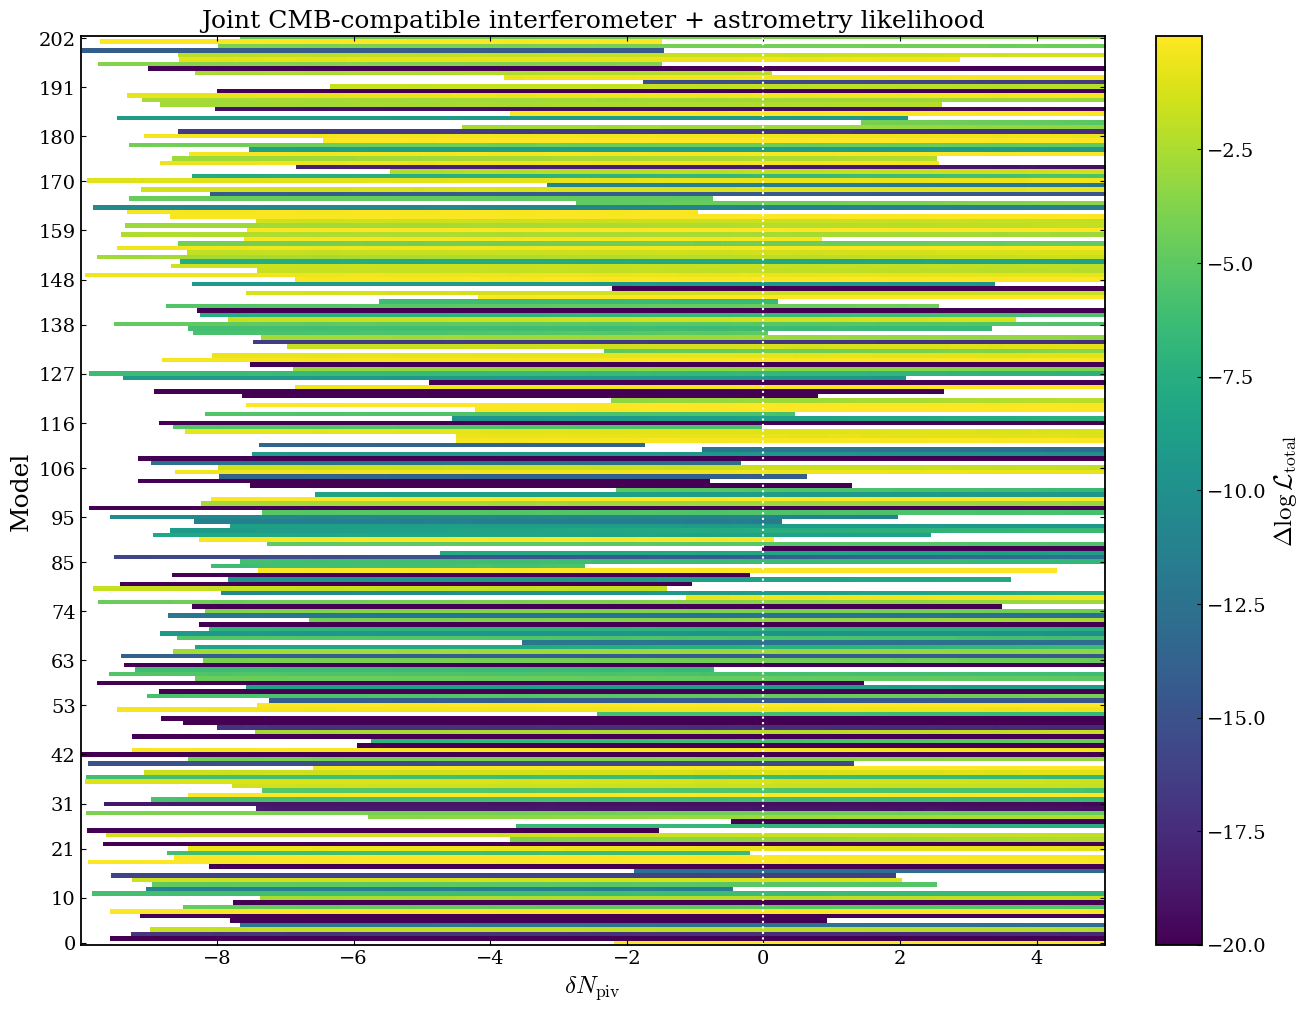

In [120]:
fig, ax = plt.subplots(
    figsize=(13, 10),
    constrained_layout=True,
)

# Clip the displayed range so very poor models do not
# dominate the color scale
#this does show only everything of ln L between 0 and -20
display_matrix = np.clip(
    delta_logL_matrix,
    -20.0,
    0.0,
)

image = ax.imshow(
    display_matrix,
    aspect="auto",
    origin="lower", #row0 appear at bottom
    extent=[ #extent labels pixel grid with real deltaN on x axis
        common_deltaN.min(),
        common_deltaN.max(),
        -0.5,
        len(model_indices) - 0.5, #for y range -0.5 to len of model in -0.5, to center on integer row 
    ],
    interpolation="nearest", #define nearest neighbor, so each row is undistorted
)

#keep in mind, imshow render Nan cells as transparent. delta_logL_matrix was preallocated with nans
#and only filled inside each models own valid deltaN range, so blank/empty regions where an interval doesnt 
#reach are transparent

ax.axvline(
    0.0,
    color="white",
    linestyle=":",
    linewidth=1.5,
)

ax.set_xlabel(
    r"$\delta N_{\rm piv}$"
)

ax.set_ylabel(
    "Model"
)

ax.set_title(
    r"Joint CMB-compatible interferometer + astrometry likelihood"
)

# Show actual model indices on the y-axis
#I have lots of models, labeling every row would be unreadable. Thos will pick at most 20 evenly spaced row pisitions
#and labels each tick with model index value at that row, not row position itself. 
number_ticks = min(
    20,
    len(model_indices),
)

tick_rows = np.linspace(
    0,
    len(model_indices) - 1,
    number_ticks,
    dtype=int,
)

ax.set_yticks(
    tick_rows
)

ax.set_yticklabels(
    [
        model_indices[i]
        for i in tick_rows
    ]
)

colorbar = fig.colorbar(
    image,
    ax=ax,
)

colorbar.set_label(
    r"$\Delta\log\mathcal{L}_{\rm total}$"
)

plt.show()



#correct NaN/masking behavior carried through from the matrix-building step, 
#sensible color-scale clipping to keep the visually interesting region readable, 
#and correct tick-label remapping so the y-axis reports true model identities rather than row positions.

An easier way to interpret this mess of best likelihood models is with the following code. Its goal is to identify for each of the top models, not just the marginal score but the single best-fit $\delta_N$ within that model's curve.
    
    

In [136]:
# ============================================================
# Select best-fitting models
# ============================================================

#Identify how many of the top models i wanna keep
N_BEST = 70

#So it goes through the full summaryb table by marginalized joint log-likelihood (best first-descending order)
best_models = (
    total_likelihood_summary
    .sort_values(
        "logL_total_marg",
        ascending=False,
    )
    .head(N_BEST)
    .copy()
)

#compute now the max of the  ln L_marg,tot
#this is best_logL pulled from full total_likelihood summary
#so like max of the summary i have
best_logL = total_likelihood_summary[
    "logL_total_marg"
].max()

#And from best models, grab the relative L by subtracing bestLog L from the highest L max
best_models["relative_L_total"] = np.exp(
    best_models["logL_total_marg"]
    - best_logL
)

#this means the single best model in best_models will have relative_L_total =1, 
#and everything else will be expressed as a fraction of that peak

# Best-fitting deltaN for each model
#for each of the selected models, it finds that model's full logL_total (deltaN) curve
#this was build earlier where it is one row per scanned deltaN
#so it grabs the row where logL_total is maximized using idxmax
best_deltaN = {}

#this is supposed to find the maximum likelihood point estimate of deltaN for that model
#picking one single deltaN, this is the best one
#note that logL_total_marg is the marginaled/integration likelohood over the ENTIRE allowed deltaN range
#I believe marginal value is stat correct for comparing/ranking models, the best fit point may be decent for visualization
#where I am using some single representatibe deltaN to plot one shifted OmegaGW(k) curve per model
for model_index in best_models[
    "model_index"
].astype(int):

    likelihood_curve = total_likelihood_curves[
        model_index
    ]

    best_row = likelihood_curve.loc[
        likelihood_curve["logL_total"].idxmax() #returns index of max, gets discrete grid pt with highest logL_total among sample grid
    ]

    best_deltaN[model_index] = float(
        best_row["deltaN"]
    )

print(
    best_models[
        [
            "model_index",
            "logL_total_marg",
            "relative_L_total",
        ]
    ]
)

print("Best deltaN values:")
print(best_deltaN)

     model_index  logL_total_marg  relative_L_total
144          144        84.410363          1.000000
0              0        84.407612          0.997253
179          179        84.399639          0.989333
33            33        84.396613          0.986344
83            83        84.387191          0.977094
..           ...              ...               ...
187          187        81.967239          0.086889
158          158        81.916478          0.082588
121          121        81.853030          0.077511
175          175        81.818912          0.074911
188          188        81.642945          0.062824

[70 rows x 3 columns]
Best deltaN values:
{144: 2.658192026052105, 0: -0.18367726052104416, 179: -1.6133526573146284, 33: 2.654969745490982, 83: -1.6220503627254512, 201: -1.611741306613224, 99: 4.0810157314629265, 53: 4.103905891783567, 18: -4.470754256513027, 185: -3.0414517434869754, 119: 1.3690379398797603, 7: -5.898585340681365, 120: -7.309979943887778, 159: 4.2192281

Checking to see if their actually are hitting peak likelihood within interval or because a boundary cut off.

In [139]:
row = deltaN_ranges_df.loc[deltaN_ranges_df["model_index"] == 121].iloc[0]
print(row["deltaN_min"], row["deltaN_max"])

-2.2411689999999993 5.0


In [140]:
boundary_hits = []
for model_index, dN_best in best_deltaN.items():
    row = deltaN_ranges_df.loc[deltaN_ranges_df["model_index"] == model_index].iloc[0]
    dN_min, dN_max = row["deltaN_min"], row["deltaN_max"]
    if np.isclose(dN_best, dN_min, atol=1e-6) or np.isclose(dN_best, dN_max, atol=1e-6):
        boundary_hits.append(model_index)

print(f"{len(boundary_hits)} / {len(best_deltaN)} best-fit deltaN values sit at their interval boundary")
print(boundary_hits)

13 / 70 best-fit deltaN values sit at their interval boundary
[19, 105, 174, 149, 197, 113, 114, 36, 151, 194, 187, 121, 175]


In [141]:
boundary_detail = []
for model_index in boundary_hits:
    row = deltaN_ranges_df.loc[deltaN_ranges_df["model_index"] == model_index].iloc[0]
    dN_min, dN_max = row["deltaN_min"], row["deltaN_max"]
    dN_best = best_deltaN[model_index]
    side = "min" if np.isclose(dN_best, dN_min, atol=1e-6) else "max"
    boundary_detail.append({"model_index": model_index, "side": side, "deltaN_best": dN_best})

pd.DataFrame(boundary_detail)

,model_index,side,deltaN_best
0,19,min,-8.647293
1,105,min,-8.624772
2,174,max,2.565090
3,149,min,-9.953039
4,197,max,2.878237
5,113,min,-4.504122
6,114,min,-8.492762
7,36,min,-9.941878
8,151,min,-8.692277
9,194,max,0.118381


In [142]:
best_models.loc[best_models["model_index"].isin(boundary_hits)]

,model_index,L_total_marg,logL_total_marg,relative_L_total
19,19,4.159568e+36,84.318474,0.912207
105,105,2.988520e+36,83.987842,0.655392
174,174,2.954130e+36,83.976268,0.647850
149,149,2.749700e+36,83.904555,0.603018
197,197,2.492320e+36,83.806277,0.546574
113,113,2.206235e+36,83.684351,0.483834
114,114,2.004006e+36,83.588212,0.439485
36,36,1.432542e+36,83.252514,0.314161
151,151,9.323218e+35,82.822986,0.204461
194,194,4.557275e+35,82.107203,0.099943


In [143]:
# Run it on slope at boundary

for model_index in boundary_hits:
    df = total_likelihood_curves[model_index]
    df_sorted = df.sort_values("deltaN")
    # last few points near whichever boundary was hit
    last5 = df_sorted.tail(5) if df["deltaN"].iloc[df["logL_total"].idxmax()] == df["deltaN"].max() else df_sorted.head(5)
    slope = np.gradient(last5["logL_total"].to_numpy(), last5["deltaN"].to_numpy())
    print(model_index, slope)

19 [-0.02697095 -0.02470825 -0.02126473 -0.02161716 -0.02315039]
105 [-0.04467107 -0.04207286 -0.03950015 -0.04257563 -0.04562561]
174 [0.21243943 0.20438319 0.18660401 0.16401076 0.15114047]
149 [-0.05218528 -0.05810203 -0.06983475 -0.08324132 -0.0908319 ]
197 [0.05668082 0.05271042 0.04201447 0.02862357 0.02195823]
113 [-0.05935558 -0.06472633 -0.07457425 -0.08148789 -0.08392435]
114 [-0.07317704 -0.07945227 -0.09151993 -0.10370399 -0.11009562]
36 [-0.06778286 -0.07323936 -0.08513569 -0.09782051 -0.10406548]
151 [-0.10704138 -0.10231226 -0.09043823 -0.0783102  -0.07332707]
194 [0.037978   0.03141965 0.02034016 0.00839866 0.00097829]
187 [0.3034941  0.29764485 0.28548263 0.27305589 0.2669421 ]
121 [0.21453605 0.219429   0.22568935 0.22442959 0.22180241]
175 [0.31753596 0.31357926 0.30851758 0.30547144 0.30353028]


From above it seems like 13/70 (19%) of our top-ranked models have best-fit $\deltaN$ pinned at the boundary of our tested interval, indicating the true best-fit likelihood may extend beyond our current N less than or equal to 60 sampling range. So at least 19% of the models have not reached their peak likelihood and its because the interval we are exploring is not capturing it fully.

Remember: 

H(N) and V(N) are without any shift applied, thopse are the raw background trajectories and show the model's diversity. deltaN_best is used to shift each model's own tensor spectrum before plotting $\Omega_{GW}(k)$, so two models with different best-fit $\deltaN$ can end up producing visually similar $\Omega_{GW}(k)$ near appropriate scales, even if raw unshifted trajectories and spectra might be different. That shift is doing some of the work to makre each model's curve pass near the measured points. This is the degenreacy we are interest in exploting, where models with different underlying slow-roll parameter can look like good fits to GW observables because $\delat N$ have enough freedom to reposition their spectra into agreement. $\Omega_{GW} is after each has been individually respositioned (by applying model-s own best fit correction).

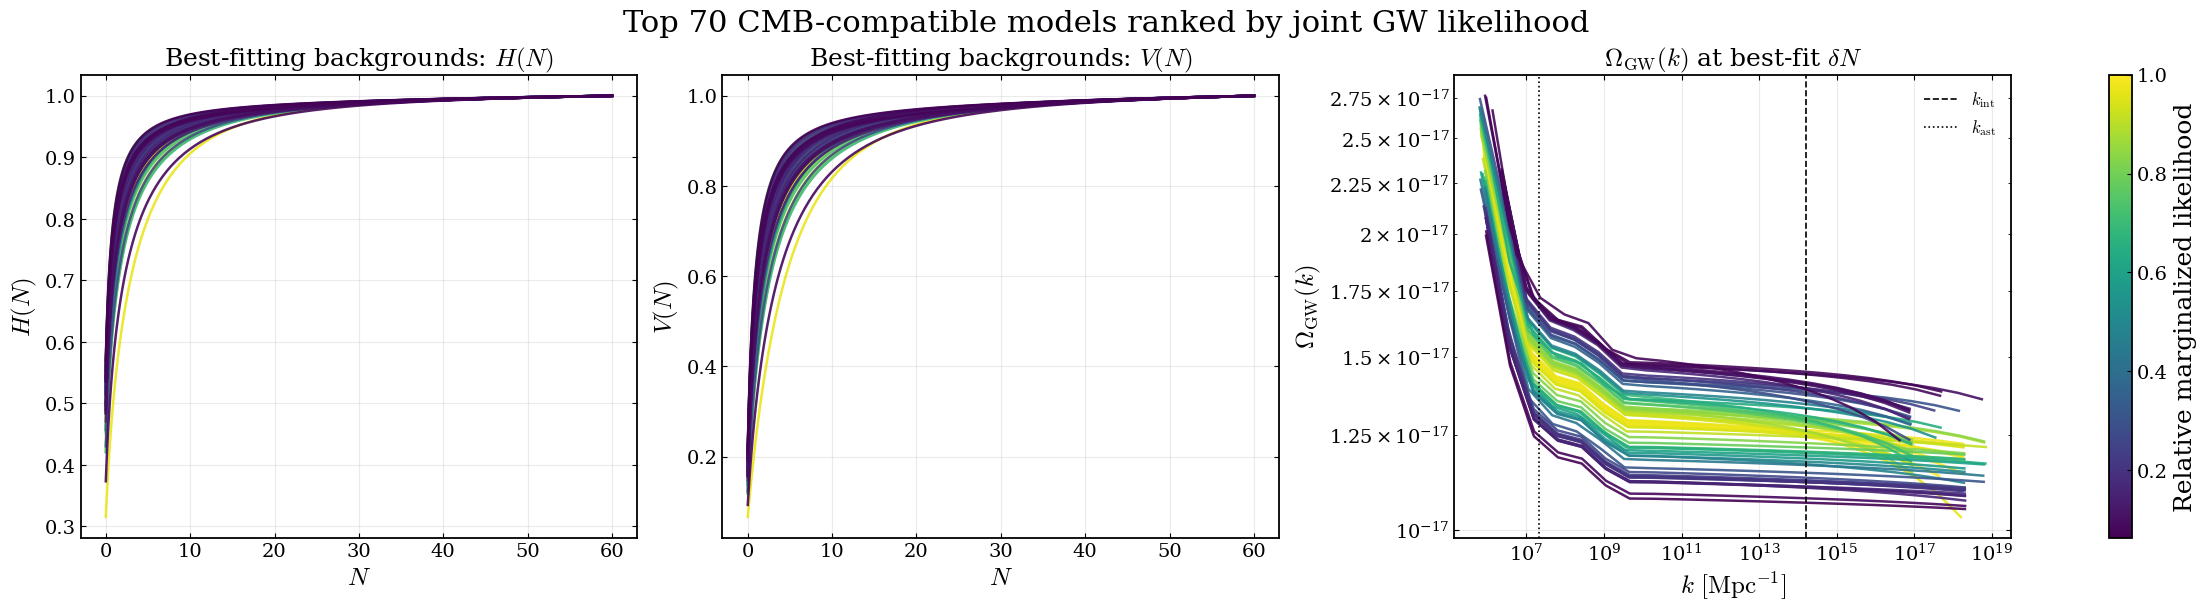

In [134]:
# ============================================================
# Plot best-fitting H(N), V(N), and OmegaGW(k)
# ============================================================

from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

fig, axes = plt.subplots(
    1,
    3,
    figsize=(22, 6),
    constrained_layout=True,
)

ax_H, ax_V, ax_omega = axes

norm = Normalize(
    vmin=best_models["relative_L_total"].min(),
    vmax=best_models["relative_L_total"].max(),
)

cmap = plt.cm.viridis

for _, summary_row in best_models.iterrows():

    model_index = int(
        summary_row["model_index"]
    )

    relative_L = float(
        summary_row["relative_L_total"]
    )

    deltaN_best = best_deltaN[
        model_index
    ]

    color = cmap(
        norm(relative_L)
    )

    model_row = deltaN_ranges_df.loc[
        deltaN_ranges_df["model_index"] == model_index
    ].iloc[0]

    outdir = model_row["outdir"]

    # --------------------------------------------------------
    # Load saved background trajectory
    # Change only this filename if your naming differs
    # --------------------------------------------------------
    trajectory_data, trajectory_file = load_path_from_outdir(
    outdir,
    NEQS=NEQS,)

    background = process_trajectory_maxN_both(
        trajectory_data,
        NEQS=NEQS,
    )

    N_background = background["N"]
    H_background = background["H_norm"]
    V_background = background["V_norm"]

    # --------------------------------------------------------
    # Plot H(N)
    # --------------------------------------------------------
    ax_H.plot(
        N_background,
        H_background,
        color=color,
        linewidth=1.8,
        alpha=0.9,
    )

    # --------------------------------------------------------
    # Plot V(N)
    # --------------------------------------------------------
    ax_V.plot(
        N_background,
        V_background,
        color=color,
        linewidth=1.8,
        alpha=0.9,
    )

    # --------------------------------------------------------
    # Load and shift tensor spectrum using best deltaN
    # --------------------------------------------------------
    tensor_file = os.path.join(
        outdir,
        f"spec_t_neqs{NEQS}.dat",
    )

    tensor_data = np.loadtxt(
        tensor_file
    )
    
    
    k_raw = np.asarray(tensor_data[:, 0], dtype=float)
    h=0.67
    k_raw = k_raw * h   # convert h/Mpc -> Mpc^-1, to match tf_k_invMpc's units

    Pt_raw = np.abs(np.asarray(tensor_data[:, 1], dtype=float))

    good_tensor = (
        np.isfinite(k_raw)
        & np.isfinite(Pt_raw)
        & (k_raw > 0)
        & (Pt_raw > 0)
    )

    k_raw = k_raw[good_tensor]
    Pt_raw = Pt_raw[good_tensor]

    k_raw, Pt_raw = ensure_increasing_k(
        k_raw,
        Pt_raw,
        name=f"Model {model_index} tensor spectrum",
    )
    


    k_shifted = (
        k_raw
        * np.exp(-deltaN_best)
    )

    
    tf_k = np.asarray(tf_k_invMpc, dtype=float)
    tf_T = np.asarray(tf_median, dtype=float)

    good_tf = (
        np.isfinite(tf_k)
        & np.isfinite(tf_T)
        & (tf_k > 0)
        & (tf_T > 0)
    )

    tf_k = tf_k[good_tf]
    tf_T = tf_T[good_tf]

    tf_k, tf_T = ensure_increasing_k(
        tf_k,
        tf_T,
        name="Transfer function",
    )
    
    
    T_shifted = np.exp(
        PchipInterpolator(
            np.log(tf_k),
            np.log(tf_T),
            extrapolate=False,
        )(
            np.log(k_shifted)
        )
    )

    OmegaGW = (
        T_shifted
        * Pt_raw
        / 0.67**2
    )

    valid = (
        np.isfinite(k_shifted)
        & np.isfinite(OmegaGW)
        & (k_shifted > 0)
        & (OmegaGW > 0)
    )

    ax_omega.loglog(
        k_shifted[valid],
        OmegaGW[valid],
        color=color,
        linewidth=1.8,
        alpha=0.9,
    )


# ============================================================
# Labels
# ============================================================

ax_H.set_xlabel(
    r"$N$"
)

ax_H.set_ylabel(
    r"$H(N)$"
)

ax_H.set_title(
    r"Best-fitting backgrounds: $H(N)$"
)

ax_V.set_xlabel(
    r"$N$"
)

ax_V.set_ylabel(
    r"$V(N)$"
)

ax_V.set_title(
    r"Best-fitting backgrounds: $V(N)$"
)

ax_omega.set_xlabel(
    r"$k\ [{\rm Mpc}^{-1}]$"
)

ax_omega.set_ylabel(
    r"$\Omega_{\rm GW}(k)$"
)

ax_omega.set_title(
    r"$\Omega_{\rm GW}(k)$ at best-fit $\delta N$"
)

ax_omega.axvline(
    k_int,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label=r"$k_{\rm int}$",
)

ax_omega.axvline(
    k_ast,
    color="black",
    linestyle=":",
    linewidth=1.2,
    label=r"$k_{\rm ast}$",
)

for ax in axes:
    ax.grid(
        True,
        alpha=0.25,
    )

ax_omega.legend(
    frameon=False,
)

# ------------------------------------------------------------
# Likelihood colorbar
# ------------------------------------------------------------
scalar_map = ScalarMappable(
    norm=norm,
    cmap=cmap,
)

scalar_map.set_array([])

colorbar = fig.colorbar(
    scalar_map,
    ax=axes,
)

colorbar.set_label(
    r"Relative marginalized likelihood"
)

fig.suptitle(
    f"Top {N_BEST} CMB-compatible models ranked by joint GW likelihood"
)

plt.show()

These are CMB-valid models that are most compatible with a hypothetical multi-scale GW detection having the fiducial model’s amplitudes and slopes and the assumed uncertainties.

For the plot of H(N), V(N), and OmegaGW(k), color-coding is by relative_L_total therefore shows:

which CMB-passing backgrounds are most compatible with both future datasets;
which inflationary histories produce similar multi-scale GW signatures;
which models survive the combined CMB + interferometer + astrometry forecast.

Right now I have high likelihood given a simulated detection.


# Detectable on Both Scales: Who Passes?
If I wanted to look at what is detectable on both scales:

Amp at least that of fiducial on both scales

In [93]:
# ============================================================
# Select models detectable at both scales
# ============================================================

SNR_DETECT = 5.0

detectability_records = []

for _, summary_row in best_models.iterrows():

    model_index = int(
        summary_row["model_index"]
    )

    deltaN_best = best_deltaN[
        model_index
    ]

    # Interferometer predictions for this model
    int_df = int_likelihood_curves[
        model_index
    ]

    # Astrometry predictions for this model
    ast_df = ast_likelihood_curves[
        model_index
    ]

    # Find the sampled point closest to best-fit deltaN
    int_row = int_df.iloc[
        np.argmin(
            np.abs(
                int_df["deltaN"].to_numpy()
                - deltaN_best
            )
        )
    ]

    ast_row = ast_df.iloc[
        np.argmin(
            np.abs(
                ast_df["deltaN"].to_numpy()
                - deltaN_best
            )
        )
    ]

    Omega_int_best = float(
        int_row["OmegaGW_int"]
    )

    Omega_ast_best = float(
        ast_row["OmegaGW_ast"]
    )

    SNR_int = (
        Omega_int_best
        / sigma_Omega_int
    )

    SNR_ast = (
        Omega_ast_best
        / sigma_Omega_ast
    )

    detectable_int = (
        SNR_int >= SNR_DETECT
    )

    detectable_ast = (
        SNR_ast >= SNR_DETECT
    )

    detectable_both = (
        detectable_int
        and detectable_ast
    )

    detectability_records.append({
        "model_index": model_index,
        "deltaN_best": deltaN_best,
        "OmegaGW_int_best": Omega_int_best,
        "OmegaGW_ast_best": Omega_ast_best,
        "SNR_int": SNR_int,
        "SNR_ast": SNR_ast,
        "detectable_int": detectable_int,
        "detectable_ast": detectable_ast,
        "detectable_both": detectable_both,
    })


detectability_summary = pd.DataFrame(
    detectability_records
)

detectable_both_models = best_models.merge(
    detectability_summary,
    on="model_index",
    how="left",
)

detectable_both_models = detectable_both_models.loc[
    detectable_both_models["detectable_both"]
].copy()

print(
    detectable_both_models[
        [
            "model_index",
            "relative_L_total",
            "deltaN_best",
            "SNR_int",
            "SNR_ast",
        ]
    ]
)

print(
    "Models detectable at both scales:",
    len(detectable_both_models),
)

     model_index  relative_L_total  deltaN_best    SNR_int    SNR_ast
0            144      1.000000e+00     1.656593  10.029889  10.007848
1              0      9.983490e-01     0.210980   9.991099   9.957595
2            179      9.933297e-01    -1.228222  10.025316   9.886851
3             33      9.903538e-01     3.047764  10.012536   9.915853
4             83      9.834221e-01    -2.658905  10.071927   9.820156
..           ...               ...          ...        ...        ...
181           71      1.737684e-10    -8.283065   5.379539   5.193267
182            5      1.013923e-10    -7.077256   5.307653   5.132614
183           97      4.033467e-11    -9.882046   5.224938   5.041221
184            1      3.077595e-11    -8.509684   5.195201   5.022783
185          190      2.861151e-11    -7.089388   5.184588   5.016953

[186 rows x 5 columns]
Models detectable at both scales: 186


HMMMM

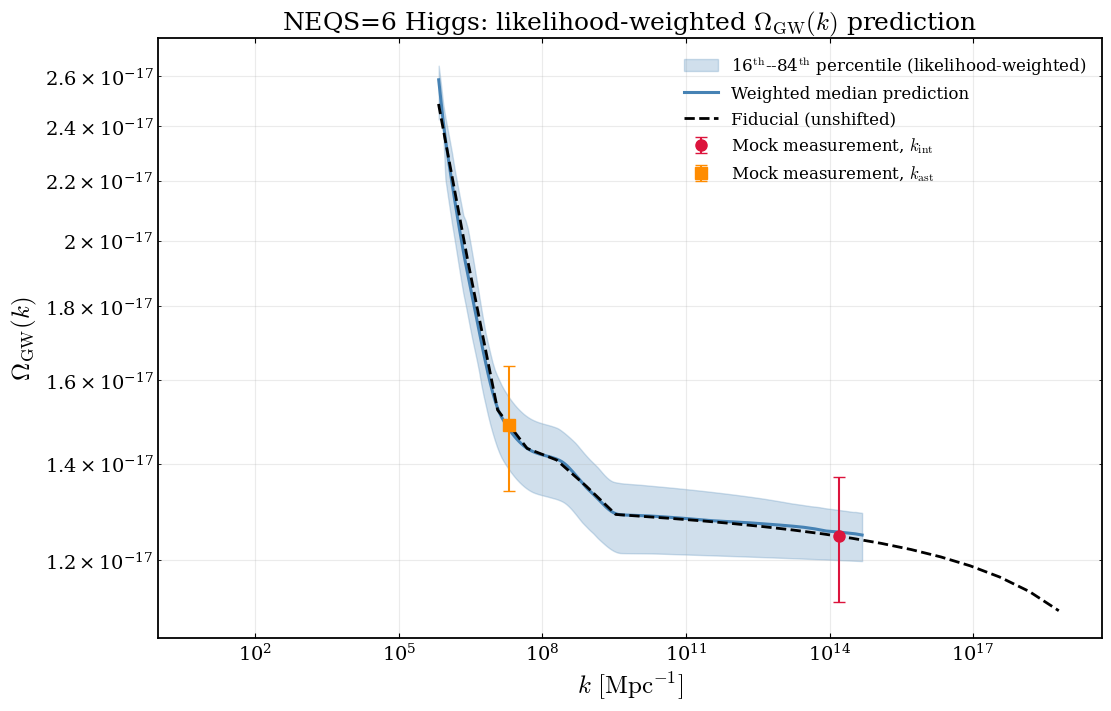

In [144]:
# ============================================================
# Prediction figure: Omega_GW(k) band for NEQS=6
#
# Builds a likelihood-weighted prediction for Omega_GW(k),
# using each CMB-passing model's own best-fit deltaN shift,
# weighted by its marginalized joint likelihood.
# ============================================================

# ------------------------------------------------------------
# Helper: shifted, transferred Omega_GW(k) curve for one model
# ------------------------------------------------------------
def compute_shifted_omega_curve(
    outdir,
    deltaN,
    tf_k,
    tf_T,
    NEQS=6,
    h=0.67,
):
    """
    Load one model's tensor spectrum, shift by deltaN, and
    apply the (already-filtered, already-sorted) transfer
    function. Returns (k_shifted, OmegaGW), both filtered to
    finite/positive values.

    tf_k, tf_T must already be filtered + sorted increasing
    (see load_transfer_function below).
    """

    tensor_file = os.path.join(outdir, f"spec_t_neqs{NEQS}.dat")
    tensor_data = np.loadtxt(tensor_file)

    k_raw = np.asarray(tensor_data[:, 0], dtype=float)
    k_raw = k_raw * h   # h/Mpc -> Mpc^-1

    Pt_raw = np.abs(np.asarray(tensor_data[:, 1], dtype=float))

    good = (
        np.isfinite(k_raw)
        & np.isfinite(Pt_raw)
        & (k_raw > 0)
        & (Pt_raw > 0)
    )
    k_raw = k_raw[good]
    Pt_raw = Pt_raw[good]

    k_raw, Pt_raw = ensure_increasing_k(
        k_raw, Pt_raw, name=f"tensor spectrum ({outdir})"
    )

    k_shifted = k_raw * np.exp(-deltaN)

    logT_interp = PchipInterpolator(
        np.log(tf_k), np.log(tf_T), extrapolate=False,
    )

    T_shifted = np.exp(logT_interp(np.log(k_shifted)))

    OmegaGW = T_shifted * Pt_raw / h**2

    valid = (
        np.isfinite(k_shifted)
        & np.isfinite(OmegaGW)
        & (k_shifted > 0)
        & (OmegaGW > 0)
    )

    return k_shifted[valid], OmegaGW[valid]


# ------------------------------------------------------------
# Helper: load + filter + sort the transfer function once
# ------------------------------------------------------------
def load_transfer_function(tf_k_invMpc, tf_median):
    tf_k_arr = np.asarray(tf_k_invMpc, dtype=float)
    tf_T_arr = np.asarray(tf_median, dtype=float)

    good_tf = (
        np.isfinite(tf_k_arr)
        & np.isfinite(tf_T_arr)
        & (tf_k_arr > 0)
        & (tf_T_arr > 0)
    )

    return ensure_increasing_k(
        tf_k_arr[good_tf], tf_T_arr[good_tf], name="Transfer function"
    )


# ------------------------------------------------------------
# Helper: weighted percentile (for the prediction band)
# ------------------------------------------------------------
def weighted_percentile(values, weights, percentile):
    """
    Weighted percentile ignoring NaNs, weights need not sum to 1.
    percentile in [0, 100].
    """
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)

    valid = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    if not np.any(valid):
        return np.nan

    values = values[valid]
    weights = weights[valid]

    order = np.argsort(values)
    values = values[order]
    weights = weights[order]

    cum_weights = np.cumsum(weights) - 0.5 * weights
    cum_weights /= np.sum(weights)

    return np.interp(percentile / 100.0, cum_weights, values)


# ============================================================
# Build the prediction band
# ============================================================
NEQS_PRED = 6
h_pred = 0.67

tf_k, tf_T = load_transfer_function(tf_k_invMpc, tf_median)

# Shared k-grid spanning CMB scales down to just past k_int
k_grid_min = 1e-4    # Mpc^-1, roughly CMB scales
k_grid_max = k_int * 3.0
k_grid = np.logspace(np.log10(k_grid_min), np.log10(k_grid_max), 400)

# Use every CMB-passing model with a finite marginalized likelihood
pred_models = total_likelihood_summary.dropna(
    subset=["logL_total_marg"]
).copy()

best_logL_pred = pred_models["logL_total_marg"].max()
pred_models["relative_L_total"] = np.exp(
    pred_models["logL_total_marg"] - best_logL_pred
)

# Collect each model's Omega_GW(k), interpolated onto the shared grid,
# using its own best-fit deltaN (from `best_deltaN`, extend if needed)
omega_matrix = np.full(
    (len(pred_models), len(k_grid)), np.nan
)
weights = np.zeros(len(pred_models))

for row_number, (_, summary_row) in enumerate(pred_models.iterrows()):

    model_index = int(summary_row["model_index"])

    if model_index not in best_deltaN:
        continue  # only models we've computed a best-fit deltaN for

    deltaN_use = best_deltaN[model_index]

    model_row = deltaN_ranges_df.loc[
        deltaN_ranges_df["model_index"] == model_index
    ].iloc[0]
    outdir = model_row["outdir"]

    try:
        k_shifted, OmegaGW = compute_shifted_omega_curve(
            outdir, deltaN_use, tf_k, tf_T, NEQS=NEQS_PRED, h=h_pred,
        )
    except (FileNotFoundError, ValueError):
        continue

    k_shifted, OmegaGW = ensure_increasing_k(
        k_shifted, OmegaGW, name=f"model {model_index} shifted spectrum"
    )

    log_omega_interp = PchipInterpolator(
        np.log(k_shifted), np.log(OmegaGW), extrapolate=False,
    )

    omega_matrix[row_number, :] = np.exp(
        log_omega_interp(np.log(k_grid))
    )
    weights[row_number] = float(summary_row["relative_L_total"])

# ------------------------------------------------------------
# Weighted band: 16th/50th/84th percentile at every k
# ------------------------------------------------------------
band_lo = np.full(len(k_grid), np.nan)
band_mid = np.full(len(k_grid), np.nan)
band_hi = np.full(len(k_grid), np.nan)

for col in range(len(k_grid)):
    column = omega_matrix[:, col]
    band_lo[col] = weighted_percentile(column, weights, 16)
    band_mid[col] = weighted_percentile(column, weights, 50)
    band_hi[col] = weighted_percentile(column, weights, 84)

# ------------------------------------------------------------
# Fiducial curve, unshifted
# ------------------------------------------------------------
fiducial_k, fiducial_omega = compute_shifted_omega_curve(
    fiducial_data["outdir"], 0.0, tf_k, tf_T, NEQS=NEQS_PRED, h=h_pred,
)
fiducial_k, fiducial_omega = ensure_increasing_k(
    fiducial_k, fiducial_omega, name="fiducial shifted spectrum"
)

# ============================================================
# Plot
# ============================================================
fig, ax = plt.subplots(figsize=(11, 7), constrained_layout=True)

ax.fill_between(
    k_grid, band_lo, band_hi,
    color="steelblue", alpha=0.25,
    label=r"16$^{\rm th}$--84$^{\rm th}$ percentile (likelihood-weighted)",
)

ax.loglog(
    k_grid, band_mid,
    color="steelblue", lw=2.2,
    label="Weighted median prediction",
)

ax.loglog(
    fiducial_k, fiducial_omega,
    color="black", lw=2.0, ls="--",
    label="Fiducial (unshifted)",
)

# Mock measurement points with 1-sigma error bars
ax.errorbar(
    [k_int], [Omega_meas_int], yerr=[sigma_Omega_int],
    fmt="o", color="crimson", markersize=8, capsize=4,
    label=r"Mock measurement, $k_{\rm int}$",
    zorder=5,
)
ax.errorbar(
    [k_ast], [Omega_meas_ast], yerr=[sigma_Omega_ast],
    fmt="s", color="darkorange", markersize=8, capsize=4,
    label=r"Mock measurement, $k_{\rm ast}$",
    zorder=5,
)

ax.set_xlabel(r"$k\ [{\rm Mpc}^{-1}]$")
ax.set_ylabel(r"$\Omega_{\rm GW}(k)$")
ax.set_title(
    rf"NEQS={NEQS_PRED} {MODEL_CONFIG['higgs']['label']}: "
    r"likelihood-weighted $\Omega_{\rm GW}(k)$ prediction"
)
ax.grid(True, which="both", alpha=0.25)
ax.legend(frameon=False, loc="best")

plt.show()